# Интерпретация

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OrdinalEncoder, LabelEncoder
from sklearn.inspection import partial_dependence, PartialDependenceDisplay, permutation_importance
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
import lime
import lime.lime_tabular
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline 

warnings.filterwarnings("ignore")
%config InlineBackend.figure_format = 'retina'

### Загрузка и подготовка данных


Вам будет предоставлен датасет, посвященный продаже недвижимости. Ваша задача - построить интерпретацию для этого датасета. В нем достаточно много различных признаков, поэтому вы можете предварительно отфильтровать их, когда будете строить графики. Оставляйте достаточно признаков, чтобы ваши модели оставались точными..

In [2]:
data_path = '/home/sonnet/projects/nikolskaya_ml_2026/data.csv'
data = pd.read_csv(data_path, sep=',')

print(f"Размер датасета: {data.shape}")
print(f"\nПервые строки:")
data.head()


Размер датасета: (29905, 83)

Первые строки:


,region_name_cat,district_cat,corpus_cat,developer_cat,agreement_date,floor,square,rooms_4,location_logs_count_mean,location_depth,...,location_public_transport_platform_w_mean_distance,location_water_w_mean_distance,location_university_w_mean_distance,location_leisure_w_mean_distance,location_pop_shop_cnt,price_target,hc_name_cat,interior_cat,class_cat,stage_cat
0,Город,45,538,18,2012-08-10,3.0,62.23,2,22.550466,13.0,...,0.910028,0.782675,-999.000000,0.820073,16.0,28417.424671,50,49786.0,27353,7983
1,Пригород,48,432,63,2013-05-19,11.0,22.52,студия,22.581858,13.0,...,0.902510,0.902673,-999.000000,0.990908,18.0,16728.215463,293,49786.0,97865,70661
2,Город,44,2372,126,2012-12-12,3.0,38.17,1,20.191250,13.0,...,0.851637,-999.000000,-999.000000,0.945618,7.0,18311.834458,284,49786.0,97865,70661
3,Город,14,1053,121,2012-12-10,10.0,57.48,2,23.286900,13.0,...,0.913797,1.028386,0.300026,0.828147,5.0,25171.489968,325,0.0,97865,12638
4,Город,63,2426,69,2012-02-12,3.0,41.43,1,20.599150,13.0,...,1.051049,-999.000000,-999.000000,0.991506,4.0,27324.795343,182,49786.0,97865,70661


## Задание 1. 1 балл
Сделайте 2 версии данных - с нормализацией признаков и без.
Обучите 6 моделей:
- линейную регрессию (LinearRegression) на двух вариантах данных
- Lasso регрессию (Lasso) на двух вариантах данных
- градиентный бустинг (GradientBoostingRegressor) на двух вариантах данных. Ограничьте глубину до 5.

Выведите MSE,RMSE и MAPE моделей. Какая функция больше подходит? Почему?

Зафиксируйте выводы. Какие модели чувствительны к масштабу признаков, а какие почти инвариантны? Почему это важно для анализа признаков?

## Задание 1.1(*) 1 балл
Сравните модели, построенные с помощью разных видов нормализации (MinMax, Standart). Отличается ли важность признаков?

In [3]:
data.describe()

,district_cat,corpus_cat,developer_cat,floor,square,location_logs_count_mean,location_depth,location_logs_count_std,location_flash_mean_mean,location_hds_ratio_mean_mean,...,location_public_transport_platform_w_mean_distance,location_water_w_mean_distance,location_university_w_mean_distance,location_leisure_w_mean_distance,location_pop_shop_cnt,price_target,hc_name_cat,interior_cat,class_cat,stage_cat
count,29905.000000,29905.000000,29905.000000,29905.000000,29905.000000,29572.000000,29572.0,29572.000000,29572.000000,29572.000000,...,29572.000000,29572.000000,29572.000000,29572.000000,29572.000000,29905.000000,29905.000000,29905.000000,29905.000000,29905.000000
mean,51.564621,1263.651129,73.761779,9.713125,57.470088,22.378914,13.0,25.017475,0.211902,1.295069,...,-7.875600,-307.290970,-689.842065,0.888430,8.830718,24606.729857,254.002675,19510.513158,77870.095469,43767.466845
std,23.717749,700.273954,29.491876,6.096880,25.523398,2.474799,0.0,12.711157,0.029187,0.073910,...,93.165568,461.766719,462.132973,0.099720,5.584762,10045.795459,109.070862,21911.397338,32650.894231,27287.683879
min,1.000000,3.000000,2.000000,-9.000000,18.660000,13.178136,13.0,6.480796,0.090068,0.835207,...,-999.000000,-999.000000,-999.000000,0.231314,0.000000,15859.265133,2.000000,0.000000,2581.000000,103.000000
25%,41.000000,737.000000,58.000000,5.000000,38.850000,21.521521,13.0,20.392994,0.194393,1.290643,...,0.832622,-999.000000,-999.000000,0.828147,4.000000,18019.041560,181.000000,0.000000,27353.000000,12638.000000
50%,48.000000,1188.000000,77.000000,9.000000,51.510000,22.574287,13.0,22.389158,0.212908,1.316139,...,0.881220,0.837294,-999.000000,0.895532,8.000000,22257.192093,270.000000,8977.000000,97865.000000,27728.000000
75%,71.000000,1881.000000,91.000000,13.000000,69.580000,23.743690,13.0,24.488793,0.230561,1.333026,...,0.921279,1.019665,0.746081,0.952028,12.000000,27639.644836,341.000000,49786.000000,97865.000000,70661.000000
max,100.000000,2428.000000,134.000000,211.000000,427.230000,33.396234,13.0,106.070634,0.307842,1.384783,...,1.165174,1.611869,1.559104,1.263878,25.000000,142207.315609,457.000000,49786.000000,97865.000000,70661.000000


In [4]:
data.info

<bound method DataFrame.info of       region_name_cat  district_cat  corpus_cat  developer_cat agreement_date  \
0               Город            45         538             18     2012-08-10   
1            Пригород            48         432             63     2013-05-19   
2               Город            44        2372            126     2012-12-12   
3               Город            14        1053            121     2012-12-10   
4               Город            63        2426             69     2012-02-12   
...               ...           ...         ...            ...            ...   
29900           Город            90         860             32     2013-01-19   
29901           Город            15         968             57     2012-05-20   
29902           Город            53        2382             97     2013-04-10   
29903        Пригород            48         750             41     2012-11-28   
29904           Город            78         680             91     2013-03-17

In [5]:
data['agreement_date'] = pd.to_datetime(data['agreement_date'])

print("Анализ категориальных признаков")

categorical_cols = ['region_name_cat', 'district_cat', 'corpus_cat', 'developer_cat', 
                    'hc_name_cat', 'interior_cat', 'class_cat', 'stage_cat']

for col in categorical_cols:
    print(f"\n{col}:")
    print(f"  уникальных: {data[col].nunique()}")

Анализ категориальных признаков

region_name_cat:
  уникальных: 3

district_cat:
  уникальных: 69

corpus_cat:
  уникальных: 464

developer_cat:
  уникальных: 73

hc_name_cat:
  уникальных: 153

interior_cat:
  уникальных: 7

class_cat:
  уникальных: 3

stage_cat:
  уникальных: 8


In [6]:
print("Анализ пропусков")

# Реальные NaN
real_nulls = data.isnull().sum()
real_nulls = real_nulls[real_nulls > 0]
if len(real_nulls) > 0:
    print(f"\nРеальные NaN: {len(real_nulls)} колонок, {real_nulls.sum()} записей")
    print(dict(real_nulls.head(3)))

# Анализ -999
cols_with_minus999 = [col for col in data.columns 
                      if data[col].dtype in ['float64', 'int64'] 
                      and (data[col] == -999).any()]

print(f"\nКолонок с -999: {len(cols_with_minus999)}")

minus999_stats = [(col, (data[col] == -999).sum() / len(data) * 100) 
                  for col in cols_with_minus999]
minus999_stats.sort(key=lambda x: x[1], reverse=True)

print("\nТоп-10 по доле -999:")
for col, pct in minus999_stats[:10]:
    print(f"  {col}: {pct:.1f}%")

print("\nДоля -999 <5%:")
for col, pct in minus999_stats[-5:]:
    if pct < 5:
        print(f"  {col}: {pct:.1f}%")

sample_cols = ['location_water_w_mean_distance', 'location_university_w_mean_distance']
for col in sample_cols:
    real = data[data[col] != -999][col]
    if len(real) > 0:
        print(f"\n{col}: {real.min():.2f}-{real.max():.2f}, mean={real.mean():.2f}")

Анализ пропусков

Реальные NaN: 70 колонок, 23310 записей
{'location_logs_count_mean': np.int64(333), 'location_depth': np.int64(333), 'location_logs_count_std': np.int64(333)}

Колонок с -999: 29

Топ-10 по доле -999:
  location_town_w_mean_distance: 70.9%
  location_university_w_mean_distance: 68.3%
  location_commercial_w_mean_distance: 65.3%
  location_amenity_leisure_w_mean_distance: 35.1%
  location_water_w_mean_distance: 30.5%
  location_hotel_w_mean_distance: 27.5%
  location_industrial_w_mean_distance: 18.2%
  location_railway_station_w_mean_distance: 16.3%
  location_social_w_mean_distance: 16.2%
  location_shop_alco_w_mean_distance: 12.3%

Доля -999 <5%:
  location_shop_product_w_mean_distance: 0.9%
  location_highway_crossing_w_mean_distance: 0.9%
  location_public_transport_platform_w_mean_distance: 0.9%
  location_std_levels_mean: 0.6%
  location_shop_other_w_mean_distance: 0.6%

location_water_w_mean_distance: 0.18-1.61, mean=0.96

location_university_w_mean_distance: 0.

Анализ даты
Период: 2012-01-01 - 2013-06-23
Дней: 539

Продажи: min=583 (2012-01), max=3139 (2012-12), mean=1661.4
Цена: min=23659 (2012-06), max=26179 (2012-01)


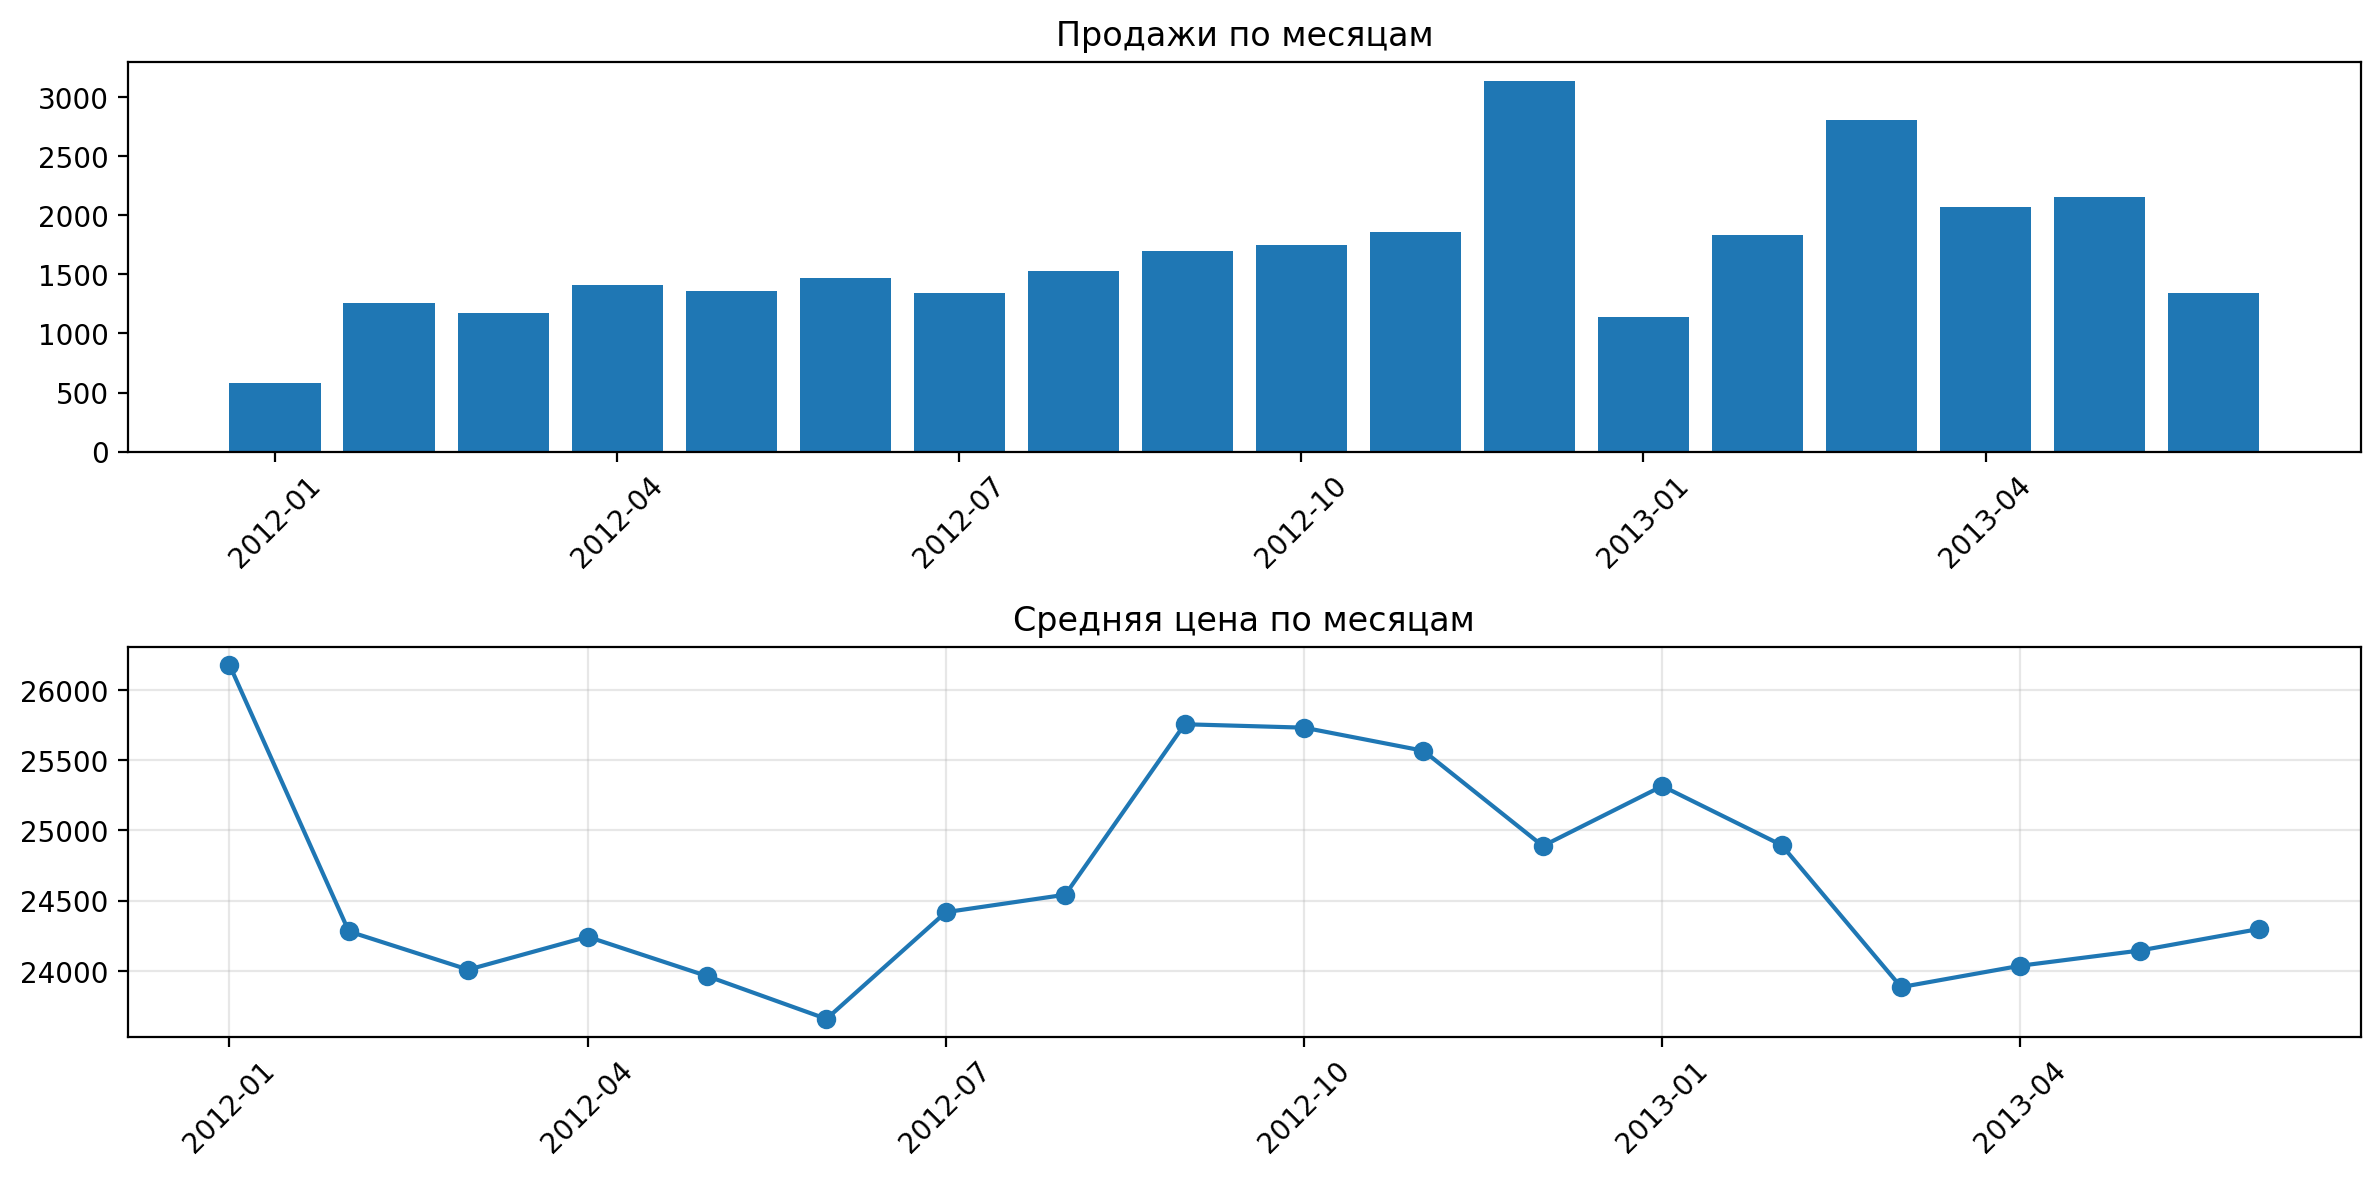

In [7]:
print("Анализ даты")

data_sorted = data.sort_values('agreement_date')

print(f"Период: {data['agreement_date'].min().date()} - {data['agreement_date'].max().date()}")
print(f"Дней: {(data['agreement_date'].max() - data['agreement_date'].min()).days}")

# Помесячная статистика
data['year_month'] = data['agreement_date'].dt.to_period('M')
monthly_counts = data['year_month'].value_counts().sort_index()
monthly_price = data.groupby('year_month')['price_target'].mean()

print(f"\nПродажи: min={monthly_counts.min()} ({monthly_counts.idxmin()}), max={monthly_counts.max()} ({monthly_counts.idxmax()}), mean={monthly_counts.mean():.1f}")
print(f"Цена: min={monthly_price.min():.0f} ({monthly_price.idxmin()}), max={monthly_price.max():.0f} ({monthly_price.idxmax()})")

fig, axes = plt.subplots(2, 1, figsize=(12, 6))

axes[0].bar(range(len(monthly_counts)), monthly_counts.values)
axes[0].set_title('Продажи по месяцам')
axes[0].set_xticks(range(0, len(monthly_counts), 3))
axes[0].set_xticklabels(monthly_counts.index[::3], rotation=45)

axes[1].plot(range(len(monthly_price)), monthly_price.values, marker='o')
axes[1].set_title('Средняя цена по месяцам')
axes[1].set_xticks(range(0, len(monthly_price), 3))
axes[1].set_xticklabels(monthly_price.index[::3], rotation=45)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
print("Анализ повторений")

# depth колонки
depth_cols = [col for col in data.columns if 'depth' in col.lower()]
print(f"depth колонки: {depth_cols}")
for col in depth_cols:
    print(f"  {col}: {data[col].nunique()} уникальных")

if len(depth_cols) >= 2:
    identical = (data[depth_cols[0]] == data[depth_cols[1]]).all()
    print(f"  {depth_cols[0]} == {depth_cols[1]}: {identical}")

# константы
constant_cols = [col for col in data.columns 
                 if data[col].dtype in ['float64', 'int64'] 
                 and data[col].nunique() == 1]
if constant_cols:
    print(f"\nконстанты: {constant_cols}")

# дубликаты строк
duplicates = data.duplicated().sum()
print(f"\nдубликатов строк: {duplicates} ({duplicates/len(data)*100:.2f}%)")

Анализ повторений
depth колонки: ['location_depth', 'location_depth.1', 'location_depth.2']
  location_depth: 1 уникальных
  location_depth.1: 1 уникальных
  location_depth.2: 1 уникальных
  location_depth == location_depth.1: False

константы: ['location_depth', 'location_depth.1', 'location_depth.2']

дубликатов строк: 2 (0.01%)


In [9]:
data['agreement_date'] = pd.to_datetime(data['agreement_date'])

# Очистка
data = data.drop_duplicates()
data = data[data['region_name_cat'] != 'Область']
geo_cols = [col for col in data.columns if 'location_' in col]
data = data.dropna(subset=geo_cols)
data = data.drop(columns=['location_depth', 'location_depth.1', 'location_depth.2'], errors='ignore')

cat_to_str = ['stage_cat', 'rooms_4', 'district_cat', 'corpus_cat', 
              'developer_cat', 'hc_name_cat', 'region_name_cat', 
              'interior_cat', 'class_cat']
for col in cat_to_str:
    data[col] = data[col].astype(str)

for col in data.columns:
    if 'w_mean_distance' in col:
        data[col] = data[col].replace(-999, 10.0)
    elif '_cnt' in col and 'w_mean' not in col:
        data[col] = data[col].replace(-999, 0)

# Временные признаки
data['month'] = data['agreement_date'].dt.month
data = data.drop(columns=['agreement_date'])

data_with_date = pd.read_csv('/home/sonnet/projects/nikolskaya_ml_2026/data.csv', sep=',')
data_with_date['agreement_date'] = pd.to_datetime(data_with_date['agreement_date'])
data_with_date = data_with_date.drop_duplicates()
data_with_date = data_with_date[data_with_date['region_name_cat'] != 'Область']
data_with_date = data_with_date.dropna(subset=geo_cols)
data_with_date = data_with_date.sort_values('agreement_date')

data = data.loc[data_with_date.index].reset_index(drop=True)

split_idx = int(len(data) * 0.8)
X, y = data.drop(columns=['price_target']), data['price_target']
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Предобработка
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()

preprocessor = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), num_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
        ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
    ]), cat_cols)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Train: {X_train_processed.shape}, Test: {X_test_processed.shape}")

Train: (23656, 79), Test: (5914, 79)


In [10]:
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    
    print(f"{model_name}:")
    print(f"  MSE: {mse:.2f}")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  MAPE: {mape:.4f}")
    print()
    
    return {'model': model, 'mse': mse, 'rmse': rmse, 'mape': mape, 'y_pred': y_pred}

In [11]:
print("Тест моделей без нормировки")

results = {}

# Линейная регрессия
results['LR'] = evaluate_model(
    LinearRegression(), X_train_processed, y_train, X_test_processed, y_test, 
    "Linear Regression"
)

# Lasso
results['Lasso'] = evaluate_model(
    Lasso(alpha=1.0, random_state=42), X_train_processed, y_train, X_test_processed, y_test,
    "Lasso Regression"
)

# Градиентный бустинг
results['GBR'] = evaluate_model(
    GradientBoostingRegressor(max_depth=5, random_state=42), 
    X_train_processed, y_train, X_test_processed, y_test,
    "Gradient Boosting"
)

Тест моделей без нормировки
Linear Regression:
  MSE: 24103447.12
  RMSE: 4909.53
  MAPE: 0.1344

Lasso Regression:
  MSE: 24322184.25
  RMSE: 4931.75
  MAPE: 0.1338

Gradient Boosting:
  MSE: 9466456.26
  RMSE: 3076.76
  MAPE: 0.0637



In [12]:
print("Тест моделей с StandartScaler")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_processed)
X_test_scaled = scaler.transform(X_test_processed)

# Линейная регрессия
results['LR_std'] = evaluate_model(
    LinearRegression(), X_train_scaled, y_train, X_test_scaled, y_test,
    "Linear Regression"
)

# Lasso
results['Lasso_std'] = evaluate_model(
    Lasso(alpha=1.0, random_state=42), X_train_scaled, y_train, X_test_scaled, y_test,
    "Lasso Regression"
)

# Градиентный бустинг
results['GBR_std'] = evaluate_model(
    GradientBoostingRegressor(max_depth=5, random_state=42),
    X_train_scaled, y_train, X_test_scaled, y_test,
    "Gradient Boosting"
)

Тест моделей с StandartScaler
Linear Regression:
  MSE: 24103447.12
  RMSE: 4909.53
  MAPE: 0.1344

Lasso Regression:
  MSE: 23599514.41
  RMSE: 4857.93
  MAPE: 0.1312

Gradient Boosting:
  MSE: 9464351.78
  RMSE: 3076.42
  MAPE: 0.0637



In [13]:
comparison = []
for name, res in results.items():
    comparison.append({
        'Model': name,
        'MSE': res['mse'],
        'RMSE': res['rmse'],
        'MAPE': res['mape']
    })

comparison_df = pd.DataFrame(comparison).sort_values('RMSE')

print("Сравнение всех моделей")
print(comparison_df.to_string(index=False))

# Анализ влияния нормализации
print("\nВлияние нормализации на модели")

for model_type in ['LR', 'Lasso', 'GBR']:
    rmse_orig = results[model_type]['rmse']
    rmse_scaled = results[f'{model_type}_std']['rmse']
    improvement = (rmse_orig - rmse_scaled) / rmse_orig * 100
    
    print(f"{model_type}:")
    print(f"  Без норм: {rmse_orig:.2f}, с норм: {rmse_scaled:.2f}")
    print(f"  Изменение: {improvement:+.1f}%")
    print()

Сравнение всех моделей
    Model          MSE        RMSE     MAPE
  GBR_std 9.464352e+06 3076.418662 0.063709
      GBR 9.466456e+06 3076.760677 0.063707
Lasso_std 2.359951e+07 4857.933142 0.131234
       LR 2.410345e+07 4909.526160 0.134397
   LR_std 2.410345e+07 4909.526160 0.134397
    Lasso 2.432218e+07 4931.752655 0.133770

Влияние нормализации на модели
LR:
  Без норм: 4909.53, с норм: 4909.53
  Изменение: -0.0%

Lasso:
  Без норм: 4931.75, с норм: 4857.93
  Изменение: +1.5%

GBR:
  Без норм: 3076.76, с норм: 3076.42
  Изменение: +0.0%



In [14]:
print("Тест моделей с MinMaxScaler")

minmax_scaler = MinMaxScaler()
X_train_minmax = minmax_scaler.fit_transform(X_train_processed)
X_test_minmax = minmax_scaler.transform(X_test_processed)

models_minmax = {
    'LR': LinearRegression(),
    'Lasso_': Lasso(alpha=1.0, random_state=42),
    'GBR': GradientBoostingRegressor(max_depth=5, random_state=42)
}

for name, model in models_minmax.items():
    res = evaluate_model(model, X_train_minmax, y_train, X_test_minmax, y_test, name)
    results[name] = res

Тест моделей с MinMaxScaler
LR:
  MSE: 24103447.12
  RMSE: 4909.53
  MAPE: 0.1344

Lasso_:
  MSE: 23313407.83
  RMSE: 4828.40
  MAPE: 0.1297

GBR:
  MSE: 9408149.73
  RMSE: 3067.27
  MAPE: 0.0635



In [15]:
coef_std = results['Lasso_std']['model'].coef_
coef_minmax = results['Lasso']['model'].coef_

feature_names = num_cols + cat_cols
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'StandardScaler': coef_std,
    'MinMaxScaler': coef_minmax
})

importance_df['abs_std'] = np.abs(importance_df['StandardScaler'])
importance_df['abs_minmax'] = np.abs(importance_df['MinMaxScaler'])
importance_df['rank_std'] = importance_df['abs_std'].rank(ascending=False)
importance_df['rank_minmax'] = importance_df['abs_minmax'].rank(ascending=False)
importance_df['rank_diff'] = importance_df['rank_std'] - importance_df['rank_minmax']

print("Топ важных признаков (StandardScaler)\n")
top_std = importance_df.nlargest(10, 'abs_std')[['Feature', 'StandardScaler', 'MinMaxScaler']]
print(top_std.to_string(index=False))

print("\nПризнаки с наибольшим изменением ранга важности\n")
top_rank_change = importance_df.nlargest(10, 'rank_diff')[['Feature', 'rank_std', 'rank_minmax', 'rank_diff']]
print(top_rank_change.to_string(index=False))

Топ важных признаков (StandardScaler)

                                           Feature  StandardScaler  MinMaxScaler
location_public_transport_platform_w_mean_distance    22548.569611  31756.830034
         location_highway_crossing_w_mean_distance   -18607.618595 -24647.817703
                            location_buildings_cnt     5248.595406     17.668191
                                         class_cat    -4799.788927  -9387.574719
       location_amenity_restaurant_w_mean_distance    -4512.312374  -2497.302943
            location_public_transport_platform_cnt    -4118.939523   -214.392526
                              location_leisure_cnt    -4050.541399    -62.174397
                                   region_name_cat    -3857.410031  -9015.530856
              location_highway_traffic_signals_cnt     3744.906489    223.054975
                      location_hds_ratio_mean_mean     3441.751987  44328.066178

Признаки с наибольшим изменением ранга важности

                    

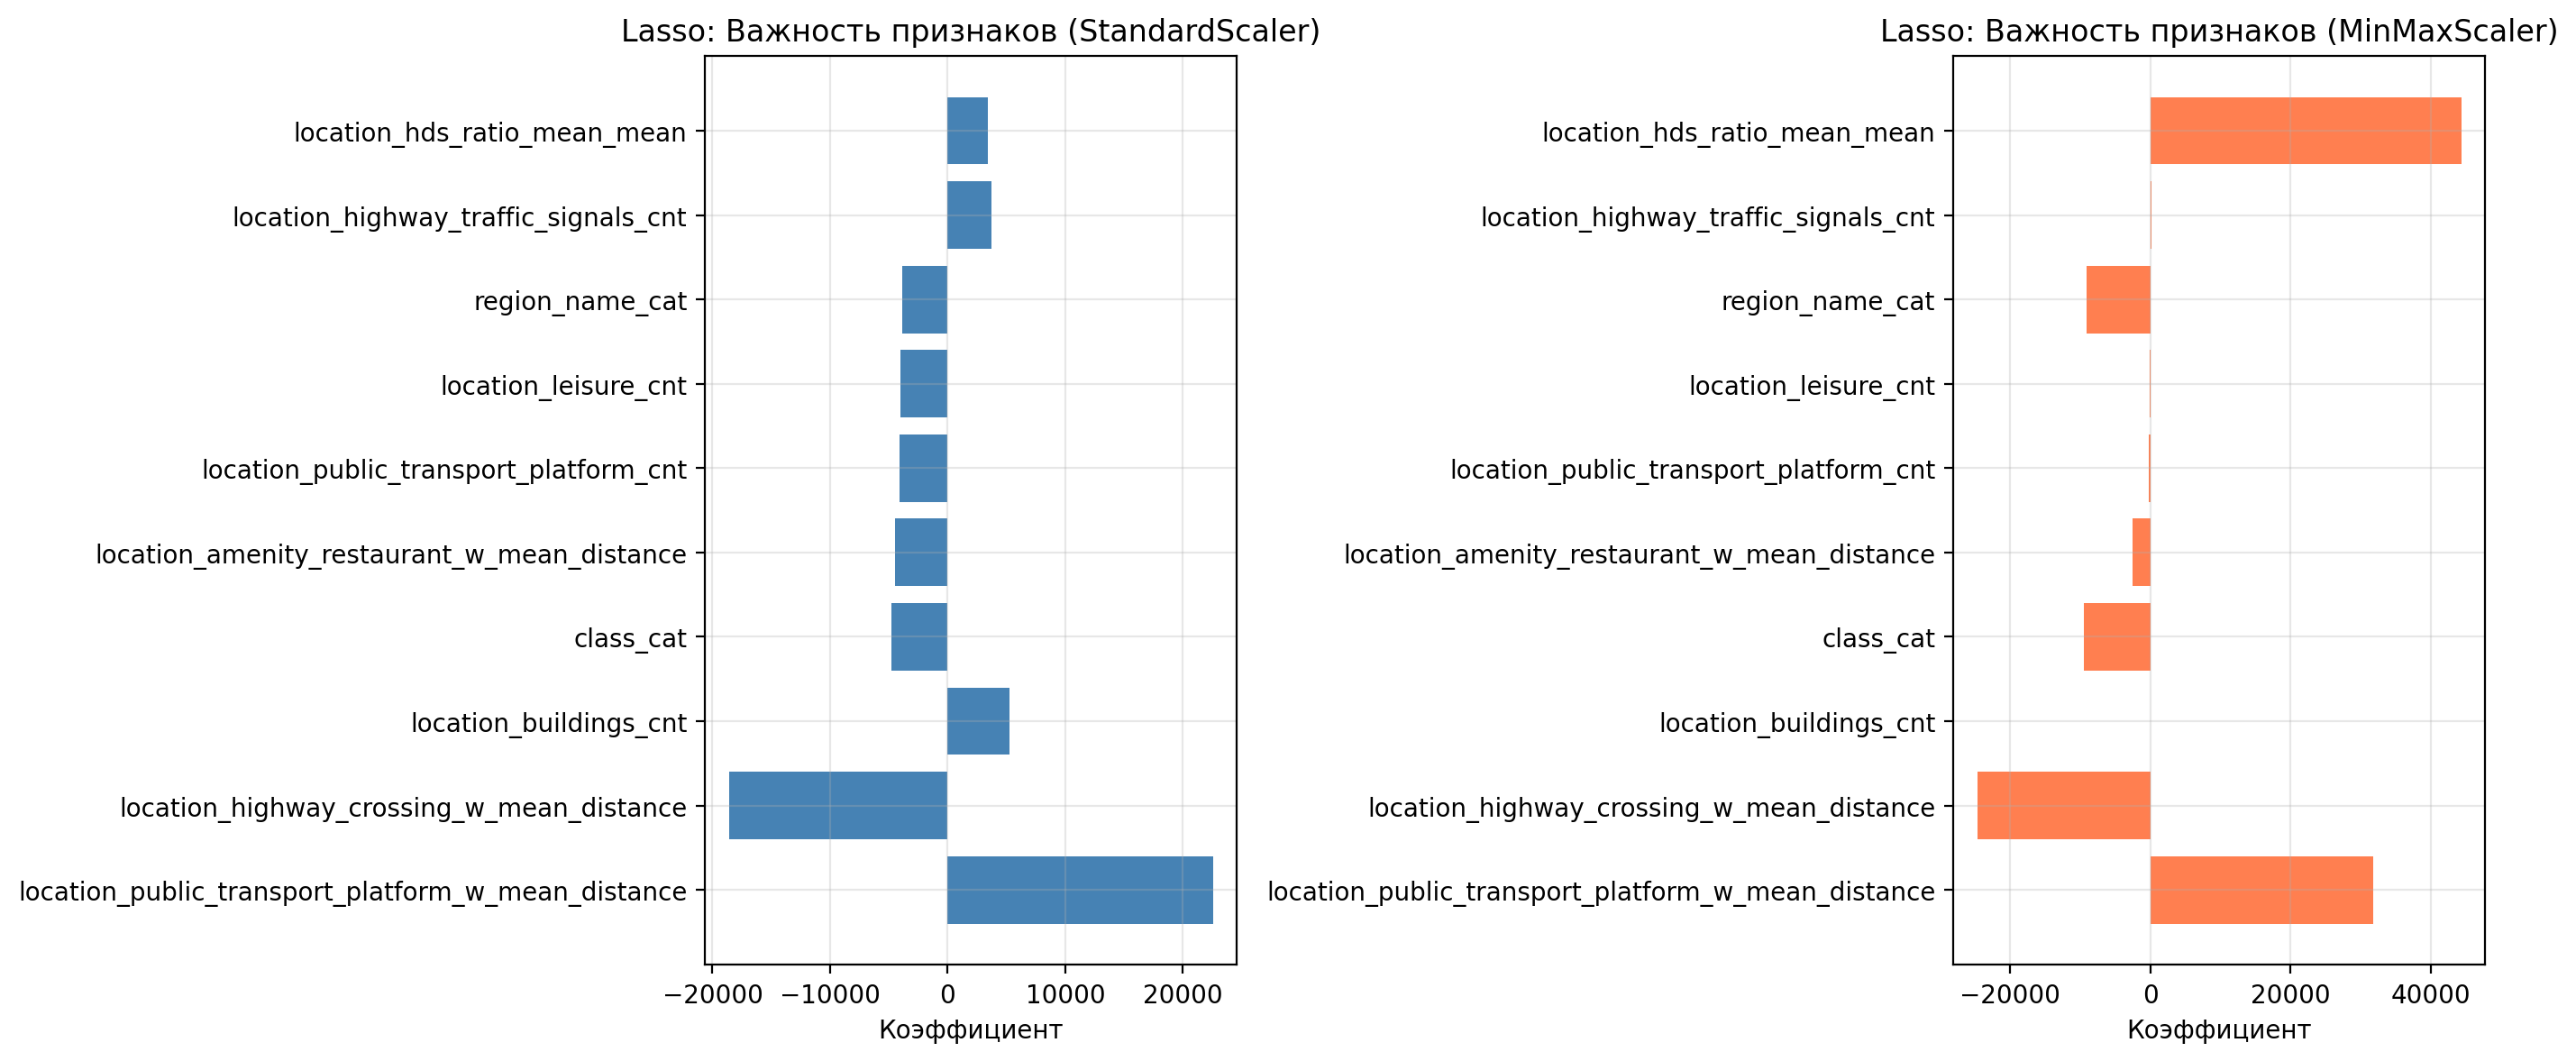

Корреляция между коэффициентами: 0.6725
RMSE Lasso с StandardScaler: 4857.93
RMSE Lasso с MinMaxScaler: 4931.75


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Топ признаков для StandardScaler
top_features = top_std['Feature'].values
axes[0].barh(range(len(top_features)), top_std['StandardScaler'].values, color='steelblue')
axes[0].set_yticks(range(len(top_features)))
axes[0].set_yticklabels(top_features)
axes[0].set_xlabel('Коэффициент')
axes[0].set_title('Lasso: Важность признаков (StandardScaler)')
axes[0].grid(True, alpha=0.3)

# Топ признаков для MinMaxScaler
axes[1].barh(range(len(top_features)), top_std['MinMaxScaler'].values, color='coral')
axes[1].set_yticks(range(len(top_features)))
axes[1].set_yticklabels(top_features)
axes[1].set_xlabel('Коэффициент')
axes[1].set_title('Lasso: Важность признаков (MinMaxScaler)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

correlation = np.corrcoef(coef_std, coef_minmax)[0, 1]
print(f"Корреляция между коэффициентами: {correlation:.4f}")

rmse_std = results['Lasso_std']['rmse']
rmse_minmax = results['Lasso']['rmse']
print(f"RMSE Lasso с StandardScaler: {rmse_std:.2f}")
print(f"RMSE Lasso с MinMaxScaler: {rmse_minmax:.2f}")

## Задание 2. 1 балл
Выберите 1 признак для анализа (можно категориальный, с не менее чем 5 уровнями, или дискретизируйте непрерывный). 
Используйте линейную регрессию и бустинг после применения MinMaxScaler. Что будет с моделями, если признаки выйдут из диапазона?
Постройте графики ICE и PDP для интерпретации исходных данных, а также искусственно добавив несколько выбросов, выходящих за оригинальные интервалы. 

Задание 2.1 (*) 1 балл: проанализируйте также еще один признак

In [17]:
selected_feature = 'location_pop_shop_cnt'

print(f"Выбранный признак: {selected_feature}")

feature_names = num_cols + cat_cols
if selected_feature in feature_names:
    selected_idx = feature_names.index(selected_feature)
else:
    raise ValueError(f"Признак {selected_feature} не найден")

original_values = X_train_processed[:, selected_idx]
original_min = original_values.min()
original_max = original_values.max()

scaled_min = X_train_minmax[:, selected_idx].min()
scaled_max = X_train_minmax[:, selected_idx].max()

print(f"Исходный диапазон: [{original_min:.3f}, {original_max:.3f}]")
print(f"Масштабированный диапазон: [{scaled_min:.3f}, {scaled_max:.3f}]")

Выбранный признак: location_pop_shop_cnt
Исходный диапазон: [0.000, 25.000]
Масштабированный диапазон: [0.000, 1.000]


In [18]:
def test_out_of_range(model, X_train, X_test, feature_idx, train_min, train_max):
    """Тестирует поведение модели при выходе признака за диапазон"""
    
    expand = (train_max - train_min) * 0.3
    low_range = np.linspace(train_min - expand, train_min, 20)[:-1]
    mid_range = np.linspace(train_min, train_max, 50)
    high_range = np.linspace(train_max, train_max + expand, 20)[1:]
    test_values = np.concatenate([low_range, mid_range, high_range])
    
    base_sample = X_test[0:1].copy()
    
    predictions = []
    for val in test_values:
        sample = base_sample.copy()
        sample[0, feature_idx] = val
        predictions.append(model.predict(sample)[0])
    
    return test_values, np.array(predictions)

def plot_ice_pdp(model, X_train, X_test, feature_idx, feature_name, title_prefix=""):
    """Строит ICE и PDP графики с выходом за пределы обучающего диапазона"""
    
    train_min = X_train[:, feature_idx].min()
    train_max = X_train[:, feature_idx].max()
    
    expand = (train_max - train_min) * 0.3
    grid = np.linspace(train_min - expand, train_max + expand, 100)
    
    pdp_values = []
    for val in grid:
        X_temp = X_test.copy()
        X_temp[:, feature_idx] = val
        pdp_values.append(np.mean(model.predict(X_temp)))
    
    n_objects = min(20, X_test.shape[0])
    ice_curves = []
    
    for i in range(n_objects):
        X_ice = X_test[i:i+1].copy()
        preds = []
        for val in grid:
            X_ice[0, feature_idx] = val
            preds.append(model.predict(X_ice)[0])
        ice_curves.append(preds)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    for curve in ice_curves:
        axes[0].plot(grid, curve, alpha=0.2, color='steelblue', linewidth=0.8)
    axes[0].plot(grid, pdp_values, 'r-', linewidth=2, label='PDP')
    axes[0].axvline(train_min, color='gray', linestyle='--', alpha=0.7, label='Обучающий диапазон')
    axes[0].axvline(train_max, color='gray', linestyle='--', alpha=0.7)
    axes[0].fill_between([train_min, train_max], min(pdp_values), max(pdp_values), 
                          alpha=0.1, color='green')
    axes[0].set_xlabel(f'{feature_name}')
    axes[0].set_ylabel('Предсказанная цена')
    axes[0].set_title(f'{title_prefix}ICE + PDP (с экстраполяцией)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    axes[1].plot(grid, pdp_values, 'g-', linewidth=2)
    axes[1].fill_between(grid, pdp_values, alpha=0.3, color='green')
    axes[1].axvline(train_min, color='gray', linestyle='--', alpha=0.7, label='Обучающий диапазон')
    axes[1].axvline(train_max, color='gray', linestyle='--', alpha=0.7)
    axes[1].fill_between([train_min, train_max], min(pdp_values), max(pdp_values), 
                          alpha=0.1, color='blue')
    axes[1].set_xlabel(f'{feature_name}')
    axes[1].set_ylabel('Среднее предсказание')
    axes[1].set_title(f'{title_prefix}PDP (с экстраполяцией)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return grid, pdp_values

In [19]:
lr_model = LinearRegression()
lr_model.fit(X_train_minmax, y_train)

gb_model = GradientBoostingRegressor(max_depth=5, random_state=42)
gb_model.fit(X_train_minmax, y_train)

print(f"LR R2: {lr_model.score(X_test_minmax, y_test):.3f}")
print(f"GB R2: {gb_model.score(X_test_minmax, y_test):.3f}")

LR R2: 0.727
GB R2: 0.894


Анализ поведения моделей при выходе за пределы диапазона


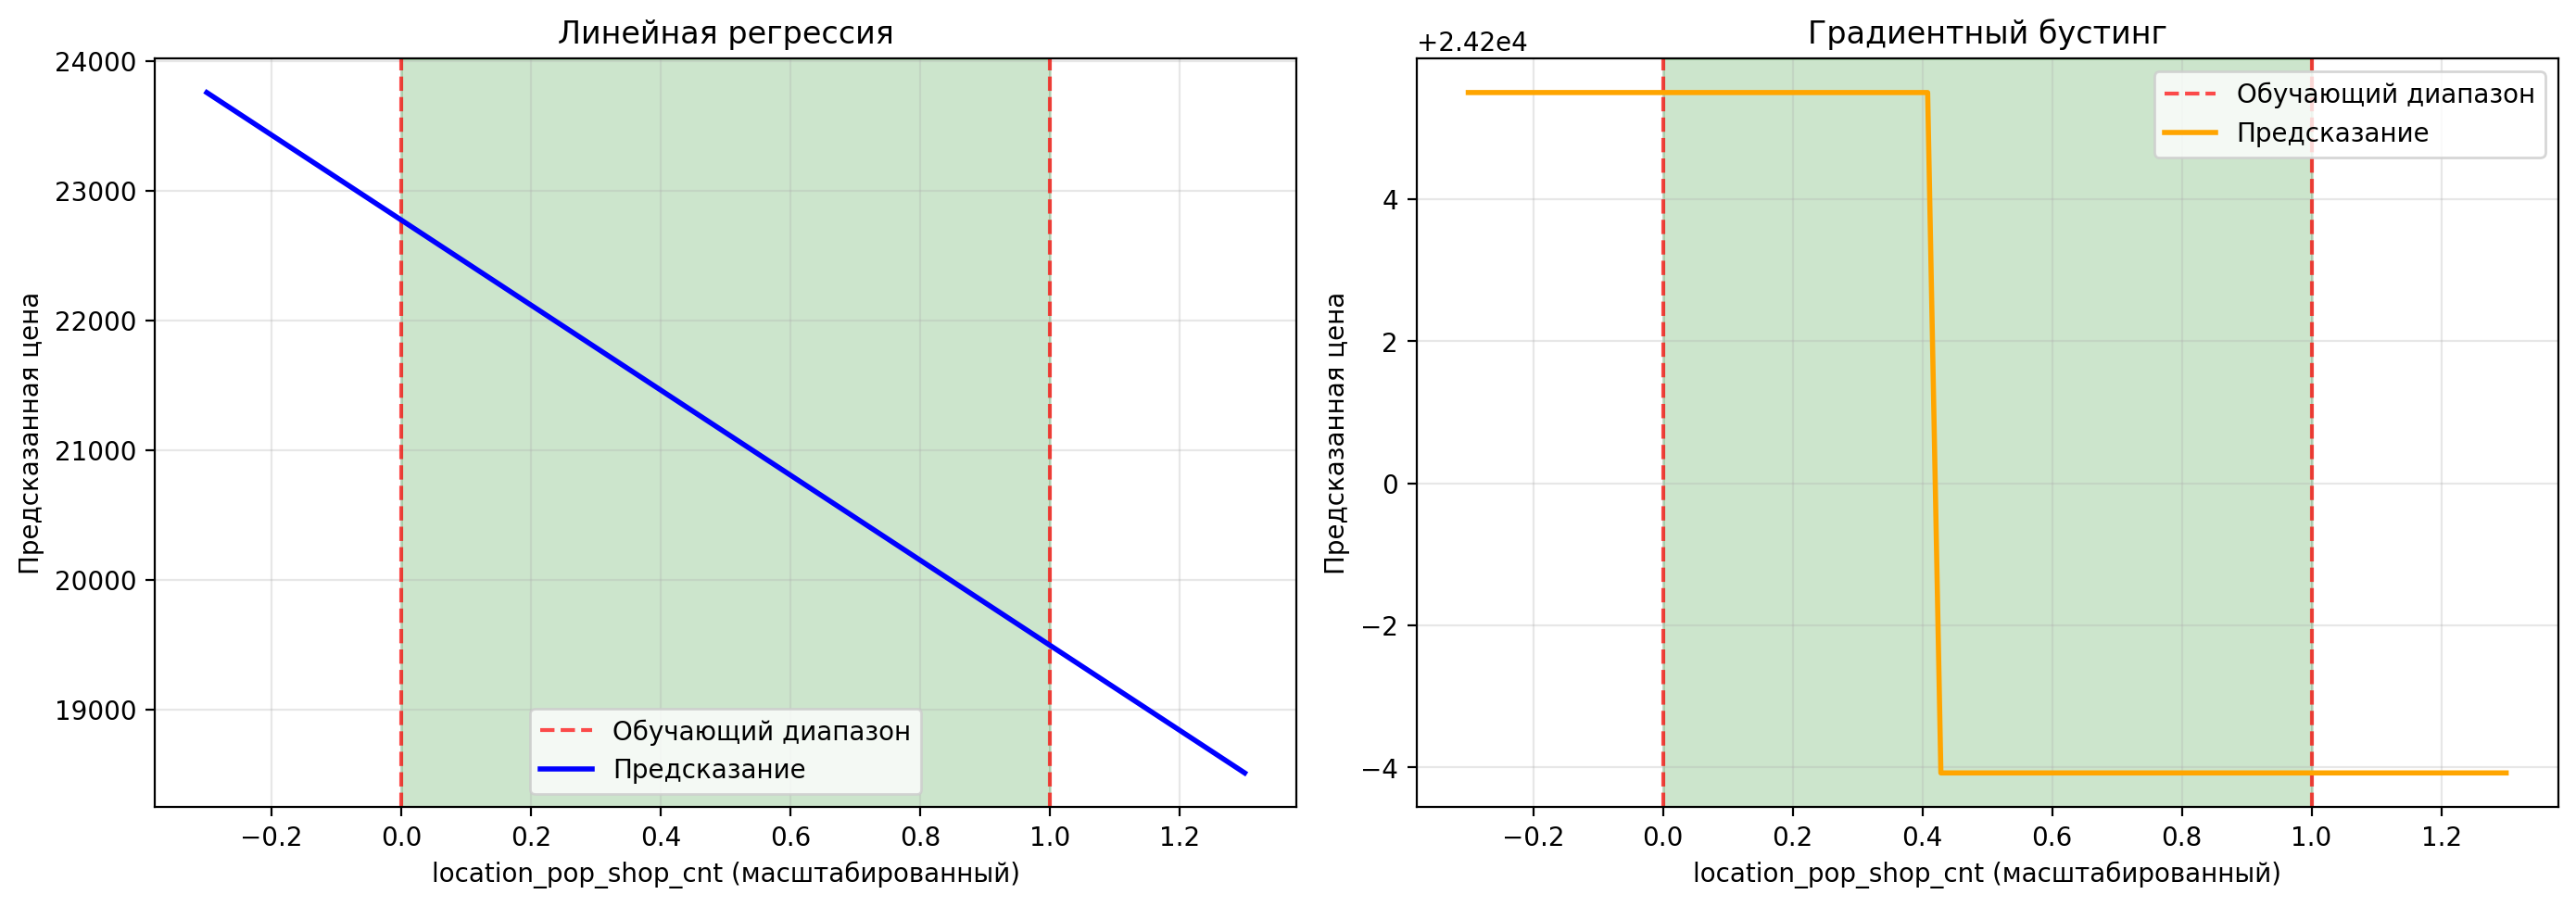

In [20]:
def test_out_of_range_scaled(model, X_train_scaled, X_test_scaled, feature_idx, 
                              train_min_scaled, train_max_scaled, original_min, original_max):
    """Тестирует поведение модели при выходе признака за диапазон"""
    
    expand = (train_max_scaled - train_min_scaled) * 0.3
    low_range = np.linspace(train_min_scaled - expand, train_min_scaled, 20)[:-1]
    mid_range = np.linspace(train_min_scaled, train_max_scaled, 50)
    high_range = np.linspace(train_max_scaled, train_max_scaled + expand, 20)[1:]
    test_values_scaled = np.concatenate([low_range, mid_range, high_range])
    
    base_sample = X_test_scaled[0:1].copy()
    
    predictions = []
    for val in test_values_scaled:
        sample = base_sample.copy()
        sample[0, feature_idx] = val
        predictions.append(model.predict(sample)[0])
    
    return test_values_scaled, np.array(predictions)

print("Анализ поведения моделей при выходе за пределы диапазона")

scaled_min = X_train_minmax[:, selected_idx].min()
scaled_max = X_train_minmax[:, selected_idx].max()

lr_vals, lr_preds = test_out_of_range_scaled(lr_model, X_train_minmax, X_test_minmax, 
                                                selected_idx, scaled_min, scaled_max,
                                                original_min, original_max)
gb_vals, gb_preds = test_out_of_range_scaled(gb_model, X_train_minmax, X_test_minmax, 
                                                selected_idx, scaled_min, scaled_max,
                                                original_min, original_max)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Линейная регрессия
axes[0].axvline(scaled_min, color='red', linestyle='--', alpha=0.7, label='Обучающий диапазон')
axes[0].axvline(scaled_max, color='red', linestyle='--', alpha=0.7)
axes[0].axvspan(scaled_min, scaled_max, alpha=0.2, color='green')
axes[0].plot(lr_vals, lr_preds, 'b-', linewidth=2, label='Предсказание')
axes[0].set_xlabel(f'{selected_feature} (масштабированный)')
axes[0].set_ylabel('Предсказанная цена')
axes[0].set_title('Линейная регрессия')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Градиентный бустинг
axes[1].axvline(scaled_min, color='red', linestyle='--', alpha=0.7, label='Обучающий диапазон')
axes[1].axvline(scaled_max, color='red', linestyle='--', alpha=0.7)
axes[1].axvspan(scaled_min, scaled_max, alpha=0.2, color='green')
axes[1].plot(gb_vals, gb_preds, 'orange', linewidth=2, label='Предсказание')
axes[1].set_xlabel(f'{selected_feature} (масштабированный)')
axes[1].set_ylabel('Предсказанная цена')
axes[1].set_title('Градиентный бустинг')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

ICE и PDP для исходных данных

Линейная регрессия:


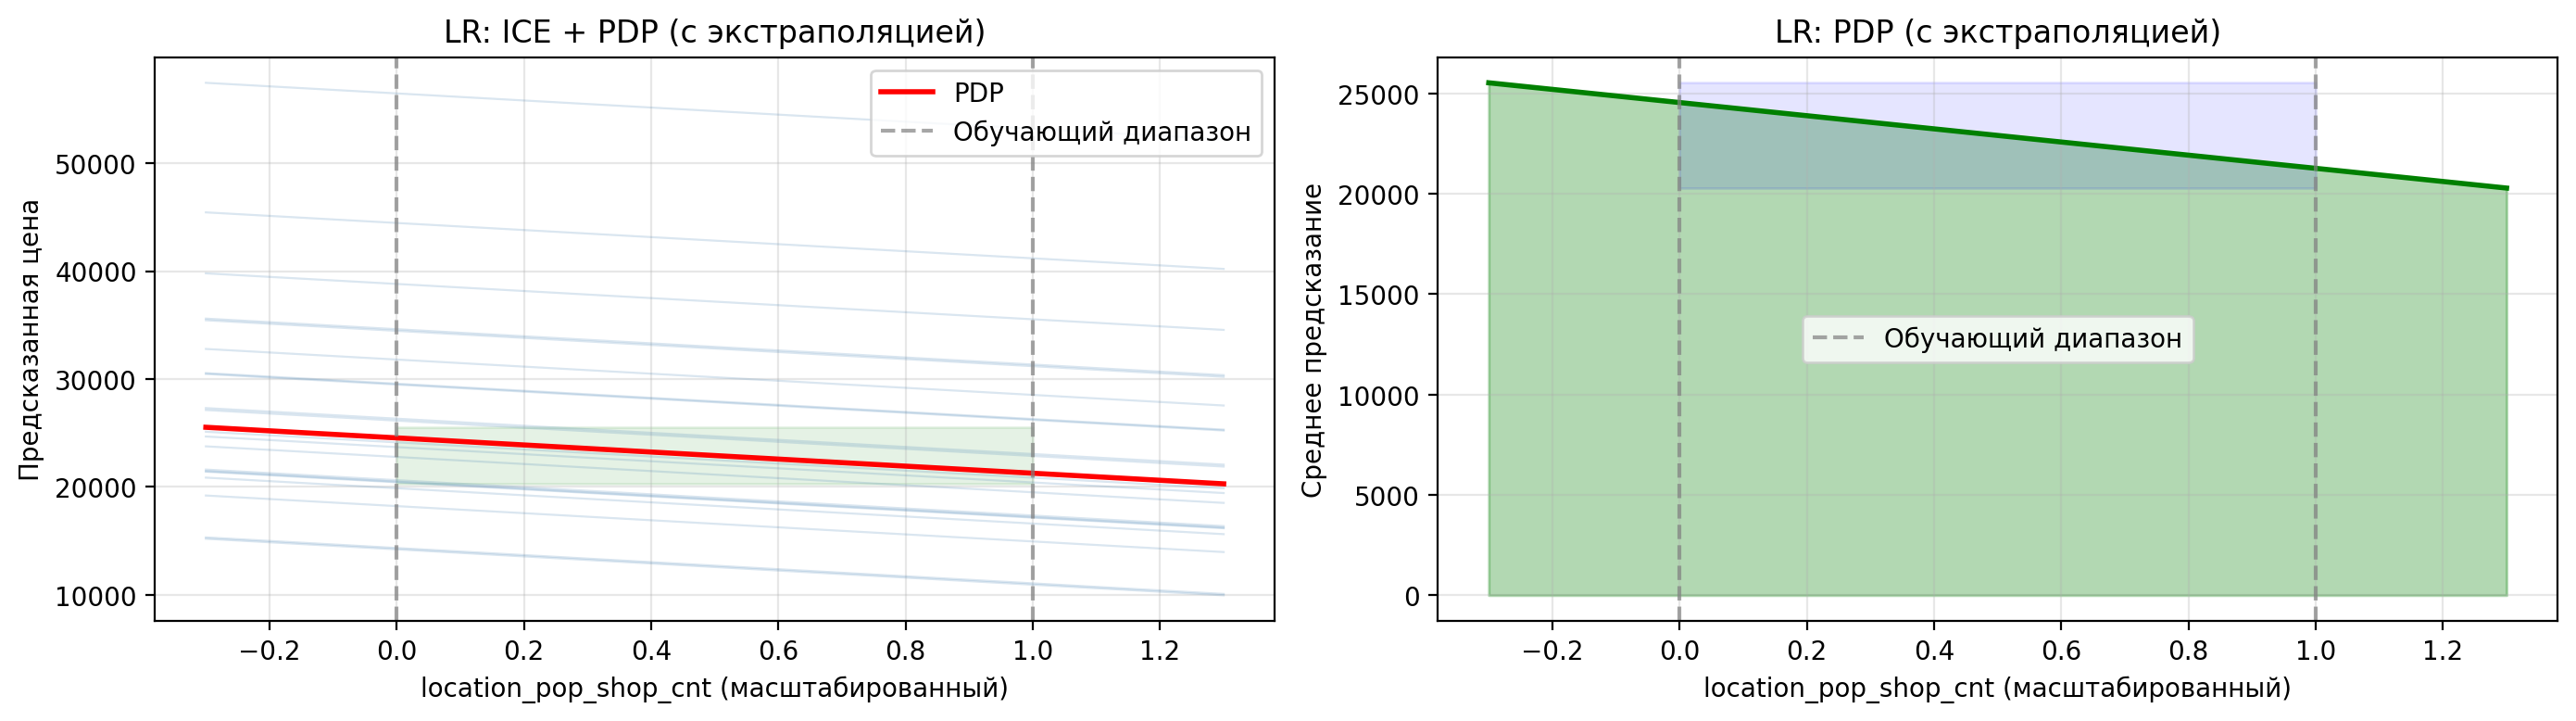


Градиентный бустинг:


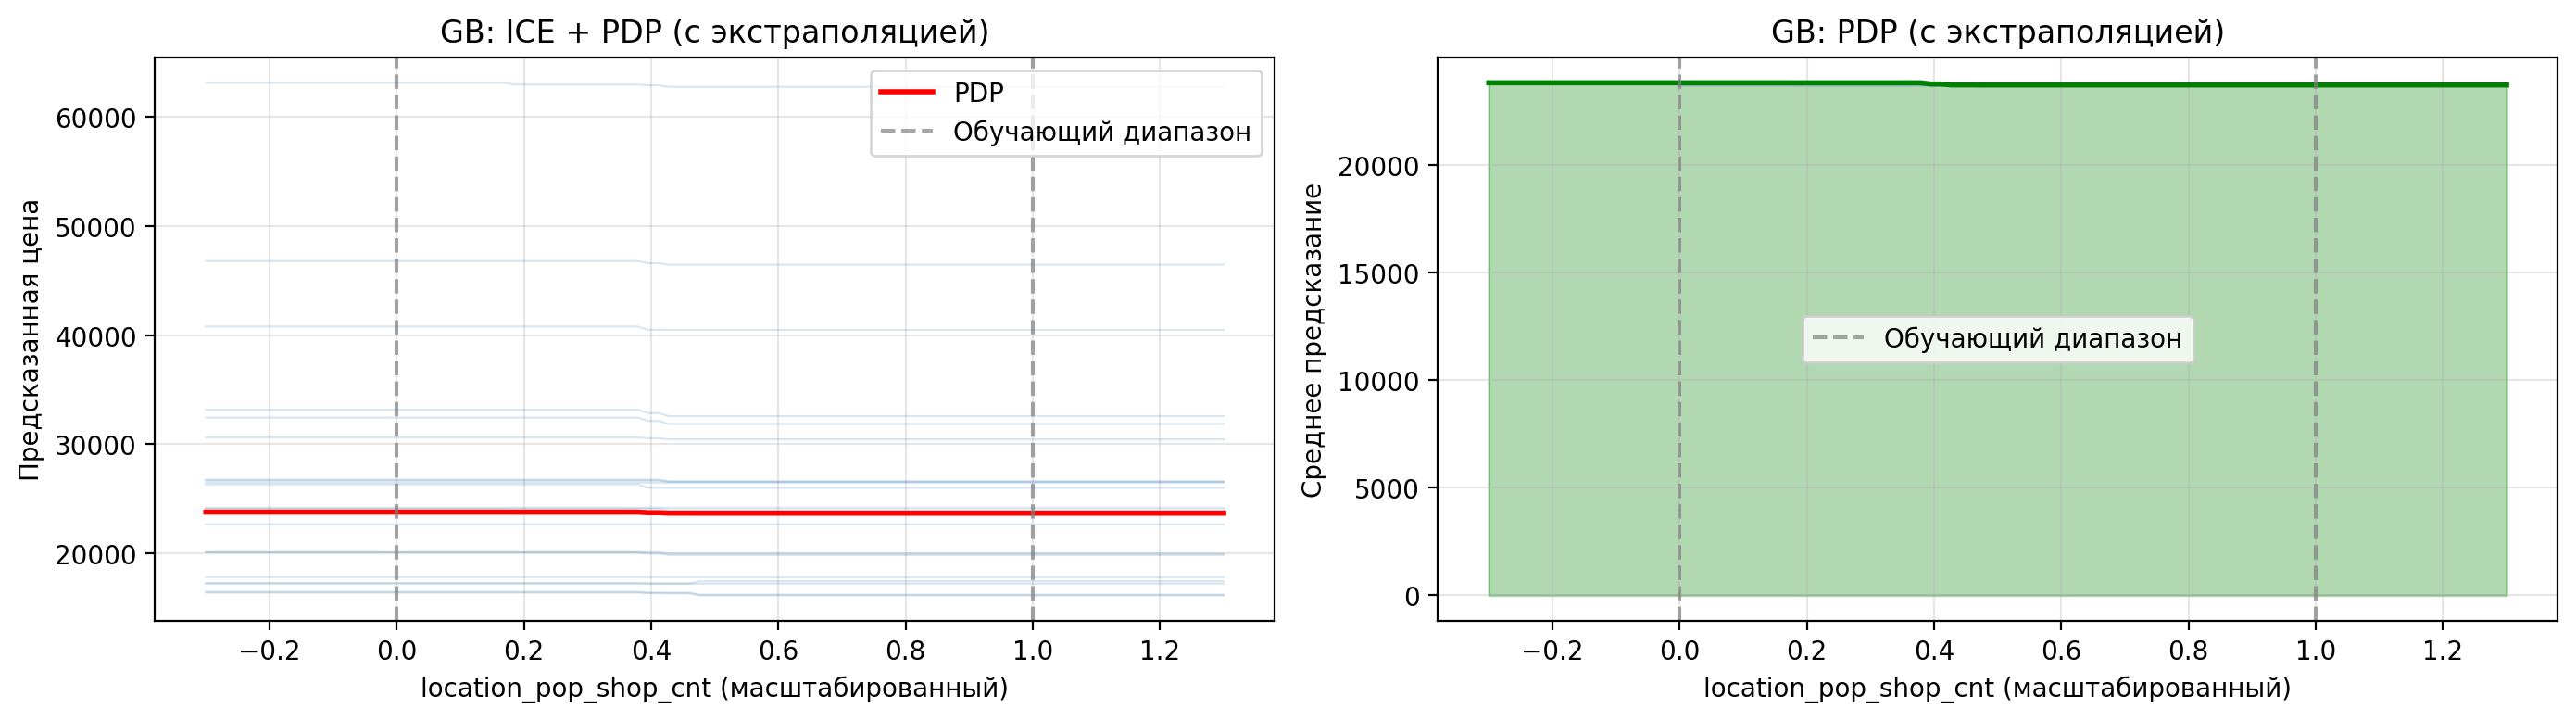

In [21]:
print("ICE и PDP для исходных данных")

scaled_min = X_train_minmax[:, selected_idx].min()
scaled_max = X_train_minmax[:, selected_idx].max()

def plot_ice_pdp_scaled(model, X_train_scaled, X_test_scaled, feature_idx, feature_name, title_prefix=""):
    """Строит ICE и PDP графики с выходом за пределы обучающего диапазона"""
    
    train_min = X_train_scaled[:, feature_idx].min()
    train_max = X_train_scaled[:, feature_idx].max()
    
    expand = (train_max - train_min) * 0.3
    grid = np.linspace(train_min - expand, train_max + expand, 100)
    
    pdp_values = []
    for val in grid:
        X_temp = X_test_scaled.copy()
        X_temp[:, feature_idx] = val
        pdp_values.append(np.mean(model.predict(X_temp)))
    
    n_objects = min(20, X_test_scaled.shape[0])
    ice_curves = []
    
    for i in range(n_objects):
        X_ice = X_test_scaled[i:i+1].copy()
        preds = []
        for val in grid:
            X_ice[0, feature_idx] = val
            preds.append(model.predict(X_ice)[0])
        ice_curves.append(preds)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    for curve in ice_curves:
        axes[0].plot(grid, curve, alpha=0.2, color='steelblue', linewidth=0.8)
    axes[0].plot(grid, pdp_values, 'r-', linewidth=2, label='PDP')
    axes[0].axvline(train_min, color='gray', linestyle='--', alpha=0.7, label='Обучающий диапазон')
    axes[0].axvline(train_max, color='gray', linestyle='--', alpha=0.7)
    axes[0].fill_between([train_min, train_max], min(pdp_values), max(pdp_values), 
                          alpha=0.1, color='green')
    axes[0].set_xlabel(f'{feature_name} (масштабированный)')
    axes[0].set_ylabel('Предсказанная цена')
    axes[0].set_title(f'{title_prefix}ICE + PDP (с экстраполяцией)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    axes[1].plot(grid, pdp_values, 'g-', linewidth=2)
    axes[1].fill_between(grid, pdp_values, alpha=0.3, color='green')
    axes[1].axvline(train_min, color='gray', linestyle='--', alpha=0.7, label='Обучающий диапазон')
    axes[1].axvline(train_max, color='gray', linestyle='--', alpha=0.7)
    axes[1].fill_between([train_min, train_max], min(pdp_values), max(pdp_values), 
                          alpha=0.1, color='blue')
    axes[1].set_xlabel(f'{feature_name} (масштабированный)')
    axes[1].set_ylabel('Среднее предсказание')
    axes[1].set_title(f'{title_prefix}PDP (с экстраполяцией)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return grid, pdp_values

print("\nЛинейная регрессия:")
grid_lr, pdp_lr = plot_ice_pdp_scaled(lr_model, X_train_minmax, X_test_minmax, 
                                selected_idx, selected_feature, "LR: ")

print("\nГрадиентный бустинг:")
grid_gb, pdp_gb = plot_ice_pdp_scaled(gb_model, X_train_minmax, X_test_minmax, 
                                selected_idx, selected_feature, "GB: ")

In [22]:
print("Создание данных с выбросами")

scaled_min = X_train_minmax[:, selected_idx].min()
scaled_max = X_train_minmax[:, selected_idx].max()

X_train_with_outliers = X_train_minmax.copy()
y_train_with_outliers = y_train.copy()

n_samples = X_train_with_outliers.shape[0]
n_outliers = min(100, n_samples // 10)  # 10% выбросов

expand = (scaled_max - scaled_min) * 0.3

low_outliers = np.random.uniform(scaled_min - expand, scaled_min, n_outliers)
high_outliers = np.random.uniform(scaled_max, scaled_max + expand, n_outliers)

outlier_indices = np.random.choice(n_samples, n_outliers * 2, replace=False)
X_train_with_outliers[outlier_indices[:n_outliers], selected_idx] = low_outliers
X_train_with_outliers[outlier_indices[n_outliers:], selected_idx] = high_outliers


outlier_mask = np.zeros(n_samples, dtype=bool)
outlier_mask[outlier_indices[:n_outliers]] = True
outlier_mask[outlier_indices[n_outliers:]] = True

y_train_with_outliers[outlier_mask] = y_train_with_outliers[outlier_mask] * np.random.uniform(1.5, 3.0, n_outliers * 2)

print(f"Добавлено {n_outliers} выбросов ниже минимума")
print(f"Добавлено {n_outliers} выбросов выше максимума")
print(f"Новый диапазон признака: [{X_train_with_outliers[:, selected_idx].min():.3f}, {X_train_with_outliers[:, selected_idx].max():.3f}]")
print(f"Новый диапазон целевой переменной: [{y_train_with_outliers.min():.2f}, {y_train_with_outliers.max():.2f}]")

lr_model_outliers = LinearRegression()
lr_model_outliers.fit(X_train_with_outliers, y_train_with_outliers)

gb_model_outliers = GradientBoostingRegressor(max_depth=5, random_state=42)
gb_model_outliers.fit(X_train_with_outliers, y_train_with_outliers)

print(f"\nLR R2 (без выбросов): {lr_model.score(X_test_minmax, y_test):.3f}")
print(f"LR R2 (с выбросами): {lr_model_outliers.score(X_test_minmax, y_test):.3f}")
print(f"\nGB R2 (без выбросов): {gb_model.score(X_test_minmax, y_test):.3f}")
print(f"GB R2 (с выбросами): {gb_model_outliers.score(X_test_minmax, y_test):.3f}")

Создание данных с выбросами
Добавлено 100 выбросов ниже минимума
Добавлено 100 выбросов выше максимума
Новый диапазон признака: [-0.300, 1.297]
Новый диапазон целевой переменной: [15863.23, 204943.80]

LR R2 (без выбросов): 0.727
LR R2 (с выбросами): 0.722

GB R2 (без выбросов): 0.894
GB R2 (с выбросами): 0.889


ICE и PDP для данных с выбросами

Линейная регрессия:


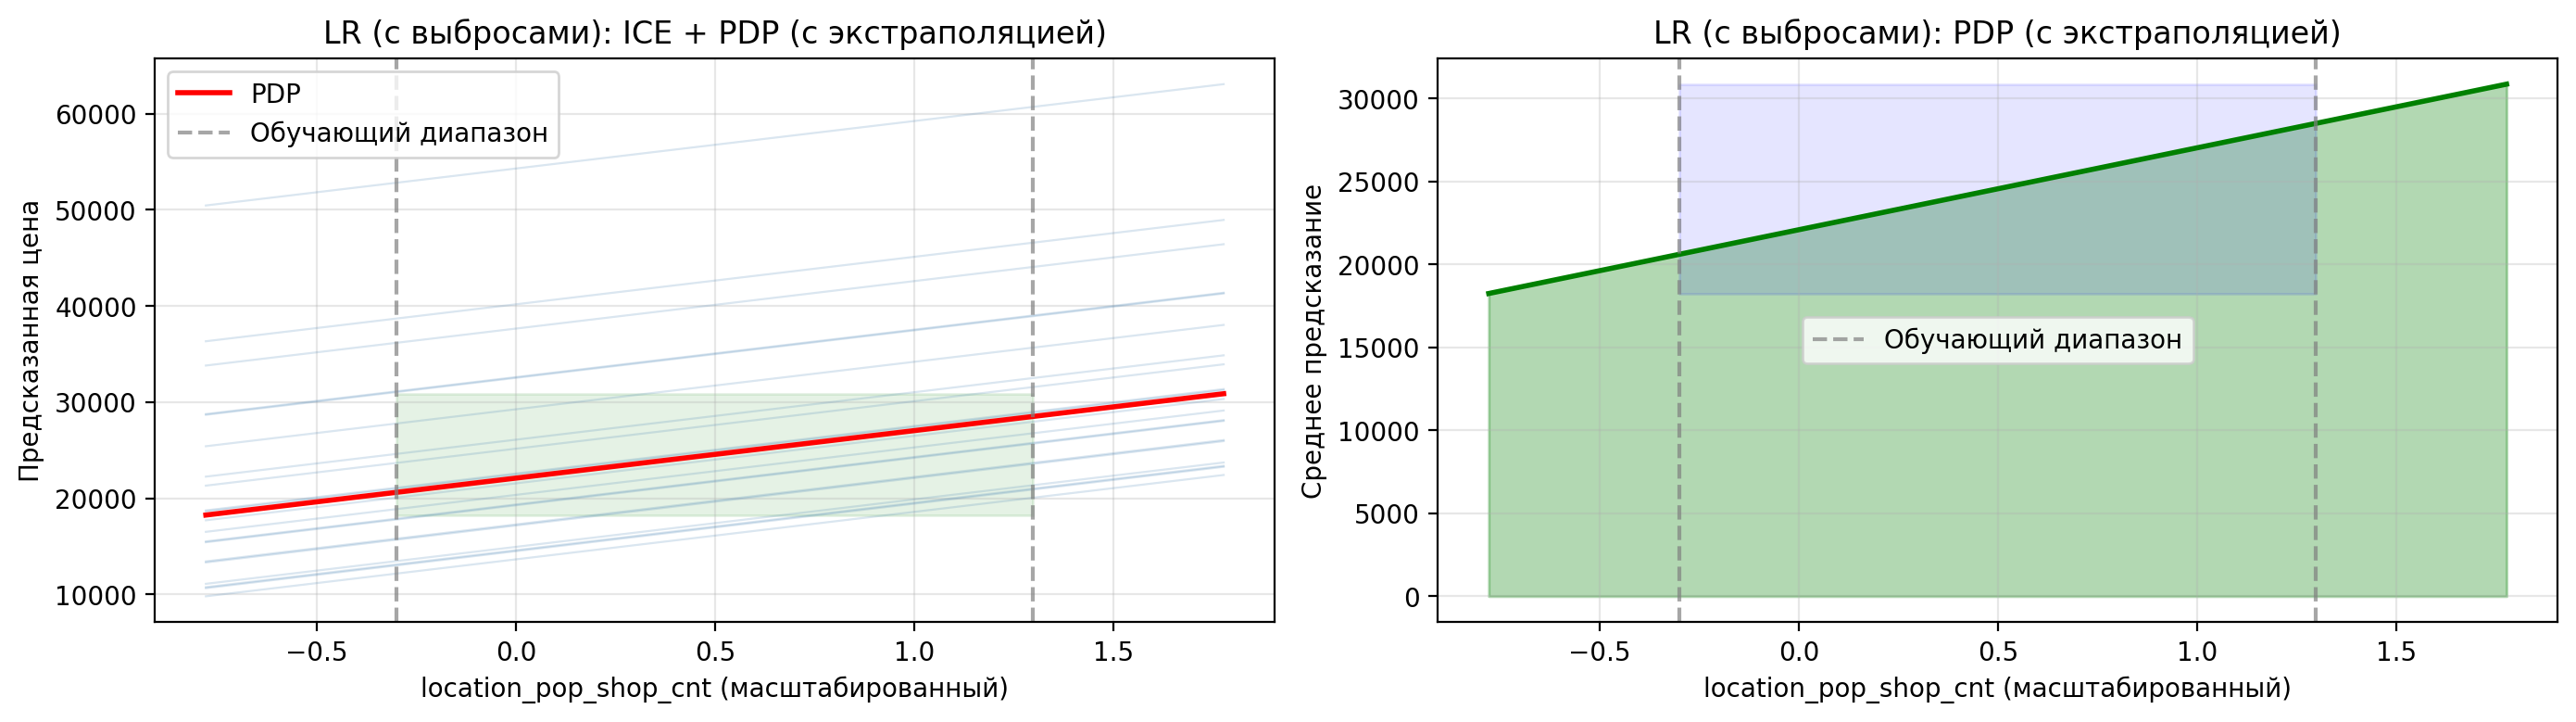


Градиентный бустинг:


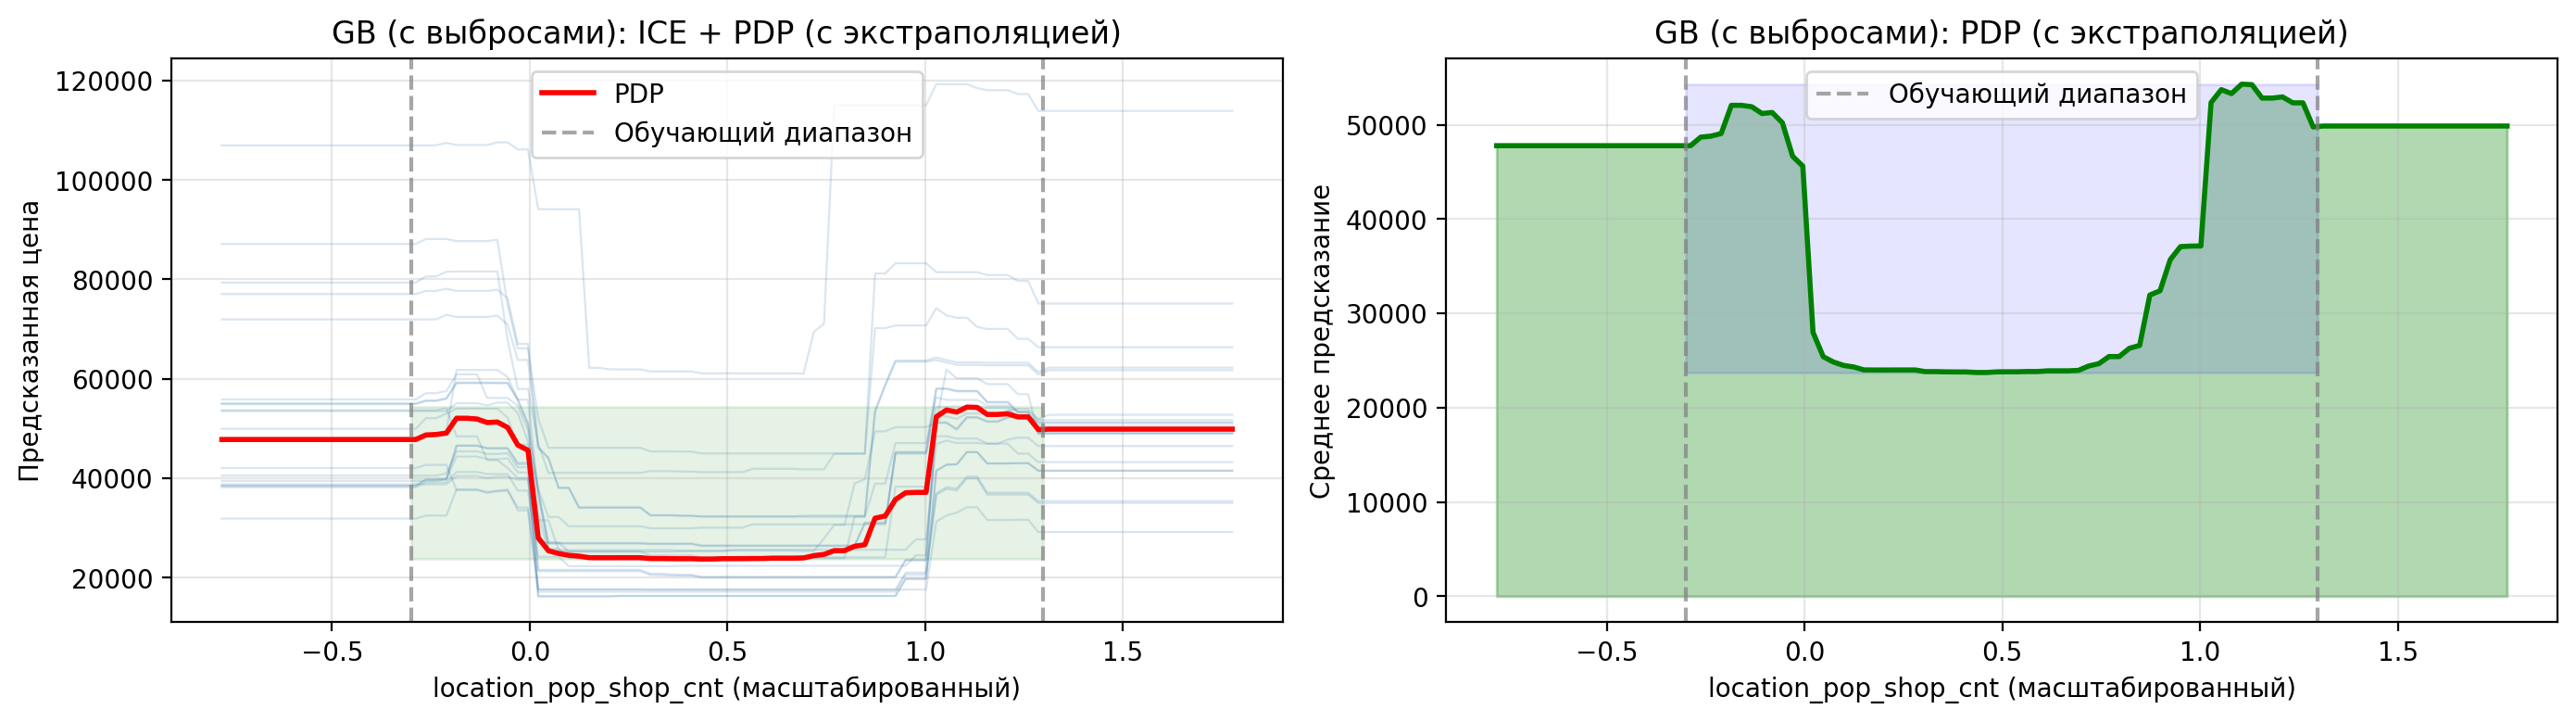

In [23]:
print("ICE и PDP для данных с выбросами")

print("\nЛинейная регрессия:")
grid_lr_out, pdp_lr_out = plot_ice_pdp_scaled(lr_model_outliers, X_train_with_outliers, X_test_minmax, 
                                                selected_idx, selected_feature, "LR (с выбросами): ")

print("\nГрадиентный бустинг:")
grid_gb_out, pdp_gb_out = plot_ice_pdp_scaled(gb_model_outliers, X_train_with_outliers, X_test_minmax, 
                                                selected_idx, selected_feature, "GB (с выбросами): ")

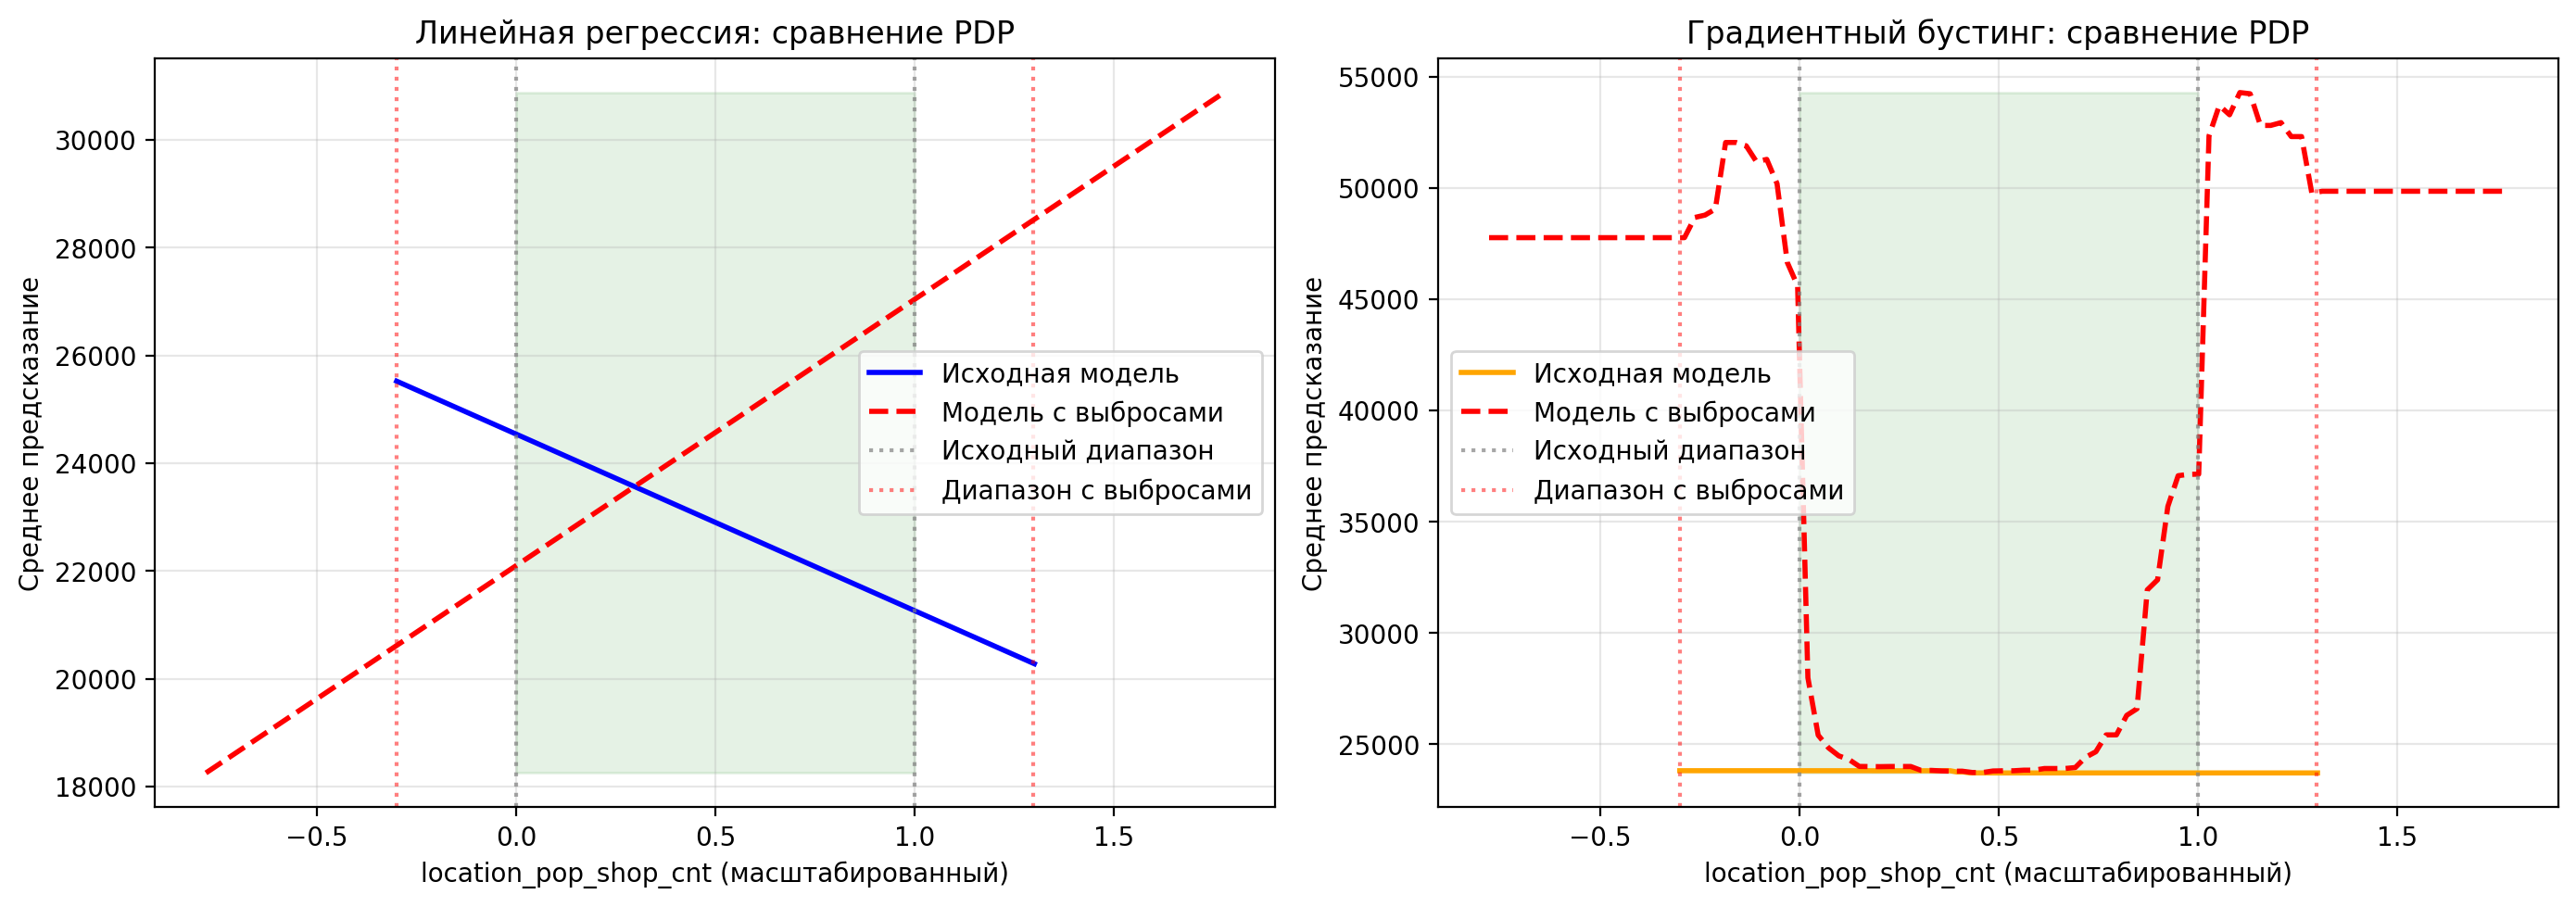


Анализ влияния выбросов

Линейная регрессия:
  Изменение предсказаний на левой границе: 25521.22 => 18254.20 (изменение: -7267.02)
  Изменение предсказаний на правой границе: 20279.22 => 30874.78 (изменение: 10595.55)

Градиентный бустинг:
  Изменение предсказаний на левой границе: 23806.77 => 47770.78 (изменение: 23964.01)
  Изменение предсказаний на правой границе: 23706.59 => 49857.41 (изменение: 26150.81)

Коэффициенты линейной регрессии для признака location_pop_shop_cnt:
  Исходная модель: -3276.2492
  Модель с выбросами: 4940.3991


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

scaled_min_original = X_train_minmax[:, selected_idx].min()
scaled_max_original = X_train_minmax[:, selected_idx].max()

scaled_min_outliers = X_train_with_outliers[:, selected_idx].min()
scaled_max_outliers = X_train_with_outliers[:, selected_idx].max()

# Линейная регрессия
axes[0].plot(grid_lr, pdp_lr, 'b-', linewidth=2, label='Исходная модель')
axes[0].plot(grid_lr_out, pdp_lr_out, 'r--', linewidth=2, label='Модель с выбросами')
axes[0].axvline(scaled_min_original, color='gray', linestyle=':', alpha=0.7, label='Исходный диапазон')
axes[0].axvline(scaled_max_original, color='gray', linestyle=':', alpha=0.7)
axes[0].axvline(scaled_min_outliers, color='red', linestyle=':', alpha=0.5, label='Диапазон с выбросами')
axes[0].axvline(scaled_max_outliers, color='red', linestyle=':', alpha=0.5)
axes[0].fill_between([scaled_min_original, scaled_max_original], 
                      min(min(pdp_lr), min(pdp_lr_out)), 
                      max(max(pdp_lr), max(pdp_lr_out)), 
                      alpha=0.1, color='green')
axes[0].set_xlabel(f'{selected_feature} (масштабированный)')
axes[0].set_ylabel('Среднее предсказание')
axes[0].set_title('Линейная регрессия: сравнение PDP')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Градиентный бустинг
axes[1].plot(grid_gb, pdp_gb, 'orange', linewidth=2, label='Исходная модель')
axes[1].plot(grid_gb_out, pdp_gb_out, 'r--', linewidth=2, label='Модель с выбросами')
axes[1].axvline(scaled_min_original, color='gray', linestyle=':', alpha=0.7, label='Исходный диапазон')
axes[1].axvline(scaled_max_original, color='gray', linestyle=':', alpha=0.7)
axes[1].axvline(scaled_min_outliers, color='red', linestyle=':', alpha=0.5, label='Диапазон с выбросами')
axes[1].axvline(scaled_max_outliers, color='red', linestyle=':', alpha=0.5)
axes[1].fill_between([scaled_min_original, scaled_max_original], 
                      min(min(pdp_gb), min(pdp_gb_out)), 
                      max(max(pdp_gb), max(pdp_gb_out)), 
                      alpha=0.1, color='green')
axes[1].set_xlabel(f'{selected_feature} (масштабированный)')
axes[1].set_ylabel('Среднее предсказание')
axes[1].set_title('Градиентный бустинг: сравнение PDP')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nАнализ влияния выбросов")
print(f"\nЛинейная регрессия:")
print(f"  Изменение предсказаний на левой границе: {pdp_lr[0]:.2f} => {pdp_lr_out[0]:.2f} (изменение: {pdp_lr_out[0]-pdp_lr[0]:.2f})")
print(f"  Изменение предсказаний на правой границе: {pdp_lr[-1]:.2f} => {pdp_lr_out[-1]:.2f} (изменение: {pdp_lr_out[-1]-pdp_lr[-1]:.2f})")

print(f"\nГрадиентный бустинг:")
print(f"  Изменение предсказаний на левой границе: {pdp_gb[0]:.2f} => {pdp_gb_out[0]:.2f} (изменение: {pdp_gb_out[0]-pdp_gb[0]:.2f})")
print(f"  Изменение предсказаний на правой границе: {pdp_gb[-1]:.2f} => {pdp_gb_out[-1]:.2f} (изменение: {pdp_gb_out[-1]-pdp_gb[-1]:.2f})")

print(f"\nКоэффициенты линейной регрессии для признака {selected_feature}:")
print(f"  Исходная модель: {lr_model.coef_[selected_idx]:.4f}")
print(f"  Модель с выбросами: {lr_model_outliers.coef_[selected_idx]:.4f}")

Задание 2.1: Анализ признака 'floor'
Исходный диапазон: [-9.000, 211.000]
Масштабированный диапазон: [0.000, 1.000]

Анализ экстраполяции для исходных моделей:


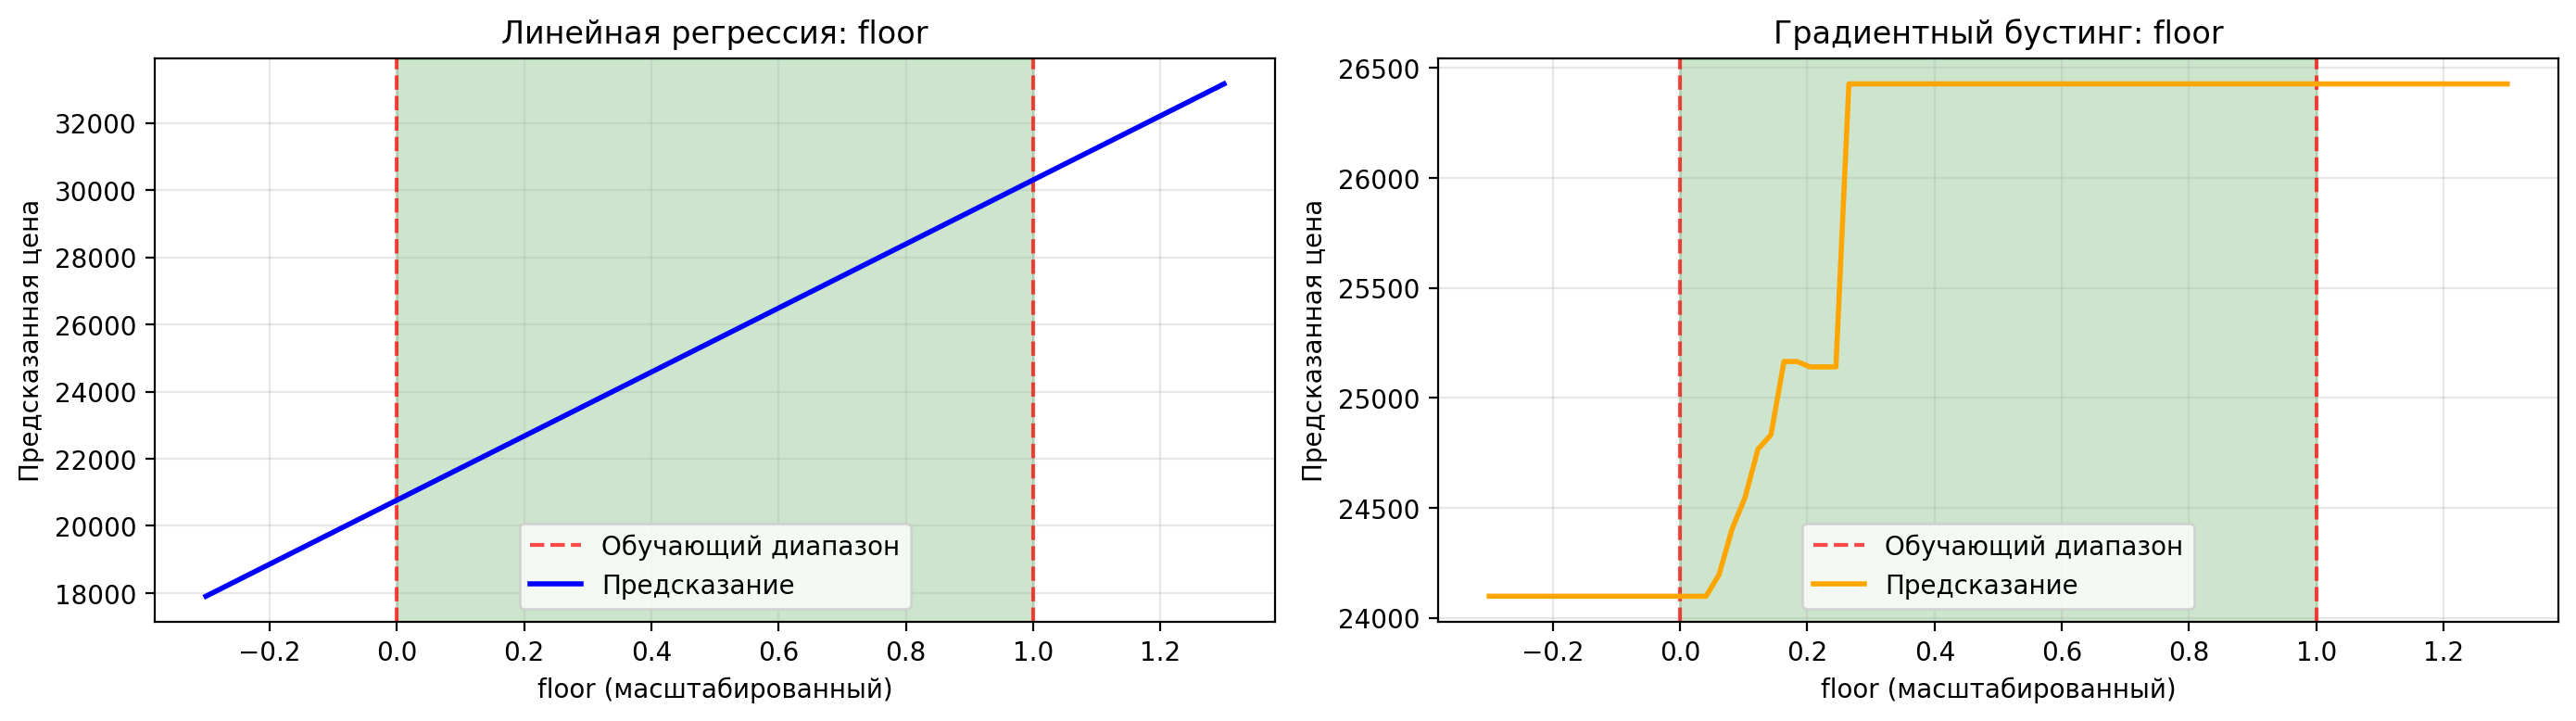


ICE и PDP для исходных данных:

Линейная регрессия:


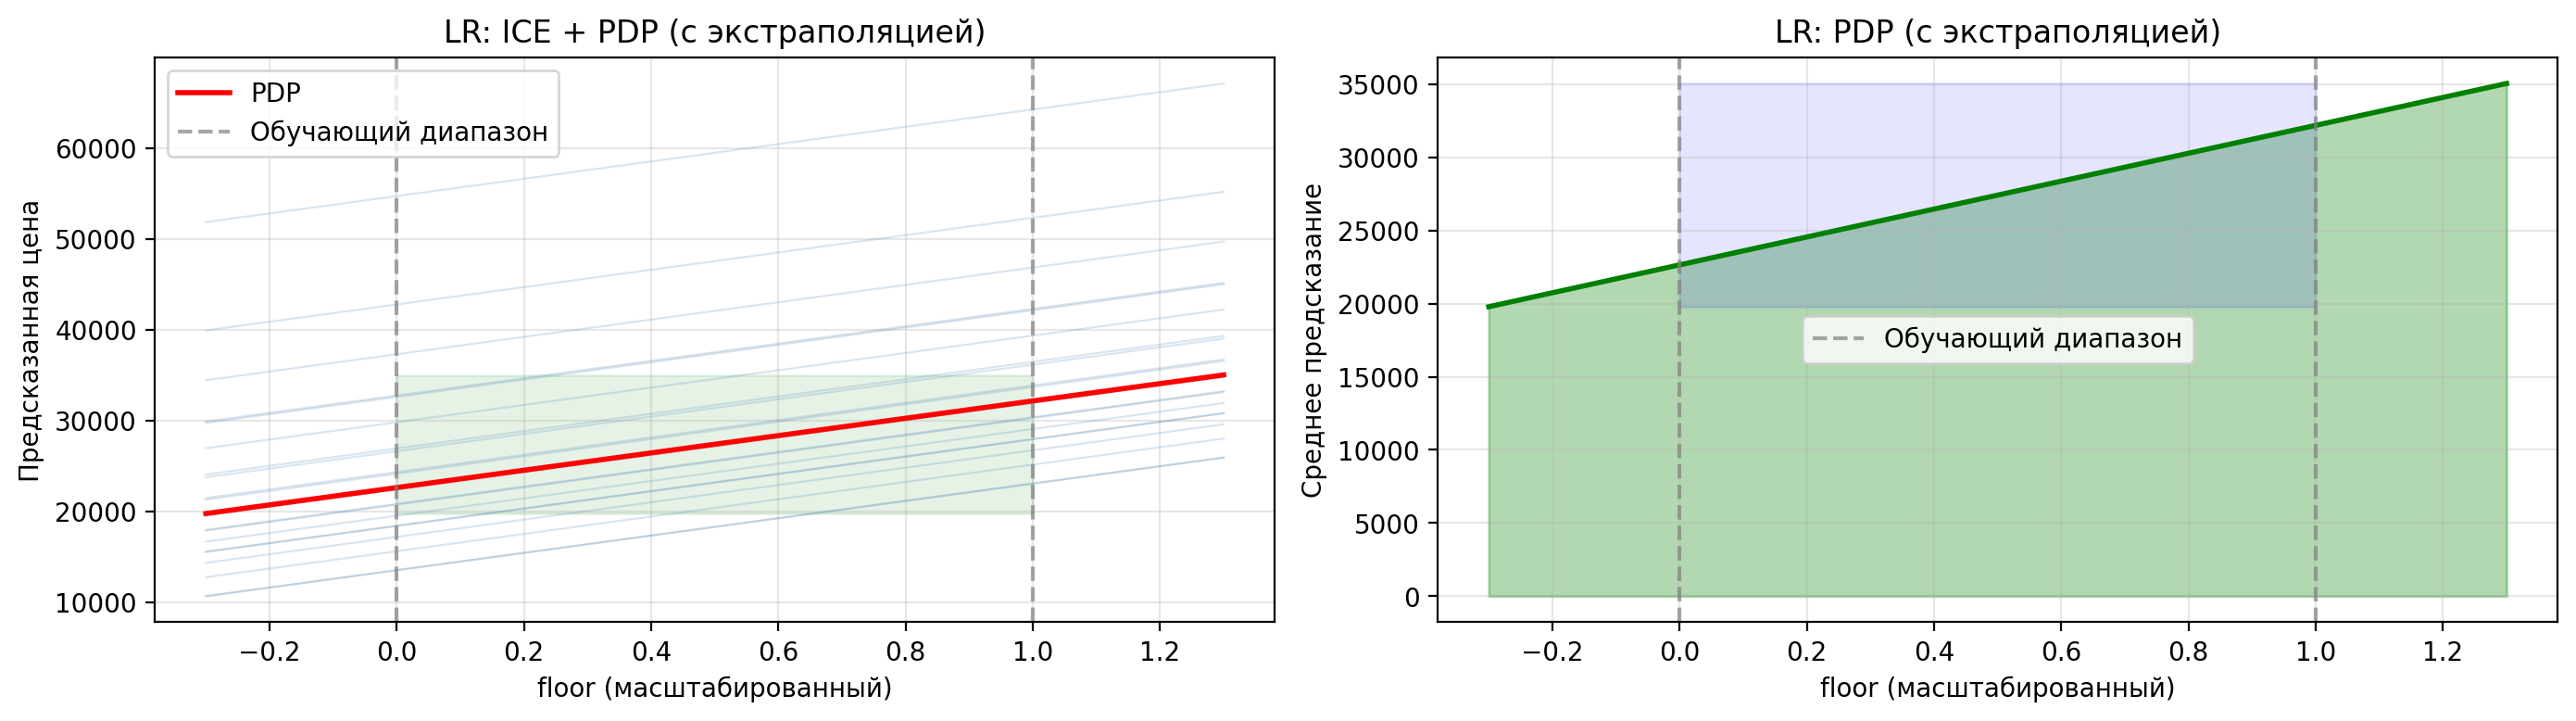


Градиентный бустинг:


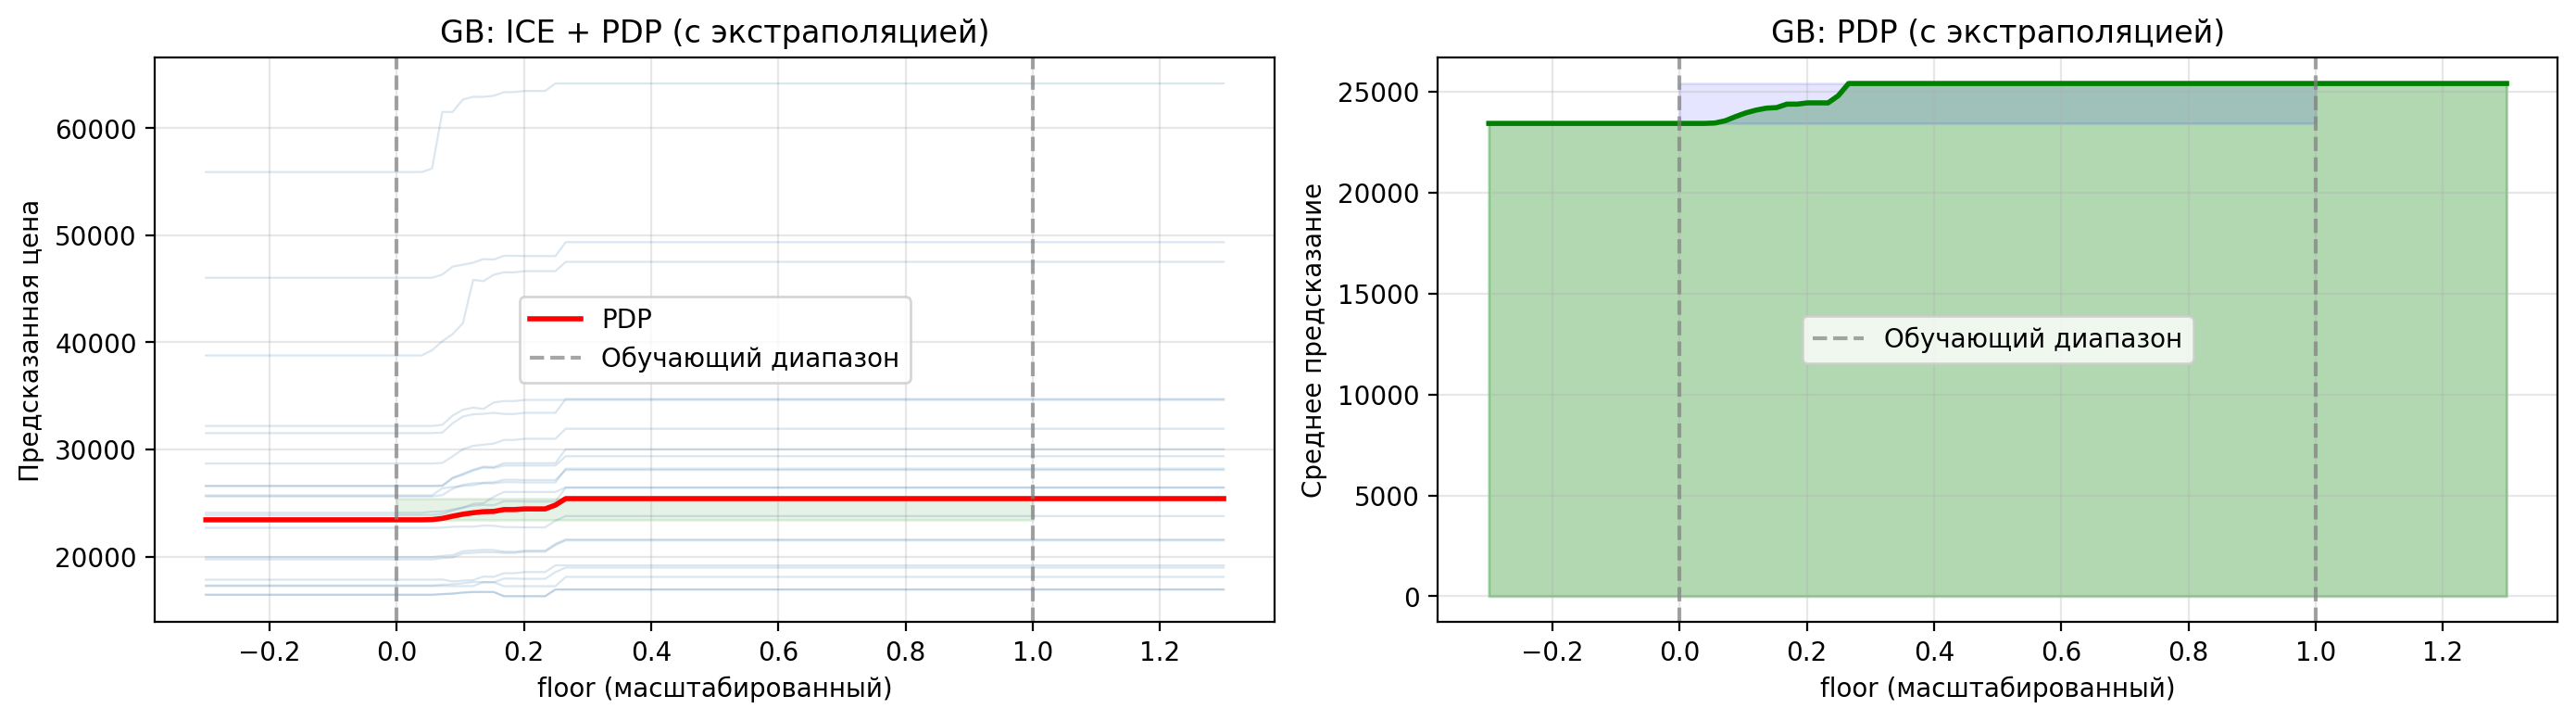


Анализ влияния выбросов для второго признака:
Добавлено 100 выбросов ниже минимума
Добавлено 100 выбросов выше максимума
Новый диапазон признака: [-0.300, 1.299]

LR R2 (без выбросов): 0.727
LR R2 (с выбросами для floor): 0.728

GB R2 (без выбросов): 0.894
GB R2 (с выбросами для floor): 0.891

PDP для моделей, обученных на данных с выбросами:

Линейная регрессия (с выбросами):


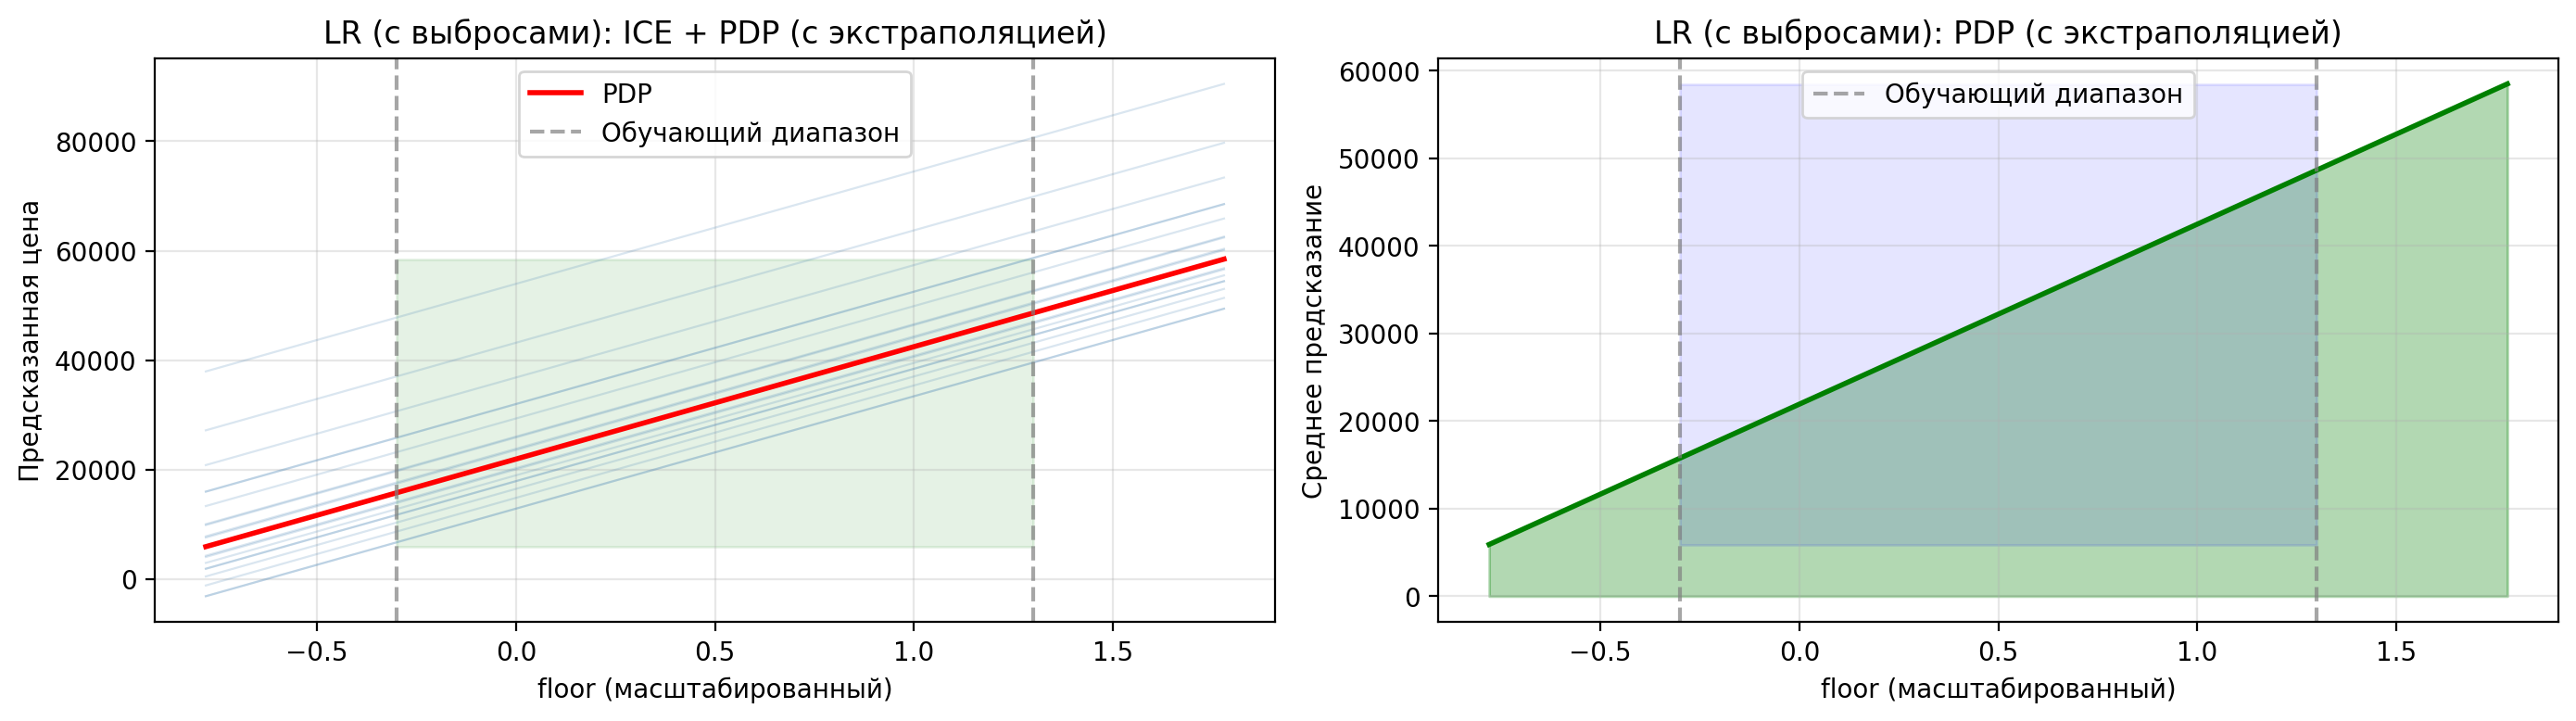


Градиентный бустинг (с выбросами):


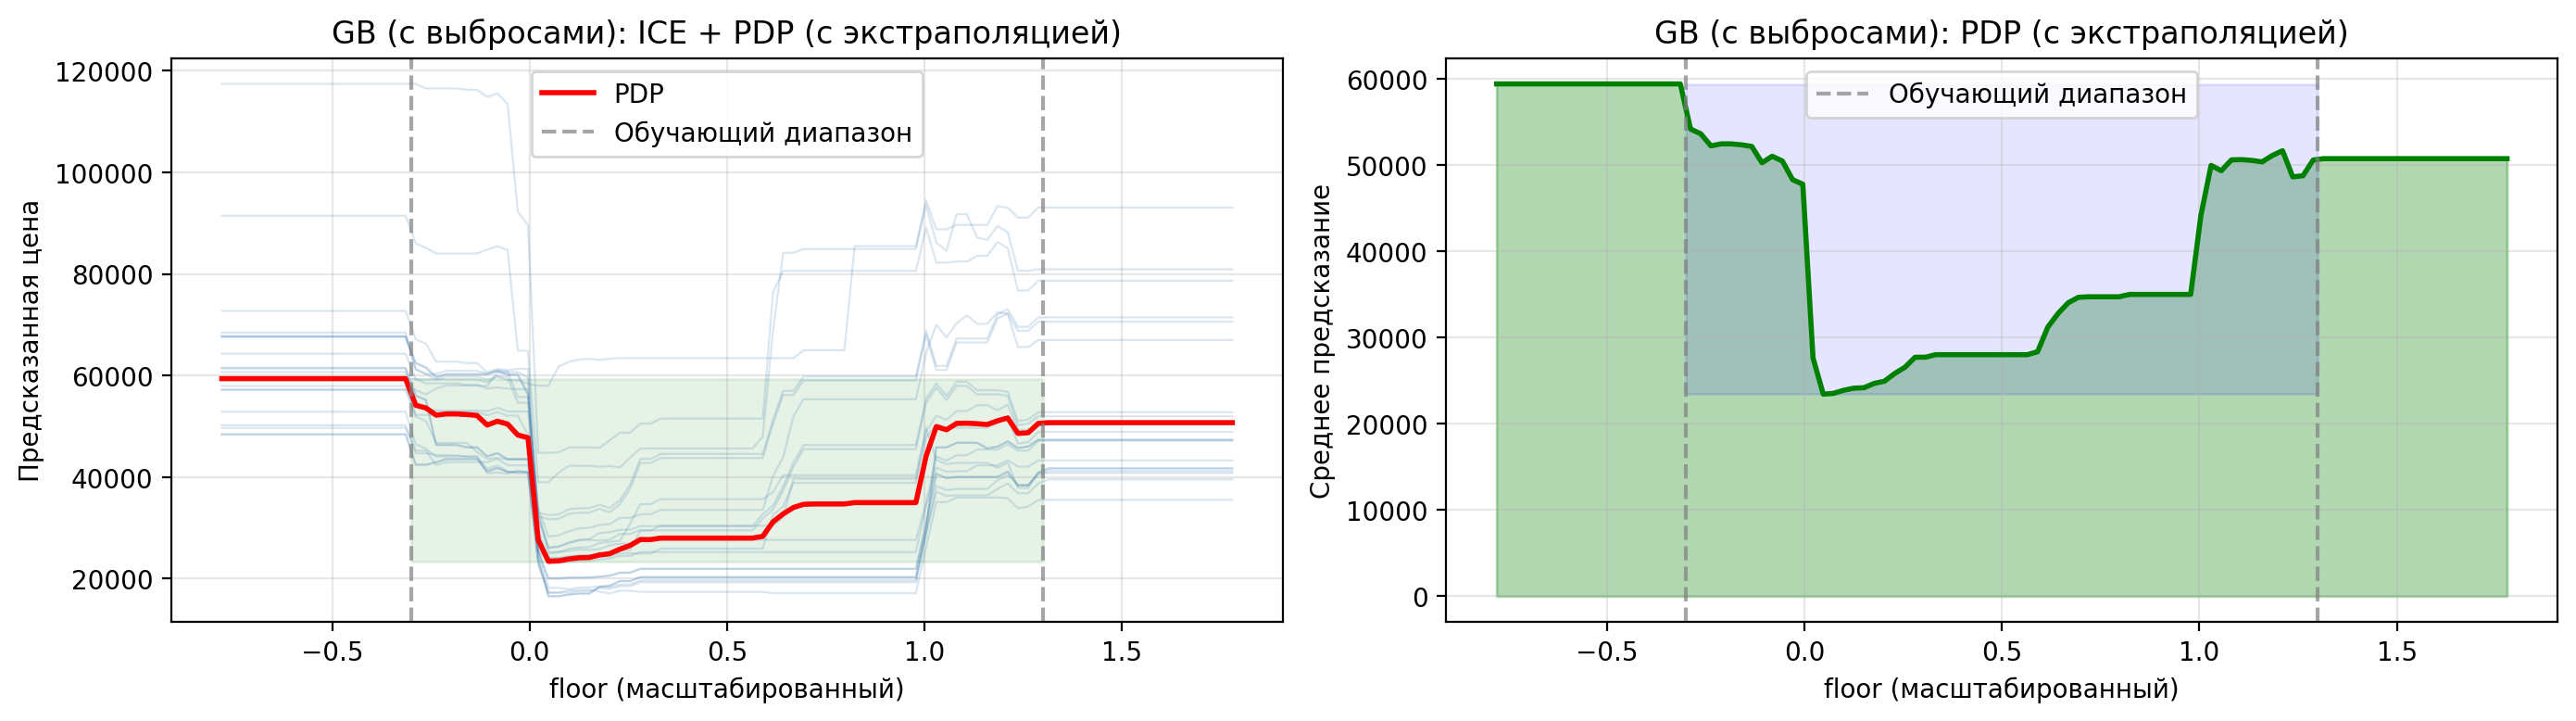


Сравнение PDP исходных моделей и моделей с выбросами:


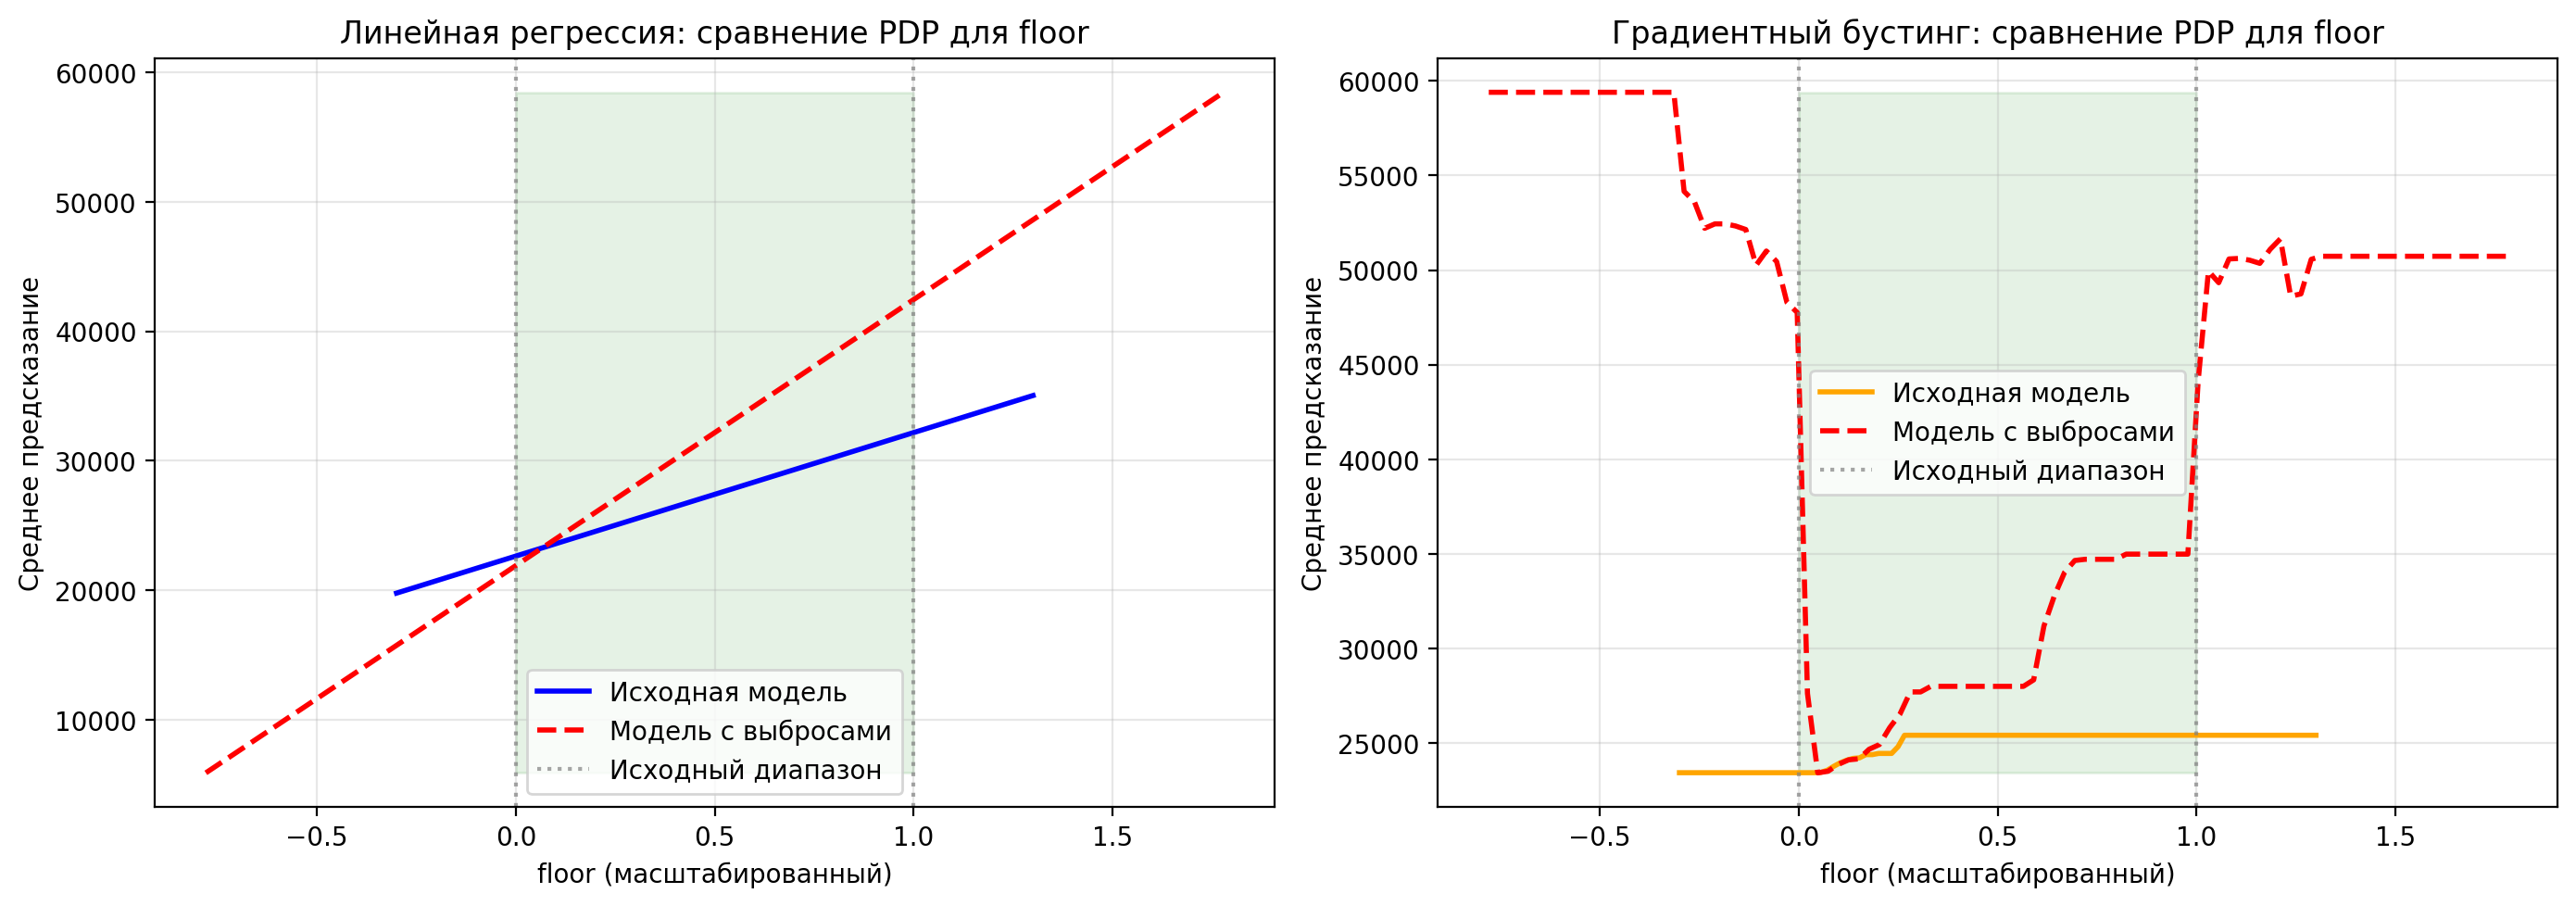


Анализ влияния выбросов для второго признака

Линейная регрессия:
  Изменение предсказаний на левой границе: 19787.07 => 5907.44 (изменение: -13879.64)
  Изменение предсказаний на правой границе: 35046.85 => 58461.83 (изменение: 23414.99)

Градиентный бустинг:
  Изменение предсказаний на левой границе: 23439.07 => 59396.87 (изменение: 35957.80)
  Изменение предсказаний на правой границе: 25418.38 => 50731.16 (изменение: 25312.78)

Коэффициенты линейной регрессии для признака floor:
  Исходная модель: 9537.3569
  Модель с выбросами: 20541.4423
  Изменение коэффициента: 11004.0854


In [25]:
# второй признак 
second_feature = 'floor'

print(f"Задание 2.1: Анализ признака '{second_feature}'")

second_idx = feature_names.index(second_feature)

scaled_min2 = X_train_minmax[:, second_idx].min()
scaled_max2 = X_train_minmax[:, second_idx].max()
orig_min2 = X_train_processed[:, second_idx].min()
orig_max2 = X_train_processed[:, second_idx].max()

print(f"Исходный диапазон: [{orig_min2:.3f}, {orig_max2:.3f}]")
print(f"Масштабированный диапазон: [{scaled_min2:.3f}, {scaled_max2:.3f}]")

# Анализ поведения за пределами диапазона
print("\nАнализ экстраполяции для исходных моделей:")
lr_vals2, lr_preds2 = test_out_of_range_scaled(lr_model, X_train_minmax, X_test_minmax, 
                                         second_idx, scaled_min2, scaled_max2,
                                         orig_min2, orig_max2)
gb_vals2, gb_preds2 = test_out_of_range_scaled(gb_model, X_train_minmax, X_test_minmax, 
                                         second_idx, scaled_min2, scaled_max2,
                                         orig_min2, orig_max2)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Линейная регрессия
axes[0].axvline(scaled_min2, color='red', linestyle='--', alpha=0.7, label='Обучающий диапазон')
axes[0].axvline(scaled_max2, color='red', linestyle='--', alpha=0.7)
axes[0].axvspan(scaled_min2, scaled_max2, alpha=0.2, color='green')
axes[0].plot(lr_vals2, lr_preds2, 'b-', linewidth=2, label='Предсказание')
axes[0].set_xlabel(f'{second_feature} (масштабированный)')
axes[0].set_ylabel('Предсказанная цена')
axes[0].set_title(f'Линейная регрессия: {second_feature}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Градиентный бустинг
axes[1].axvline(scaled_min2, color='red', linestyle='--', alpha=0.7, label='Обучающий диапазон')
axes[1].axvline(scaled_max2, color='red', linestyle='--', alpha=0.7)
axes[1].axvspan(scaled_min2, scaled_max2, alpha=0.2, color='green')
axes[1].plot(gb_vals2, gb_preds2, 'orange', linewidth=2, label='Предсказание')
axes[1].set_xlabel(f'{second_feature} (масштабированный)')
axes[1].set_ylabel('Предсказанная цена')
axes[1].set_title(f'Градиентный бустинг: {second_feature}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ICE и PDP для исходных данных
print("\nICE и PDP для исходных данных:")
print("\nЛинейная регрессия:")
grid_lr2, pdp_lr2 = plot_ice_pdp_scaled(lr_model, X_train_minmax, X_test_minmax, 
                                  second_idx, second_feature, "LR: ")

print("\nГрадиентный бустинг:")
grid_gb2, pdp_gb2 = plot_ice_pdp_scaled(gb_model, X_train_minmax, X_test_minmax, 
                                  second_idx, second_feature, "GB: ")

# Анализ влияния выбросов для второго признака
print("\nАнализ влияния выбросов для второго признака:")

X_train_with_outliers2 = X_train_minmax.copy()
y_train_with_outliers2 = y_train.copy()

n_samples = X_train_with_outliers2.shape[0]
n_outliers = min(100, n_samples // 10)

expand2 = (scaled_max2 - scaled_min2) * 0.3
low_outliers2 = np.random.uniform(scaled_min2 - expand2, scaled_min2, n_outliers)
high_outliers2 = np.random.uniform(scaled_max2, scaled_max2 + expand2, n_outliers)

outlier_indices2 = np.random.choice(n_samples, n_outliers * 2, replace=False)
X_train_with_outliers2[outlier_indices2[:n_outliers], second_idx] = low_outliers2
X_train_with_outliers2[outlier_indices2[n_outliers:], second_idx] = high_outliers2

outlier_mask2 = np.zeros(n_samples, dtype=bool)
outlier_mask2[outlier_indices2[:n_outliers]] = True
outlier_mask2[outlier_indices2[n_outliers:]] = True
y_train_with_outliers2[outlier_mask2] = y_train_with_outliers2[outlier_mask2] * np.random.uniform(1.5, 3.0, n_outliers * 2)

print(f"Добавлено {n_outliers} выбросов ниже минимума")
print(f"Добавлено {n_outliers} выбросов выше максимума")
print(f"Новый диапазон признака: [{X_train_with_outliers2[:, second_idx].min():.3f}, {X_train_with_outliers2[:, second_idx].max():.3f}]")

lr_model_outliers2 = LinearRegression()
lr_model_outliers2.fit(X_train_with_outliers2, y_train_with_outliers2)

gb_model_outliers2 = GradientBoostingRegressor(max_depth=5, random_state=42)
gb_model_outliers2.fit(X_train_with_outliers2, y_train_with_outliers2)

print(f"\nLR R2 (без выбросов): {lr_model.score(X_test_minmax, y_test):.3f}")
print(f"LR R2 (с выбросами для {second_feature}): {lr_model_outliers2.score(X_test_minmax, y_test):.3f}")
print(f"\nGB R2 (без выбросов): {gb_model.score(X_test_minmax, y_test):.3f}")
print(f"GB R2 (с выбросами для {second_feature}): {gb_model_outliers2.score(X_test_minmax, y_test):.3f}")

# PDP для моделей с выбросами
print("\nPDP для моделей, обученных на данных с выбросами:")
print("\nЛинейная регрессия (с выбросами):")
grid_lr_out2, pdp_lr_out2 = plot_ice_pdp_scaled(lr_model_outliers2, X_train_with_outliers2, X_test_minmax, 
                                                  second_idx, second_feature, "LR (с выбросами): ")

print("\nГрадиентный бустинг (с выбросами):")
grid_gb_out2, pdp_gb_out2 = plot_ice_pdp_scaled(gb_model_outliers2, X_train_with_outliers2, X_test_minmax, 
                                                  second_idx, second_feature, "GB (с выбросами): ")

# Сравнение PDP с выбросами и без
print("\nСравнение PDP исходных моделей и моделей с выбросами:")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Линейная регрессия
axes[0].plot(grid_lr2, pdp_lr2, 'b-', linewidth=2, label='Исходная модель')
axes[0].plot(grid_lr_out2, pdp_lr_out2, 'r--', linewidth=2, label='Модель с выбросами')
axes[0].axvline(scaled_min2, color='gray', linestyle=':', alpha=0.7, label='Исходный диапазон')
axes[0].axvline(scaled_max2, color='gray', linestyle=':', alpha=0.7)
axes[0].fill_between([scaled_min2, scaled_max2], 
                      min(min(pdp_lr2), min(pdp_lr_out2)), 
                      max(max(pdp_lr2), max(pdp_lr_out2)), 
                      alpha=0.1, color='green')
axes[0].set_xlabel(f'{second_feature} (масштабированный)')
axes[0].set_ylabel('Среднее предсказание')
axes[0].set_title(f'Линейная регрессия: сравнение PDP для {second_feature}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Градиентный бустинг
axes[1].plot(grid_gb2, pdp_gb2, 'orange', linewidth=2, label='Исходная модель')
axes[1].plot(grid_gb_out2, pdp_gb_out2, 'r--', linewidth=2, label='Модель с выбросами')
axes[1].axvline(scaled_min2, color='gray', linestyle=':', alpha=0.7, label='Исходный диапазон')
axes[1].axvline(scaled_max2, color='gray', linestyle=':', alpha=0.7)
axes[1].fill_between([scaled_min2, scaled_max2], 
                      min(min(pdp_gb2), min(pdp_gb_out2)), 
                      max(max(pdp_gb2), max(pdp_gb_out2)), 
                      alpha=0.1, color='green')
axes[1].set_xlabel(f'{second_feature} (масштабированный)')
axes[1].set_ylabel('Среднее предсказание')
axes[1].set_title(f'Градиентный бустинг: сравнение PDP для {second_feature}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nАнализ влияния выбросов для второго признака")
print(f"\nЛинейная регрессия:")
print(f"  Изменение предсказаний на левой границе: {pdp_lr2[0]:.2f} => {pdp_lr_out2[0]:.2f} (изменение: {pdp_lr_out2[0]-pdp_lr2[0]:.2f})")
print(f"  Изменение предсказаний на правой границе: {pdp_lr2[-1]:.2f} => {pdp_lr_out2[-1]:.2f} (изменение: {pdp_lr_out2[-1]-pdp_lr2[-1]:.2f})")

print(f"\nГрадиентный бустинг:")
print(f"  Изменение предсказаний на левой границе: {pdp_gb2[0]:.2f} => {pdp_gb_out2[0]:.2f} (изменение: {pdp_gb_out2[0]-pdp_gb2[0]:.2f})")
print(f"  Изменение предсказаний на правой границе: {pdp_gb2[-1]:.2f} => {pdp_gb_out2[-1]:.2f} (изменение: {pdp_gb_out2[-1]-pdp_gb2[-1]:.2f})")

print(f"\nКоэффициенты линейной регрессии для признака {second_feature}:")
print(f"  Исходная модель: {lr_model.coef_[second_idx]:.4f}")
print(f"  Модель с выбросами: {lr_model_outliers2.coef_[second_idx]:.4f}")
print(f"  Изменение коэффициента: {lr_model_outliers2.coef_[second_idx] - lr_model.coef_[second_idx]:.4f}")

## Задание 3. 1 балл
Выберите 20 объектов из тестовой выборки.
Для каждого объекта из выбранного набора построим траекторию изменения предсказания модели при постепенном изменении значения признака от его текущего значения к базовому значению (медиана или среднее по обучающей выборке).

**Алгоритм:**
1. Выбрать объект $x_i$ из тестовой выборки
2. Для интересующего признака $j$:
   - Текущее значение: $x_{i,j}$
   - Базовое значение: $x_{base,j}$ (медиана или среднее по обучающей выборке)
3. Построить линейную интерполяцию между $x_{i,j}$ и $x_{base,j}$ с $n$ шагами
4. Для каждого шага интерполяции:
   - Заменить значение признака $j$ в объекте $x_i$ на значение из интерполяции
   - Вычислить предсказание модели для модифицированного объекта
5. Построить график траектории


Задание 3.1 (*) 1 балл: проанализируйте также еще один признак

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

n_samples = 20
test_indices = np.random.choice(len(X_test_minmax), n_samples, replace=False)
print(f"Индексы: {test_indices[:5]}...")

# признаки для анализа
features_to_analyze = {
    'location_public_transport_platform_w_mean_distance': 'Расстояние до остановки общественного транспрорта',
    'square': 'Площадь квартиры'
}

feature_indices = {}
for feature in features_to_analyze.keys():
    if feature in feature_names:
        feature_indices[feature] = feature_names.index(feature)
    else:
        raise ValueError(f"Признак {feature} не найден в feature_names")

base_values = {}
print("\nБазовые значения признаков:")
for feature, idx in feature_indices.items():
    base_values[feature] = np.median(X_train_minmax[:, idx])
    print(f"\nПризнак: {feature}")
    print(f"  Базовое значение (медиана): {base_values[feature]:.4f}")
    print(f"  Диапазон в обучении: [{X_train_minmax[:, idx].min():.4f}, {X_train_minmax[:, idx].max():.4f}]")

Индексы: [5579 3443 2351 4456 2742]...

Базовые значения признаков:

Признак: location_public_transport_platform_w_mean_distance
  Базовое значение (медиана): 0.0606
  Диапазон в обучении: [0.0000, 1.0000]

Признак: square
  Базовое значение (медиана): 0.0830
  Диапазон в обучении: [0.0000, 1.0000]


In [27]:
def build_trajectory(model, X_sample, feature_idx, base_value, n_steps=50):
    """
    Строит траекторию изменения предсказания при изменении признака к базовому значению
    """
    current_value = X_sample[0, feature_idx]
    trajectory_values = np.linspace(current_value, base_value, n_steps)
    
    predictions = []
    X_modified = X_sample.copy()
    
    for val in trajectory_values:
        X_modified[0, feature_idx] = val
        predictions.append(model.predict(X_modified)[0])
    
    return trajectory_values, np.array(predictions)


def plot_all_trajectories(model, X_data, indices, feature_idx, feature_name, 
                          base_value, model_name, n_steps=50, ax=None):
    """
    Строит траектории для всех выбранных объектов на одной оси
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    
    colors = plt.cm.viridis(np.linspace(0, 1, len(indices)))
    
    all_start_preds = []
    all_end_preds = []
    
    for i, idx in enumerate(indices):
        X_sample = X_data[idx:idx+1].copy()
        
        trajectory, predictions = build_trajectory(
            model, X_sample, feature_idx, base_value, n_steps
        )
        
        ax.plot(trajectory, predictions, color=colors[i], alpha=0.7, linewidth=1.5)
        
        ax.scatter(trajectory[0], predictions[0], color=colors[i], s=30, 
                   edgecolor='black', zorder=5)
        ax.scatter(trajectory[-1], predictions[-1], color=colors[i], s=30, edgecolor='black', zorder=5)
        
        all_start_preds.append(predictions[0])
        all_end_preds.append(predictions[-1])
    
    ax.axvline(x=base_value, color='red', linestyle='--', linewidth=2, 
                label=f'Базовое значение = {base_value:.4f}')
    
    ax.set_xlabel(f'{feature_name} (нормализованный)')
    ax.set_ylabel('Предсказанная цена')
    ax.set_title(f'{model_name}\nТраектории для {len(indices)} объектов')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    return all_start_preds, all_end_preds

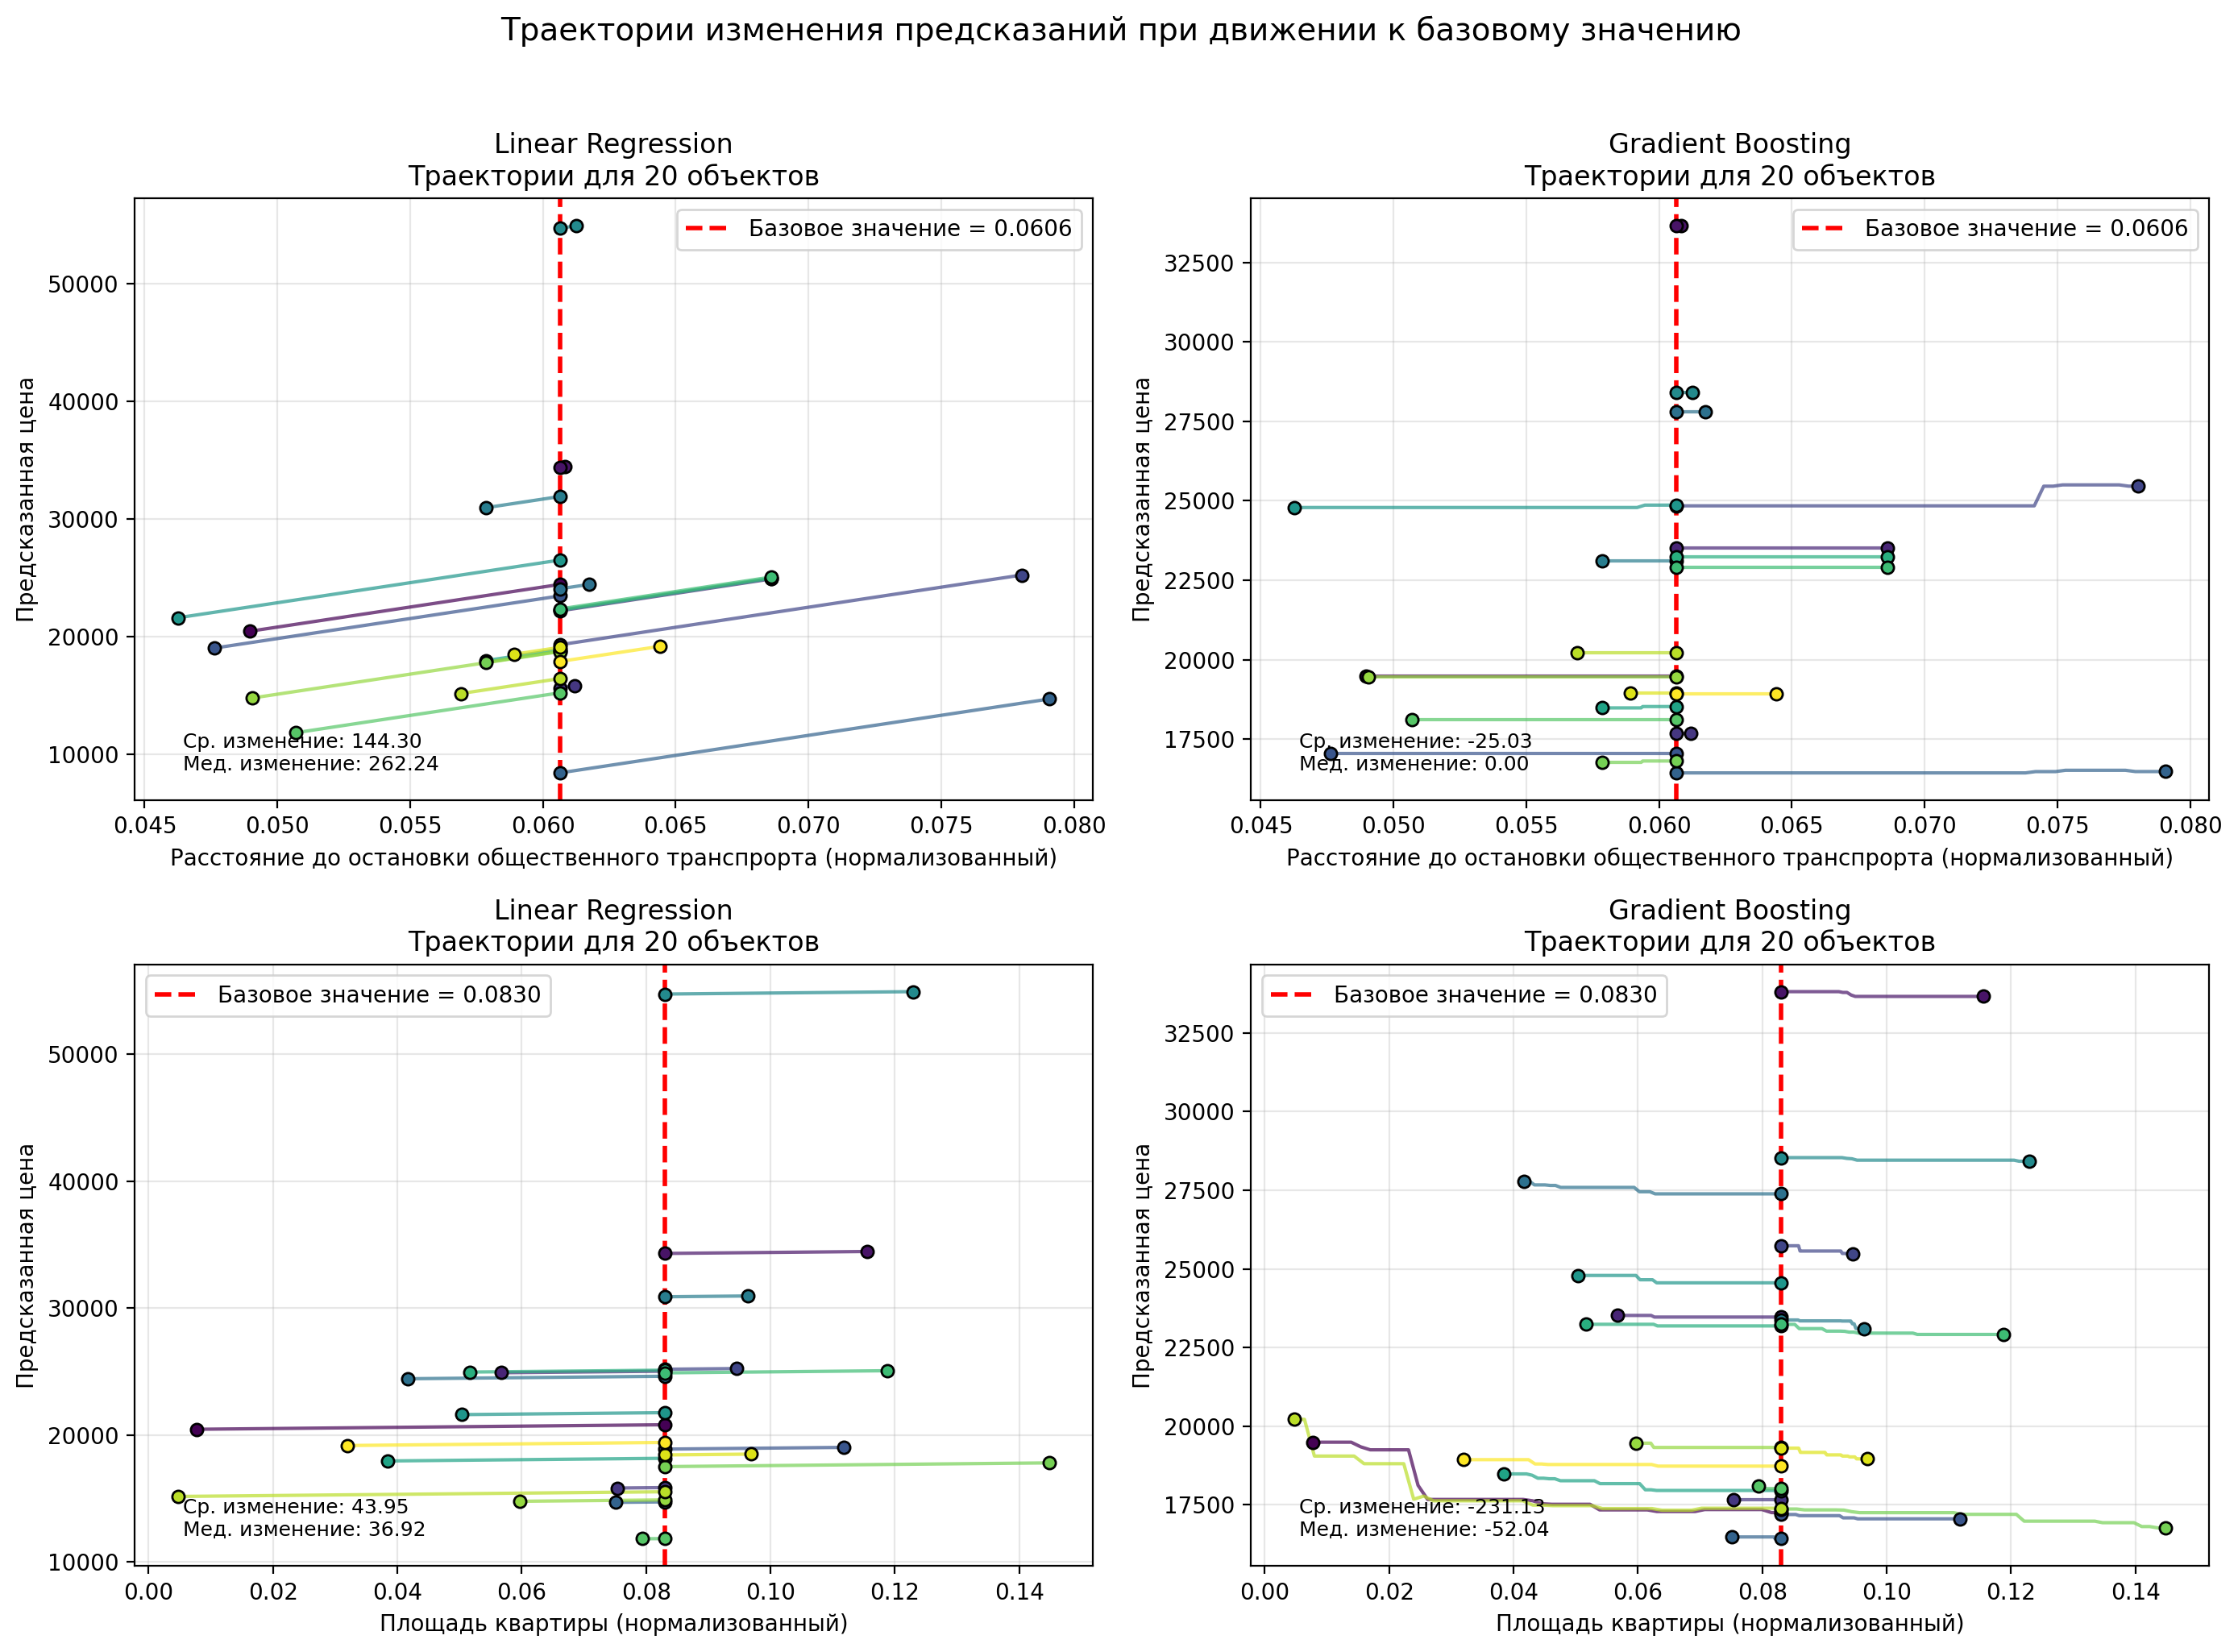

In [28]:
models = {
    'Linear Regression': lr_model,
    'Gradient Boosting': gb_model
}

fig, axes = plt.subplots(len(features_to_analyze), len(models), 
                         figsize=(14, 5 * len(features_to_analyze)))
fig.suptitle('Траектории изменения предсказаний при движении к базовому значению', 
             fontsize=14, y=1.02)

for i, (feature_name, feature_desc) in enumerate(features_to_analyze.items()):
    for j, (model_name, model) in enumerate(models.items()):
        ax = axes[i, j] if len(features_to_analyze) > 1 else axes[j]
        
        feature_idx = feature_indices[feature_name]
        base_value = base_values[feature_name]
        
        start_preds, end_preds = plot_all_trajectories(
            model, X_test_minmax, test_indices, feature_idx, 
            feature_desc, base_value, model_name, ax=ax
        )
        
        changes = np.array(end_preds) - np.array(start_preds)
        ax.text(0.05, 0.05, f'Ср. изменение: {np.mean(changes):.2f}\n'
                f'Мед. изменение: {np.median(changes):.2f}', 
                transform=ax.transAxes, fontsize=9)

plt.tight_layout()
plt.show()

Детальный анализ объекта 5579
Исходные предсказания:
  LR: 20455.66
  GB: 19490.49


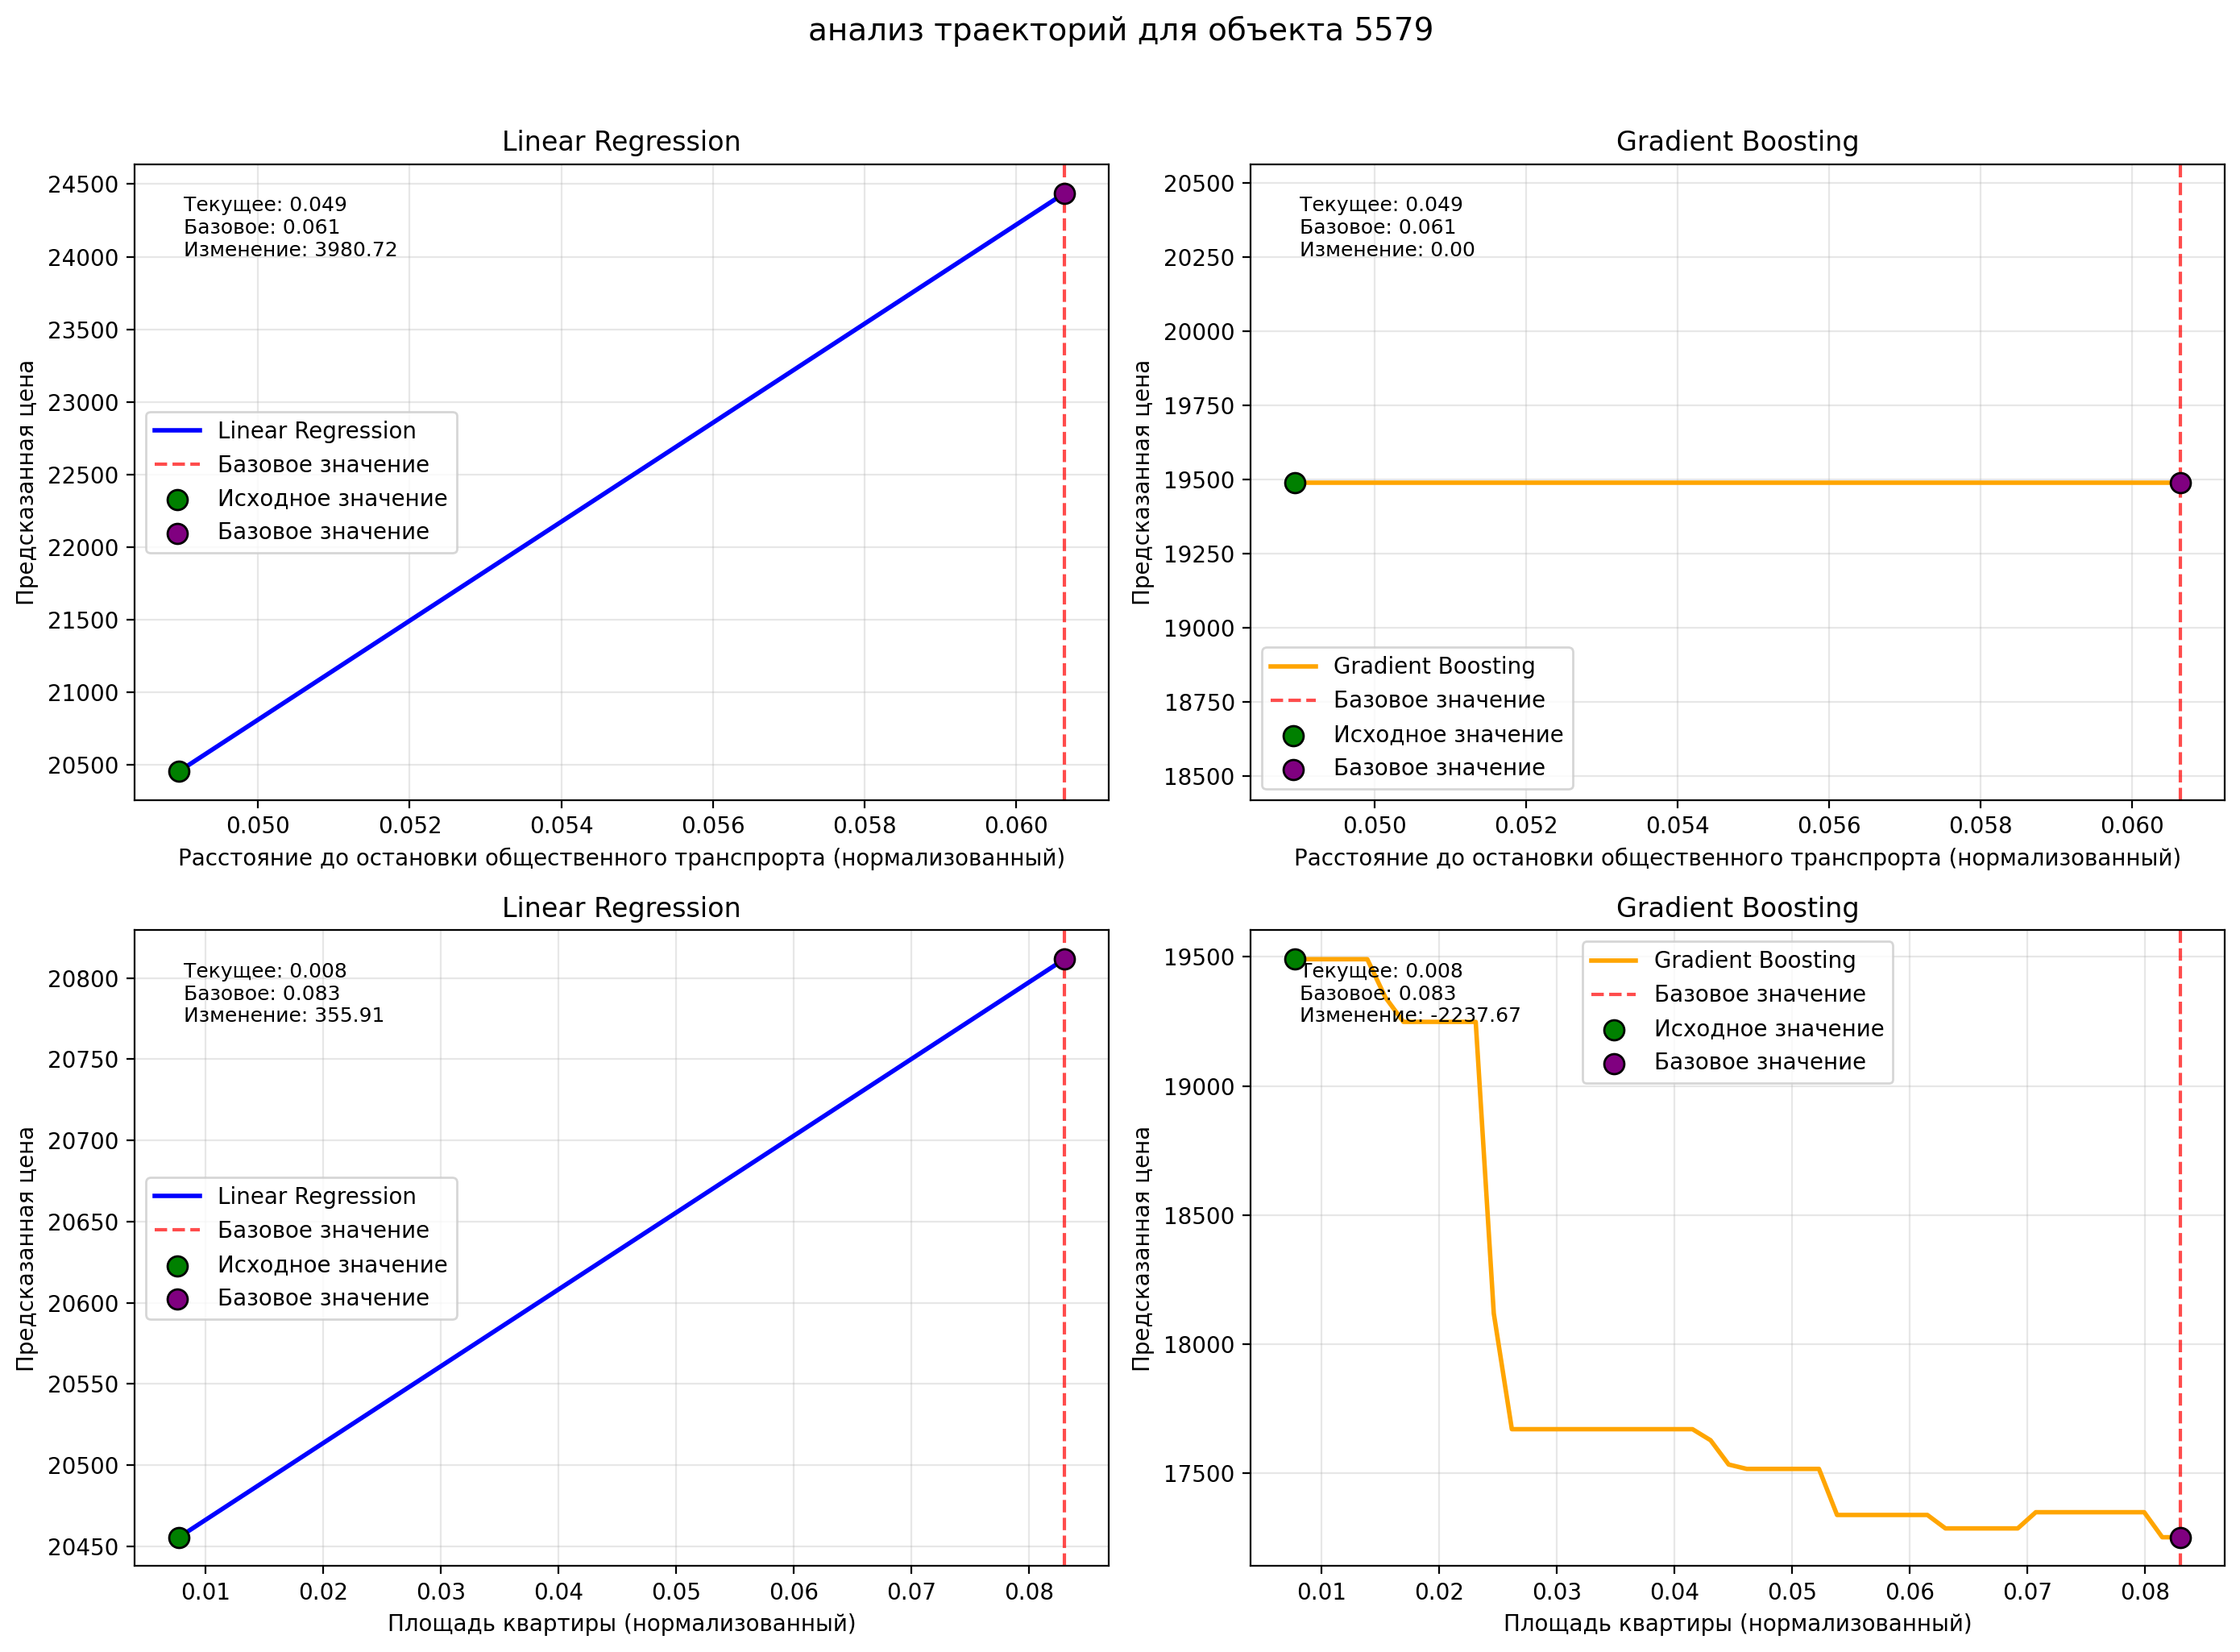

In [29]:
# один объект для детального сравнения
selected_idx = test_indices[0]
X_sample = X_test_minmax[selected_idx:selected_idx+1].copy()

print(f"Детальный анализ объекта {selected_idx}")
print(f"Исходные предсказания:")
print(f"  LR: {lr_model.predict(X_sample)[0]:.2f}")
print(f"  GB: {gb_model.predict(X_sample)[0]:.2f}")

fig, axes = plt.subplots(len(features_to_analyze), len(models), 
                         figsize=(14, 5 * len(features_to_analyze)))
fig.suptitle(f'анализ траекторий для объекта {selected_idx}', 
             fontsize=14, y=1.02)

for i, (feature_name, feature_desc) in enumerate(features_to_analyze.items()):
    for j, (model_name, model) in enumerate(models.items()):
        ax = axes[i, j] if len(features_to_analyze) > 1 else axes[j]
        
        feature_idx = feature_indices[feature_name]
        base_value = base_values[feature_name]
        
        trajectory, predictions = build_trajectory(
            model, X_sample, feature_idx, base_value, n_steps=50
        )
        
        ax.plot(trajectory, predictions, 'b-' if j == 0 else 'orange', 
                linewidth=2, label=model_name)
        ax.axvline(x=base_value, color='red', linestyle='--', alpha=0.7,
                   label='Базовое значение')
        
        ax.scatter(trajectory[0], predictions[0], color='green', s=80, 
                   label='Исходное значение', zorder=5, edgecolor='black')
        ax.scatter(trajectory[-1], predictions[-1], color='purple', s=80, 
                   label='Базовое значение', zorder=5, edgecolor='black')
        
        ax.set_xlabel(f'{feature_desc} (нормализованный)')
        ax.set_ylabel('Предсказанная цена')
        ax.set_title(f'{model_name}')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        current_val = X_sample[0, feature_idx]
        ax.text(0.05, 0.95, f'Текущее: {current_val:.3f}\n'
                f'Базовое: {base_value:.3f}\n'
                f'Изменение: {predictions[-1] - predictions[0]:.2f}', 
                transform=ax.transAxes, fontsize=9,
                verticalalignment='top')

plt.tight_layout()
plt.show()

## Задание 4 (1 балл). ALE
Постройте ALE по обеим моделям, используя pyALE. Подберите размер сетки так, чтобы получить доверительные интервалы. Проанализируйте полученный график. Каковы получились доверительные интервалы? Почему они различны для моделей?

P.s. Сетку значений стройте для исходного признака.

In [30]:
from PyALE import ale

X_train_original = pd.DataFrame(X_train_processed, columns=feature_names)
X_test_original = pd.DataFrame(X_test_processed, columns=feature_names)

print(f"Размер данных: train {X_train_original.shape}, test {X_test_original.shape}")

models_original = {
    'Linear Regression': LinearRegression(),
    'Gradient Boosting': GradientBoostingRegressor(max_depth=5, random_state=42)
}

for name, model in models_original.items():
    model.fit(X_train_original, y_train)
    y_pred = model.predict(X_test_original)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    print(f"{name}: RMSE = {rmse:.4f}")

Размер данных: train (23656, 79), test (5914, 79)
Linear Regression: RMSE = 4909.5262
Gradient Boosting: RMSE = 3076.7607


In [31]:
def compute_ale(model, X, feature, grid_size=30):
    try:
        result = ale(
            X=X,
            model=model,
            feature=[feature],
            grid_size=grid_size,
            include_CI=True,
            C=0.95
        )
        return result
    except Exception as e:
        print(f"Ошибка при вычислении ALE для {feature}: {e}")
        return None

PyALE._ALE_generic:INFO: Continuous feature detected.
PyALE._ALE_generic:INFO: Continuous feature detected.
PyALE._ALE_generic:INFO: Continuous feature detected.
PyALE._ALE_generic:INFO: Continuous feature detected.


Подбор оптимального grid_size


Площадь квартиры:


PyALE._ALE_generic:INFO: Continuous feature detected.
PyALE._ALE_generic:INFO: Continuous feature detected.


  Linear Regression: grid_size = 25


PyALE._ALE_generic:INFO: Continuous feature detected.
PyALE._ALE_generic:INFO: Continuous feature detected.
PyALE._ALE_generic:INFO: Continuous feature detected.
PyALE._ALE_generic:INFO: Continuous feature detected.
PyALE._ALE_generic:INFO: Continuous feature detected.
PyALE._ALE_generic:INFO: Continuous feature detected.


...

    Объектов в бинах: min=0.0, max=956.0, mean=909.8
  Gradient Boosting (grid_size = 25)...


PyALE._ALE_generic:INFO: Continuous feature detected.


    Объектов в бинах: min=0.0, max=956.0, mean=909.8

Расстояние до ресторанов:
  Linear Regression (grid_size = 25)...


PyALE._ALE_generic:INFO: Continuous feature detected.


    Объектов в бинах: min=0.0, max=1338.0, mean=909.8
  Gradient Boosting (grid_size = 25)...
    Объектов в бинах: min=0.0, max=1338.0, mean=909.8


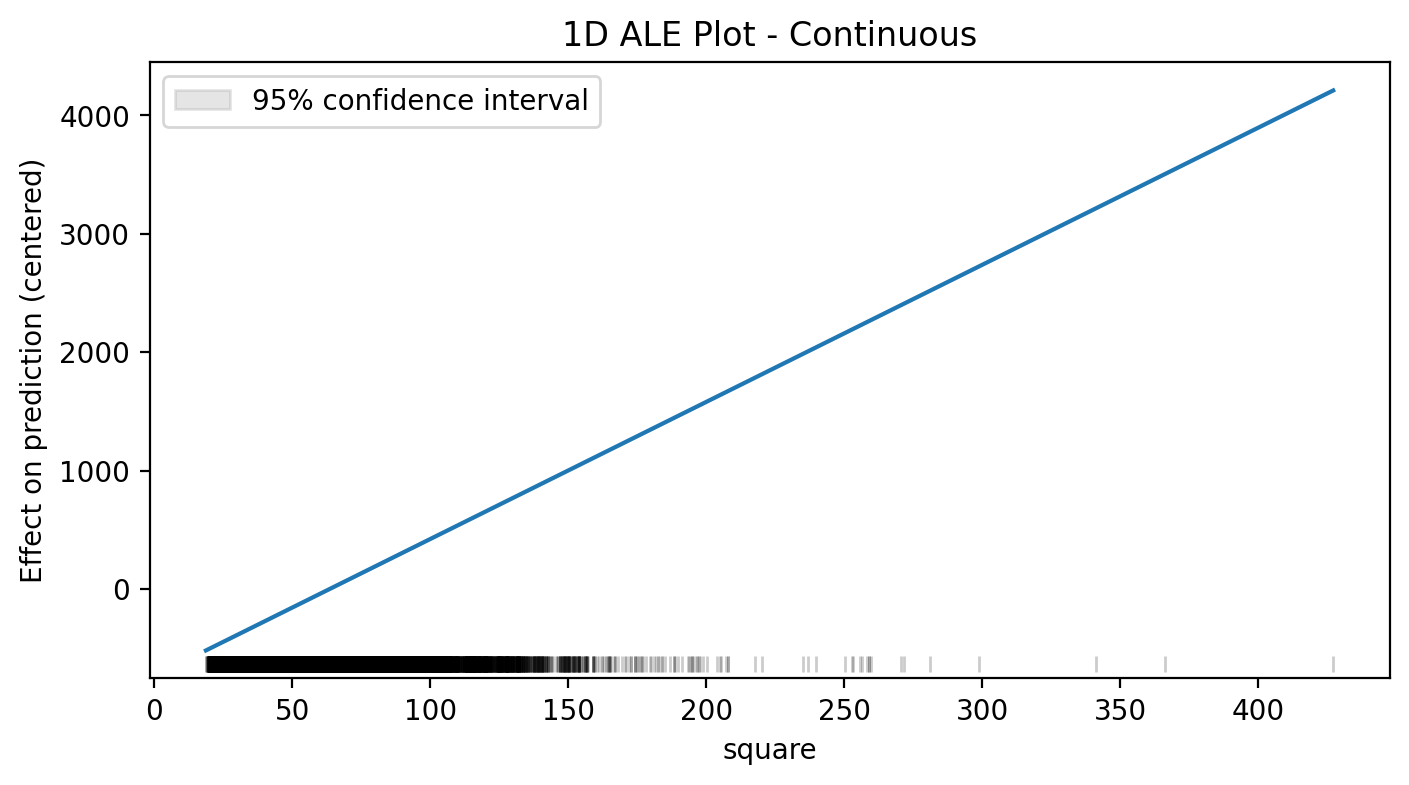

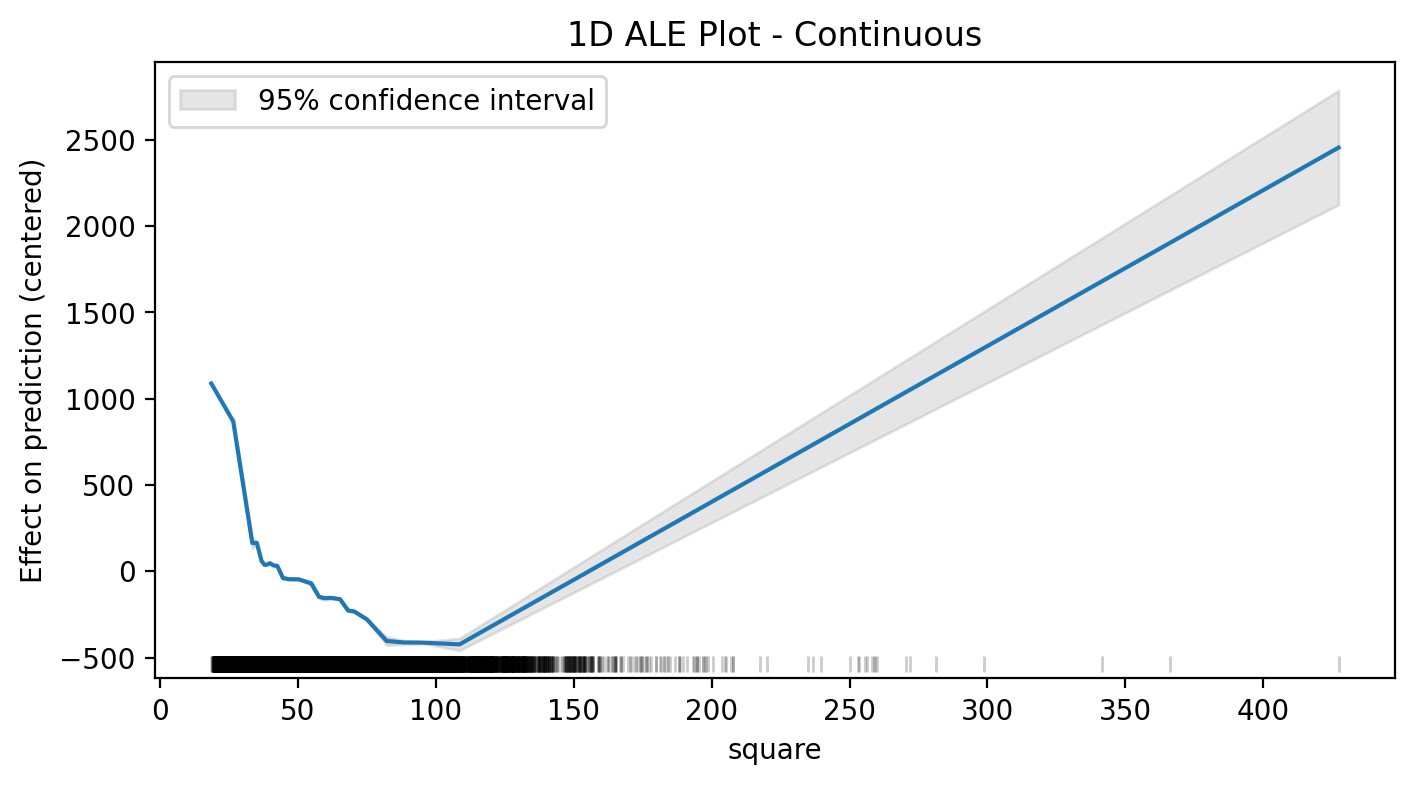

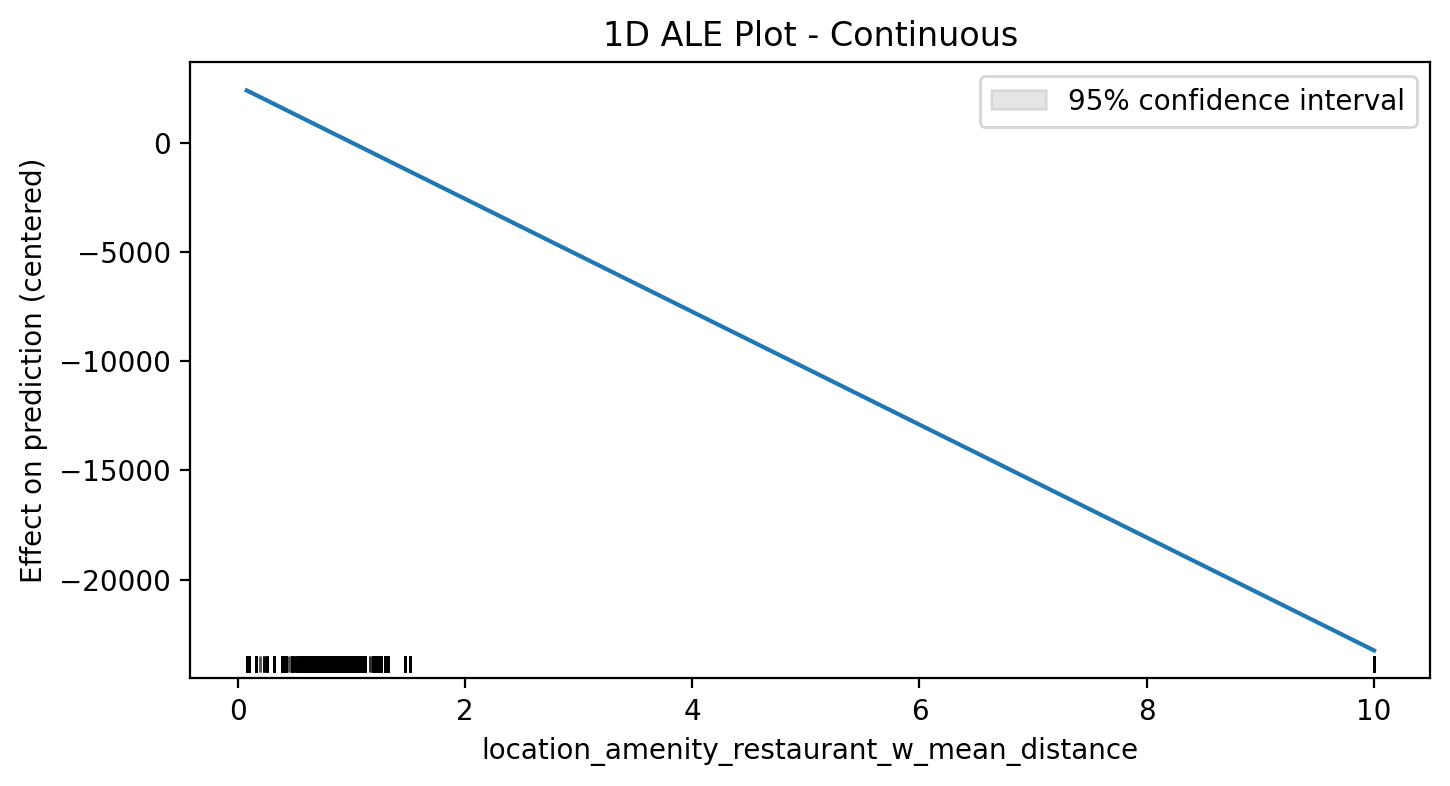

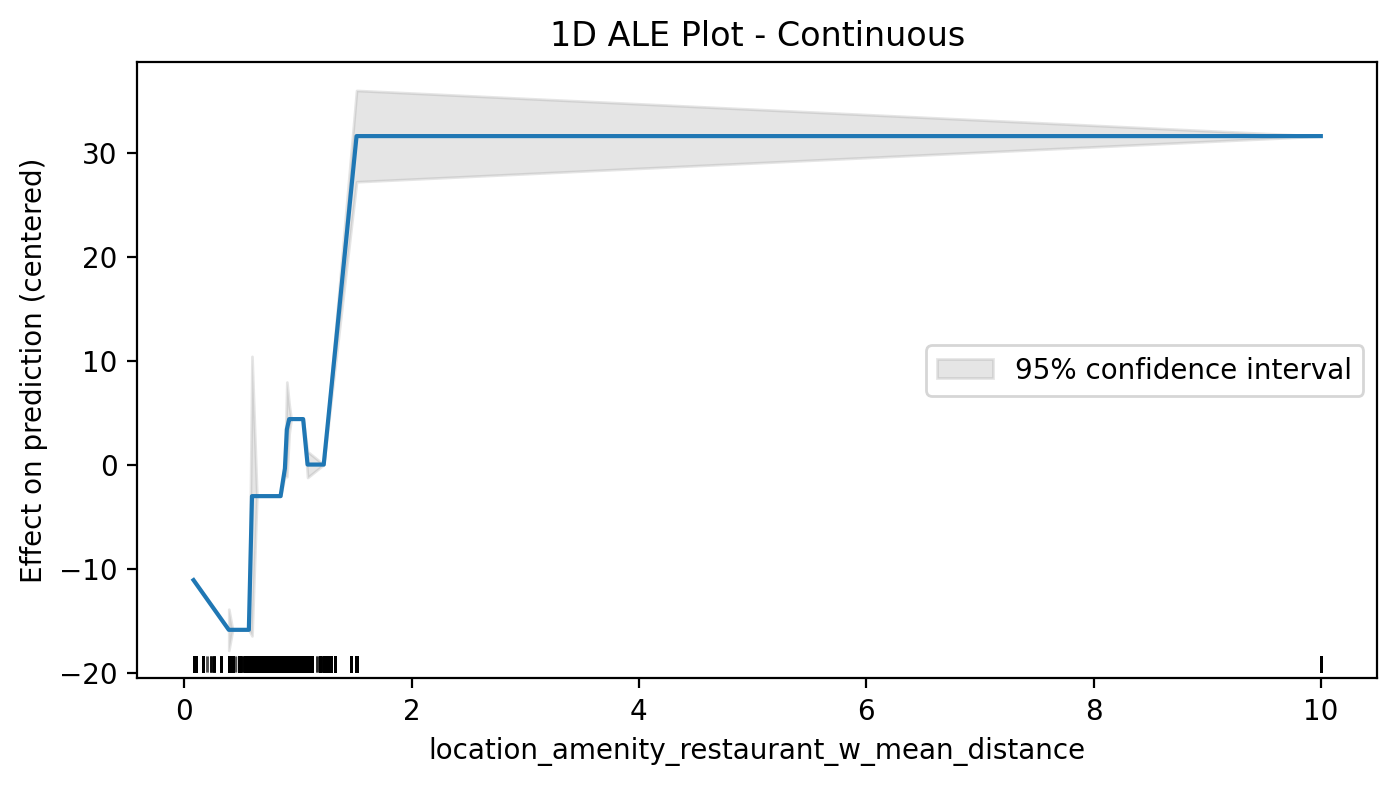

In [32]:
features_to_analyze = {
    'square': 'Площадь квартиры',
    'location_amenity_restaurant_w_mean_distance': 'Расстояние до ресторанов'
}

def find_optimal_grid_size(model, X, feature, grid_sizes=[20, 25, 30, 35]):
    """Подбирает оптимальный grid_size, максимизирующий минимальное количество объектов в бине"""
    best_size = 25
    best_min_objects = 0
    
    for size in grid_sizes:
        try:
            result = ale(
                X=X,
                model=model,
                feature=[feature],
                grid_size=size,
                include_CI=True,
                C=0.95,
                plot=False
            )
            min_objects = result['size'].min()
            if min_objects > best_min_objects:
                best_min_objects = min_objects
                best_size = size
        except:
            continue
    
    return best_size

optimal_grid = {}

print("Подбор оптимального grid_size\n")

for feature_name, feature_desc in features_to_analyze.items():
    print(f"\n{feature_desc}:")
    
    for model_name, model in models_original.items():
        best_size = find_optimal_grid_size(model, X_train_original, feature_name)
        optimal_grid[(model_name, feature_name)] = best_size
        print(f"  {model_name}: grid_size = {best_size}")

print("Вычисление ALE с оптимальным grid_size")

ale_results = {}

for feature_name, feature_desc in features_to_analyze.items():
    print(f"\n{feature_desc}:")
    
    for model_name, model in models_original.items():
        grid_size = optimal_grid[(model_name, feature_name)]
        print(f"  {model_name} (grid_size = {grid_size})...")
        
        result = compute_ale(model, X_train_original, feature_name, 
                            grid_size=grid_size)
        
        if result is not None:
            ale_results[(model_name, feature_name)] = result
            sizes = result['size'].values
            print(f"    Объектов в бинах: min={sizes.min()}, max={sizes.max()}, mean={sizes.mean():.1f}")
        else:
            print(f"    Ошибка при вычислении")

In [33]:
print("Анализ доверительных интервалов ALE")

colors = {
    'Linear Regression': 'blue',
    'Gradient Boosting': 'green'
}

for feature_name, feature_desc in features_to_analyze.items():
    print(f"Признак: {feature_desc}")
    
    for model_name in colors.keys():
        result = ale_results.get((model_name, feature_name))
        
        if result is None:
            print(f"\n{model_name}: данные недоступны")
            continue
        
        values = result['eff'].values
        bins = result.index.values
        ci_lower = result['lowerCI_95%'].values
        ci_upper = result['upperCI_95%'].values
        sizes = result['size'].values
        
        print(f"\n{model_name}:")
        print(f"  Диапазон признака: [{bins.min():.2f}, {bins.max():.2f}]")
        print(f"  Диапазон ALE: [{values.min():.2f}, {values.max():.2f}]")
        print(f"  Средний ALE: {values.mean():.4f}")
        
        # Анализ CI
        valid_ci = ~(np.isnan(ci_lower) | np.isnan(ci_upper))
        
        if np.sum(valid_ci) > 0:
            ci_width = ci_upper[valid_ci] - ci_lower[valid_ci]
            mean_width = np.mean(ci_width)
            std_width = np.std(ci_width)
            min_width = np.min(ci_width)
            max_width = np.max(ci_width)
            
            print(f"\n  Доверительные (95%):")
            print(f"    Средняя ширина: {mean_width:.4f} ± {std_width:.4f}")
            print(f"    Минимальная ширина: {min_width:.4f}")
            print(f"    Максимальная ширина: {max_width:.4f}")
            
            # Ширина на краях
            n_bins = len(bins[valid_ci])
            if n_bins >= 10:
                left_third = ci_width[:n_bins//3]
                right_third = ci_width[-n_bins//3:]
                print(f"    Ширина на левом краю: {np.mean(left_third):.4f}")
                print(f"    Ширина на правом краю: {np.mean(right_third):.4f}")
            
            # Относительная неопределенность
            mean_abs_effect = np.mean(np.abs(values[valid_ci]))
            if mean_abs_effect > 0:
                rel_uncertainty = mean_width / mean_abs_effect
                print(f"    Относительная неопределенность: {rel_uncertainty:.4f}")
        else:
            print(f"\n  Доверительные:")
            print(f"    Не рассчитаны")

Анализ доверительных интервалов ALE
Признак: Площадь квартиры

Linear Regression:
  Диапазон признака: [18.72, 427.23]
  Диапазон ALE: [-518.06, 4210.16]
  Средний ALE: 70.9707

  Доверительные (95%):
    Средняя ширина: 0.0000 ± 0.0000
    Минимальная ширина: 0.0000
    Максимальная ширина: 0.0000
    Ширина на левом краю: 0.0000
    Ширина на правом краю: 0.0000
    Относительная неопределенность: 0.0000

Gradient Boosting:
  Диапазон признака: [18.72, 427.23]
  Диапазон ALE: [-423.85, 2455.10]
  Средний ALE: 68.0267

  Доверительные (95%):
    Средняя ширина: 44.2057 ± 127.5070
    Минимальная ширина: 2.0494
    Максимальная ширина: 662.3274
    Ширина на левом краю: 18.3595
    Ширина на правом краю: 94.2934
    Относительная неопределенность: 0.1553
Признак: Расстояние до ресторанов

Linear Regression:
  Диапазон признака: [0.08, 10.00]
  Диапазон ALE: [-23245.38, 2382.32]
  Средний ALE: -469.6165

  Доверительные (95%):
    Средняя ширина: 0.0000 ± 0.0000
    Минимальная ширина: 

## Задание 5:  Permutation Importance (2 балла)
Постройте Permutation importances по обеим моделям, используя sklearn.

Поэкспериментируйте с числом перестановок.

Проанализируйте полученные коэффициенты. Как они меняются от количества перестановок? Как меняются std коэффициентов?



In [34]:
lr_original = LinearRegression()
lr_original.fit(X_train_minmax, y_train)
y_pred_lr = lr_original.predict(X_test_minmax)
print(f"Linear Regression RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lr)):.4f}")
print(f"Linear Regression R2: {r2_score(y_test, y_pred_lr):.4f}")

gb_original = GradientBoostingRegressor(max_depth=5, random_state=42)
gb_original.fit(X_train_minmax, y_train)
y_pred_gb = gb_original.predict(X_test_minmax)
print(f"Gradient Boosting RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_gb)):.4f}")
print(f"Gradient Boosting R2: {r2_score(y_test, y_pred_gb):.4f}")

feature_names = X_train.select_dtypes(include=[np.number]).columns.tolist() + \
                X_train.select_dtypes(include=['object']).columns.tolist()
print(f"\nКоличество признаков: {len(feature_names)}")

Linear Regression RMSE: 4909.5262
Linear Regression R2: 0.7273
Gradient Boosting RMSE: 3067.2707
Gradient Boosting R2: 0.8936

Количество признаков: 79


In [35]:
print("Permutation Importance")

n_repeats_list = [5, 10, 20, 30]

lr_perm_results = {}
gb_perm_results = {}

for model, name, results_dict in [(lr_original, "Linear Regression", lr_perm_results), 
                                   (gb_original, "Gradient Boosting", gb_perm_results)]:
    print(f"\n{name}:")
    print("-"*40)
    
    for n in n_repeats_list:
        perm_imp = permutation_importance(
            model, X_test_minmax, y_test,
            n_repeats=n, 
            random_state=42, 
            n_jobs=-1,
            scoring='r2'
        )
        
        results_dict[n] = {
            'importances': perm_imp.importances_mean,
            'std': perm_imp.importances_std
        }
        
        sorted_idx = np.argsort(perm_imp.importances_mean)[::-1][:5]
        print(f"\nn_repeats={n}:")
        for i, idx in enumerate(sorted_idx, 1):
            print(f"  {i}. {feature_names[idx][:40]:40s} "
                  f"{perm_imp.importances_mean[idx]:.6f} (±{perm_imp.importances_std[idx]:.6f})")

Permutation Importance

Linear Regression:
----------------------------------------



n_repeats=5:
  1. location_public_transport_platform_w_mea 32.937368 (±0.223960)
  2. location_highway_crossing_w_mean_distanc 28.737957 (±0.119096)
  3. location_amenity_restaurant_w_mean_dista 0.673676 (±0.008432)
  4. location_buildings_cnt                   0.522610 (±0.005032)
  5. class_cat                                0.432200 (±0.006574)

n_repeats=10:
  1. location_public_transport_platform_w_mea 32.626049 (±0.393203)
  2. location_highway_crossing_w_mean_distanc 28.454520 (±0.347408)
  3. location_amenity_restaurant_w_mean_dista 0.673622 (±0.010167)
  4. location_buildings_cnt                   0.522701 (±0.008073)
  5. location_leisure_cnt                     0.430200 (±0.008161)

n_repeats=20:
  1. location_public_transport_platform_w_mea 32.540871 (±0.460082)
  2. location_highway_crossing_w_mean_distanc 28.364379 (±0.410764)
  3. location_amenity_restaurant_w_mean_dista 0.670370 (±0.012643)
  4. location_buildings_cnt                   0.519017 (±0.008148)
  5. locatio

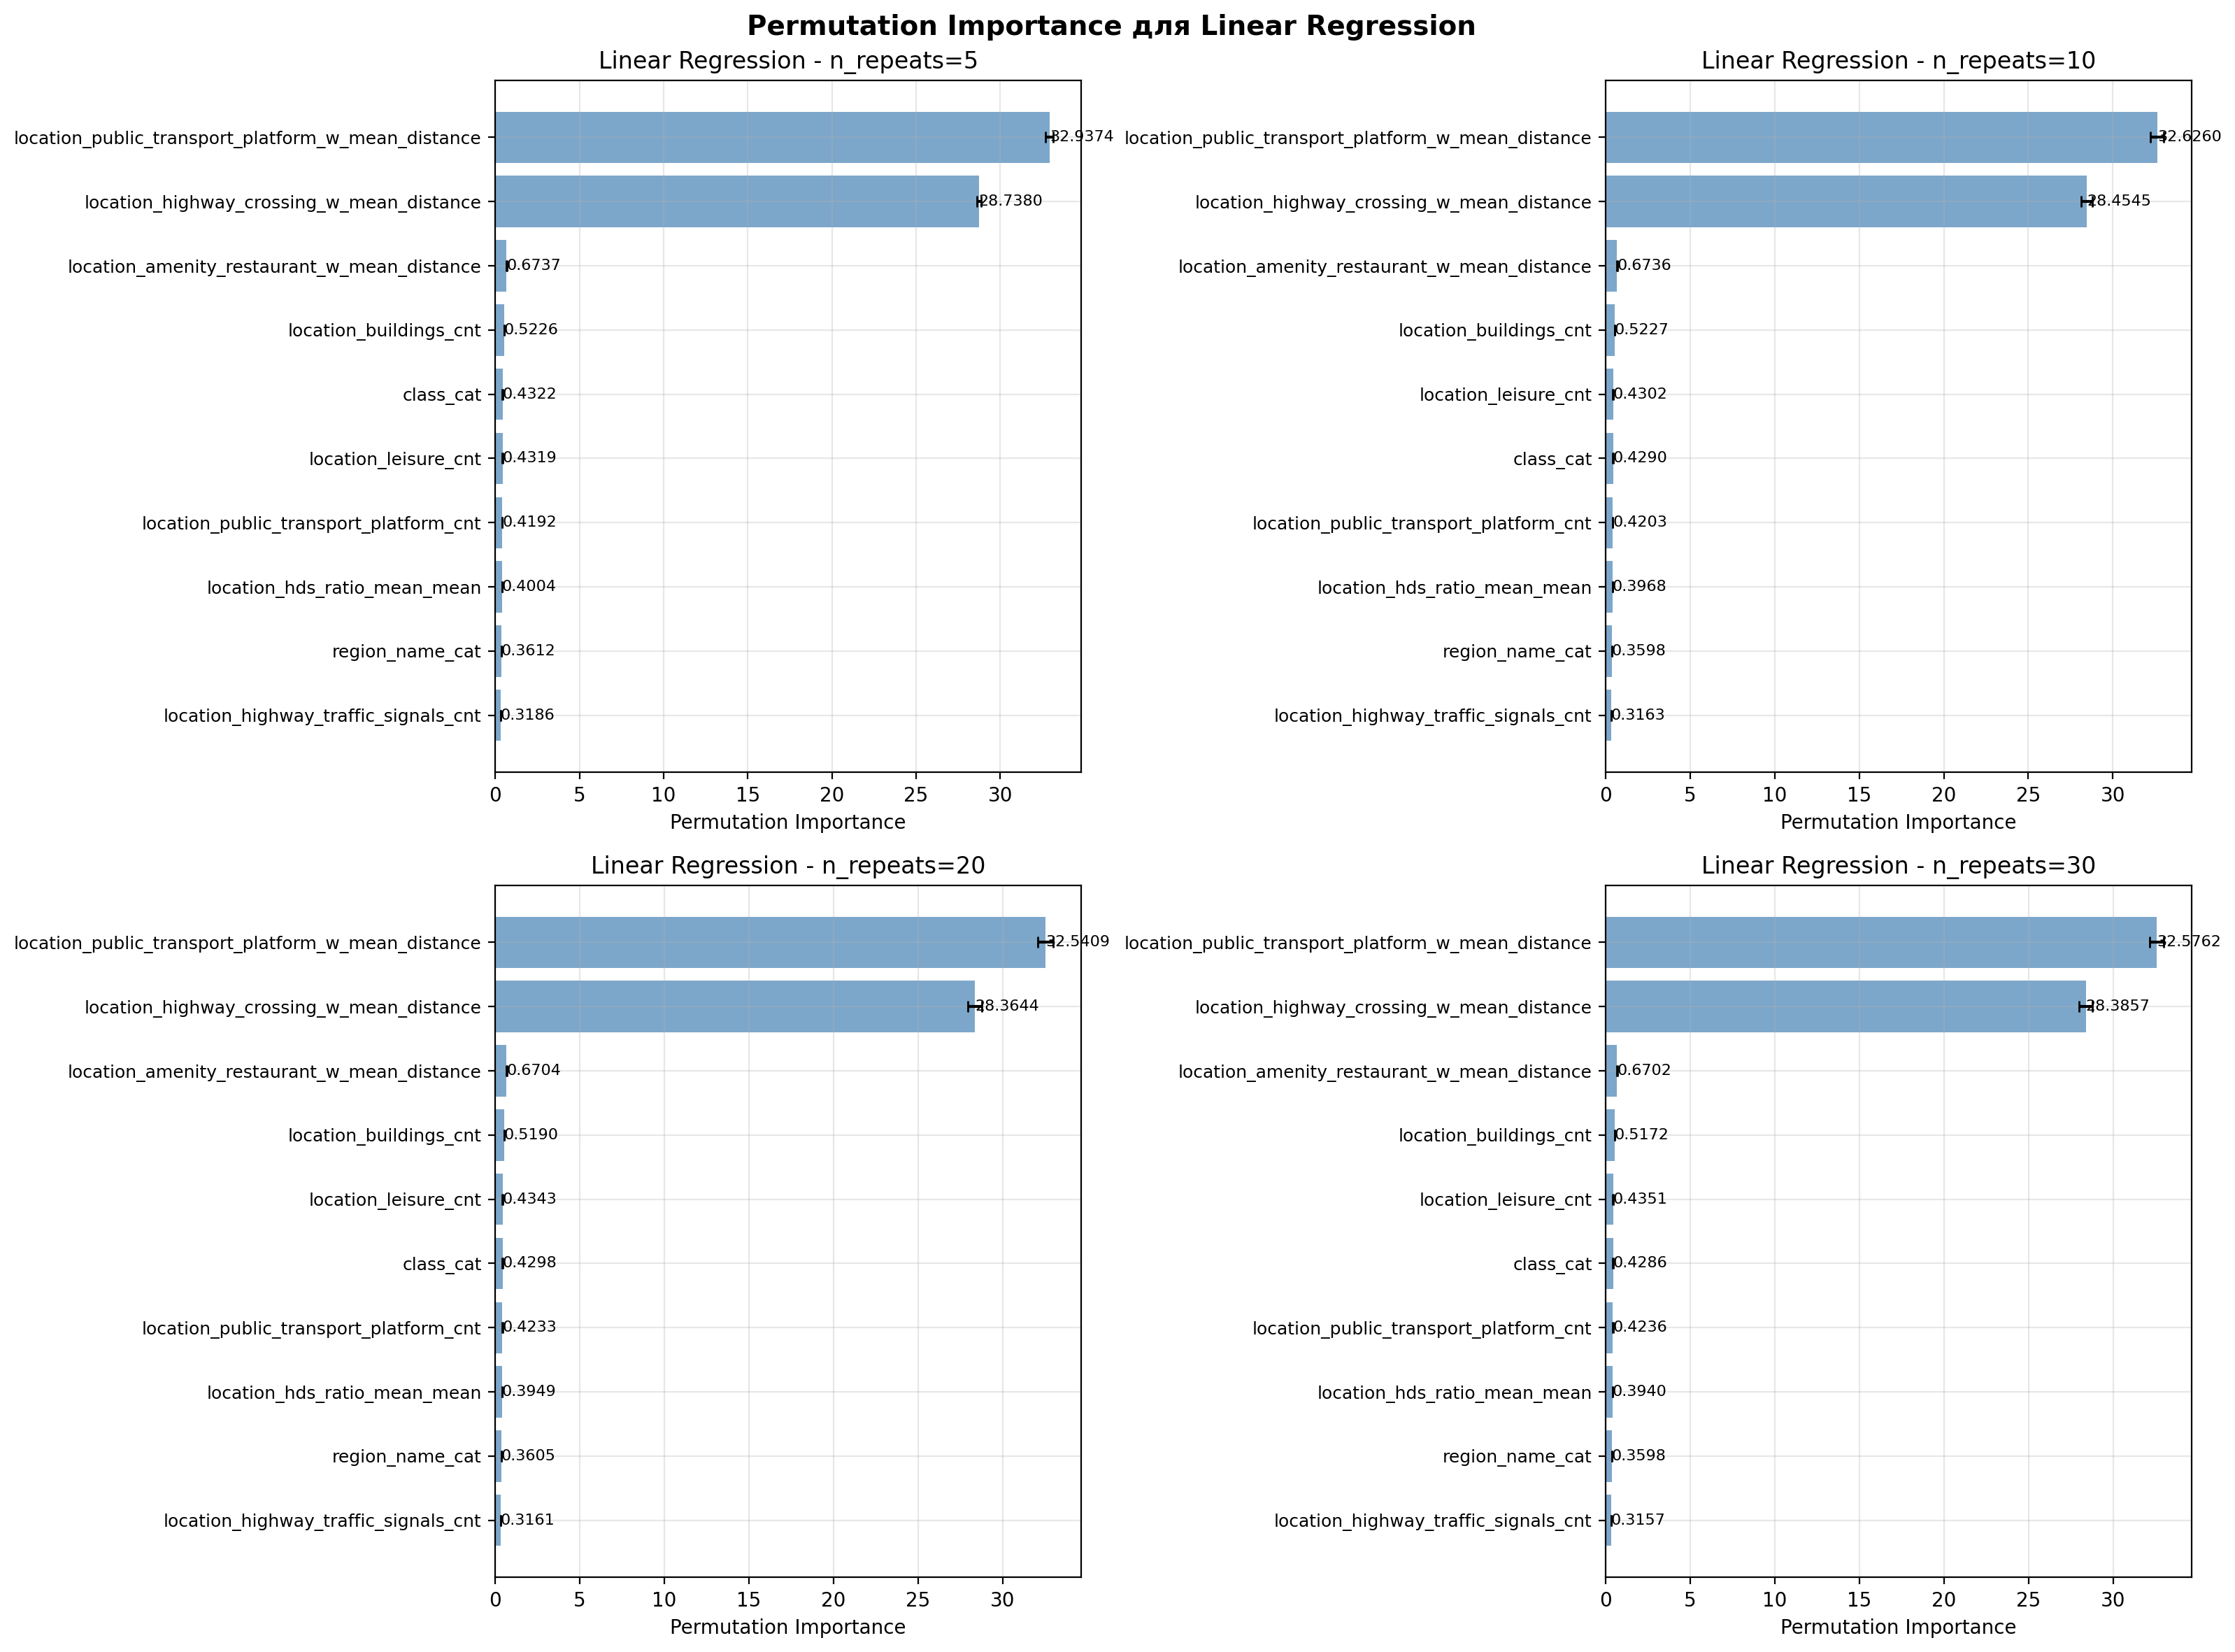

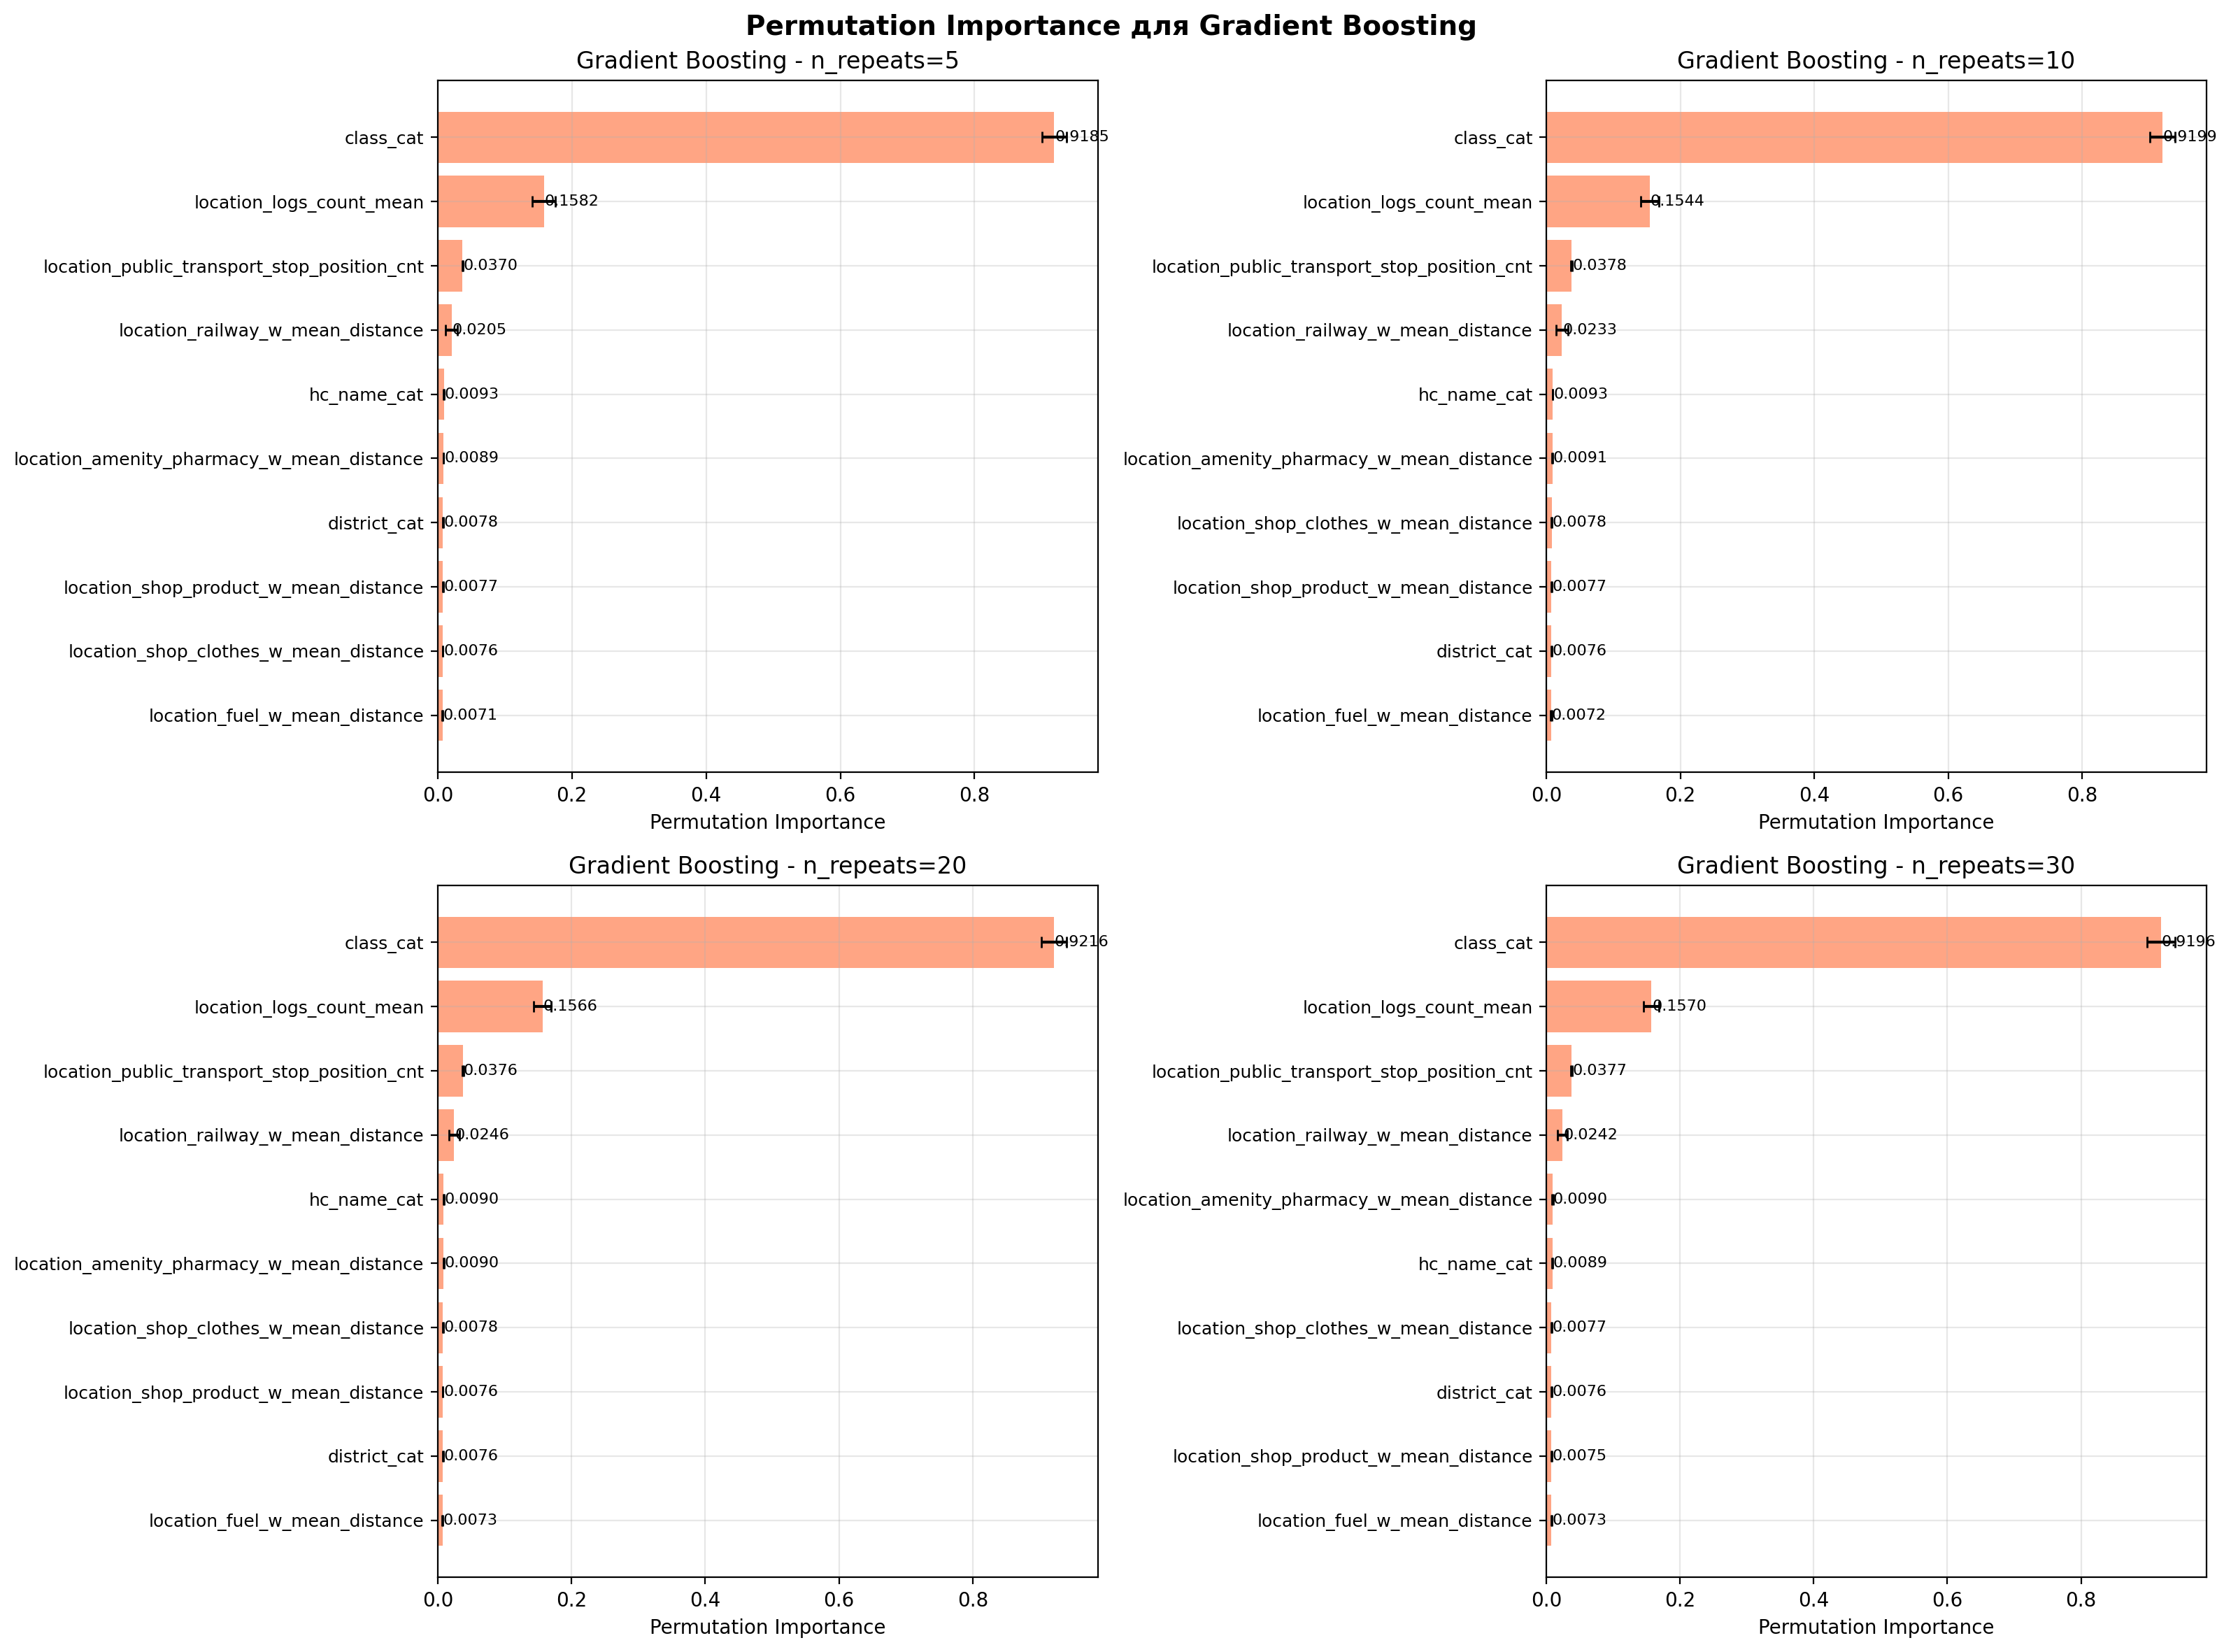

In [36]:
def plot_permutation_importance_fixed(results, feature_names, model_name, 
                                      n_repeats_list=[5, 10, 20, 30], top_n=10):
    """
    Визуализация permutation importance
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()
    
    for i, n in enumerate(n_repeats_list):
        importances = results[n]['importances']
        std = results[n]['std']
        
        # топ-N признаков
        sorted_idx = np.argsort(importances)[::-1][:top_n]
        sorted_importances = importances[sorted_idx]
        sorted_std = std[sorted_idx]
        sorted_features = [feature_names[idx] for idx in sorted_idx]
        
        y_pos = np.arange(len(sorted_importances))
        axes[i].barh(y_pos, sorted_importances, xerr=sorted_std, 
                     capsize=3, alpha=0.7, 
                     color='steelblue' if 'Linear' in model_name else 'coral')
        axes[i].set_yticks(y_pos)
        axes[i].set_yticklabels(sorted_features, fontsize=9)
        axes[i].set_xlabel('Permutation Importance', fontsize=10)
        axes[i].set_title(f'{model_name} - n_repeats={n}', fontsize=12)
        axes[i].invert_yaxis()
        axes[i].grid(True, alpha=0.3)
        
        for j, v in enumerate(sorted_importances):
            axes[i].text(v + 0.001, j, f'{v:.4f}', va='center', fontsize=8)
    
    plt.suptitle(f'Permutation Importance для {model_name}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Визуализация для линейной регрессии
plot_permutation_importance_fixed(lr_perm_results, feature_names, "Linear Regression", n_repeats_list)

# Визуализация для градиентного бустинга
plot_permutation_importance_fixed(gb_perm_results, feature_names, "Gradient Boosting", n_repeats_list)

In [37]:
print("Анализ стабильности при увеличении n_repeats")

for model_name, results in [("Linear Regression", lr_perm_results), 
                             ("Gradient Boosting", gb_perm_results)]:
    print(f"\n{model_name}:")
    print("-"*50)
    
    # топ признаков по важности при n=30
    base_imp = results[30]['importances']
    top5_idx = np.argsort(base_imp)[::-1][:5]
    
    print("\nТоп признаков и их стабильность:")
    for idx in top5_idx:
        feature = feature_names[idx]
        values = [results[n]['importances'][idx] for n in n_repeats_list]
        stds = [results[n]['std'][idx] for n in n_repeats_list]
        
        print(f"\n{feature}:")
        for i, n in enumerate(n_repeats_list):
            print(f"  n={n:2d}: {values[i]:.6f} (+-{stds[i]:.6f})")
        
        # Коэффициент вариации
        cv = np.std(values) / (np.mean(values) + 1e-10)
        print(f"  => Коэффициент вариации: {cv:.4f}")
        print(f"  => Изменение от n=5 к n=30: {(values[-1] - values[0]) / values[0] * 100:+.2f}%")
    
    print(f"\nДинамика стандартных отклонений:")
    mean_stds = [np.mean(results[n]['std']) for n in n_repeats_list]
    max_stds = [np.max(results[n]['std']) for n in n_repeats_list]
    
    for i, n in enumerate(n_repeats_list):
        print(f"  n={n:2d}: среднее std={mean_stds[i]:.6f}, макс std={max_stds[i]:.6f}")
    
    if len(mean_stds) > 1:
        change_mean = (mean_stds[-1] - mean_stds[0]) / mean_stds[0] * 100
        change_max = (max_stds[-1] - max_stds[0]) / max_stds[0] * 100
        print(f"\nИзменение от n=5 к n=30:")
        print(f"  Среднее std: {change_mean:+.2f}%")
        print(f"  Максимальное std: {change_max:+.2f}%")

Анализ стабильности при увеличении n_repeats

Linear Regression:
--------------------------------------------------

Топ признаков и их стабильность:

location_public_transport_platform_w_mean_distance:
  n= 5: 32.937368 (+-0.223960)
  n=10: 32.626049 (+-0.393203)
  n=20: 32.540871 (+-0.460082)
  n=30: 32.576206 (+-0.421690)
  => Коэффициент вариации: 0.0048
  => Изменение от n=5 к n=30: -1.10%

location_highway_crossing_w_mean_distance:
  n= 5: 28.737957 (+-0.119096)
  n=10: 28.454520 (+-0.347408)
  n=20: 28.364379 (+-0.410764)
  n=30: 28.385651 (+-0.385087)
  => Коэффициент вариации: 0.0052
  => Изменение от n=5 к n=30: -1.23%

location_amenity_restaurant_w_mean_distance:
  n= 5: 0.673676 (+-0.008432)
  n=10: 0.673622 (+-0.010167)
  n=20: 0.670370 (+-0.012643)
  n=30: 0.670216 (+-0.011328)
  => Коэффициент вариации: 0.0025
  => Изменение от n=5 к n=30: -0.51%

location_buildings_cnt:
  n= 5: 0.522610 (+-0.005032)
  n=10: 0.522701 (+-0.008073)
  n=20: 0.519017 (+-0.008148)
  n=30: 0.5

Сравнение моделей (n_repeats=30)

Топ-10 признаков по средней важности:
                                           Feature  LR_norm  GB_norm
                                         class_cat   0.0132   1.0000
location_public_transport_platform_w_mean_distance   1.0000  -0.0009
         location_highway_crossing_w_mean_distance   0.8714   0.0009
                          location_logs_count_mean   0.0020   0.1707
       location_public_transport_stop_position_cnt   0.0001   0.0410
                  location_railway_w_mean_distance   0.0000   0.0263
       location_amenity_restaurant_w_mean_distance   0.0206   0.0000
                              location_leisure_cnt   0.0134   0.0043
                            location_buildings_cnt   0.0159   0.0005
                     location_fuel_w_mean_distance   0.0072   0.0079


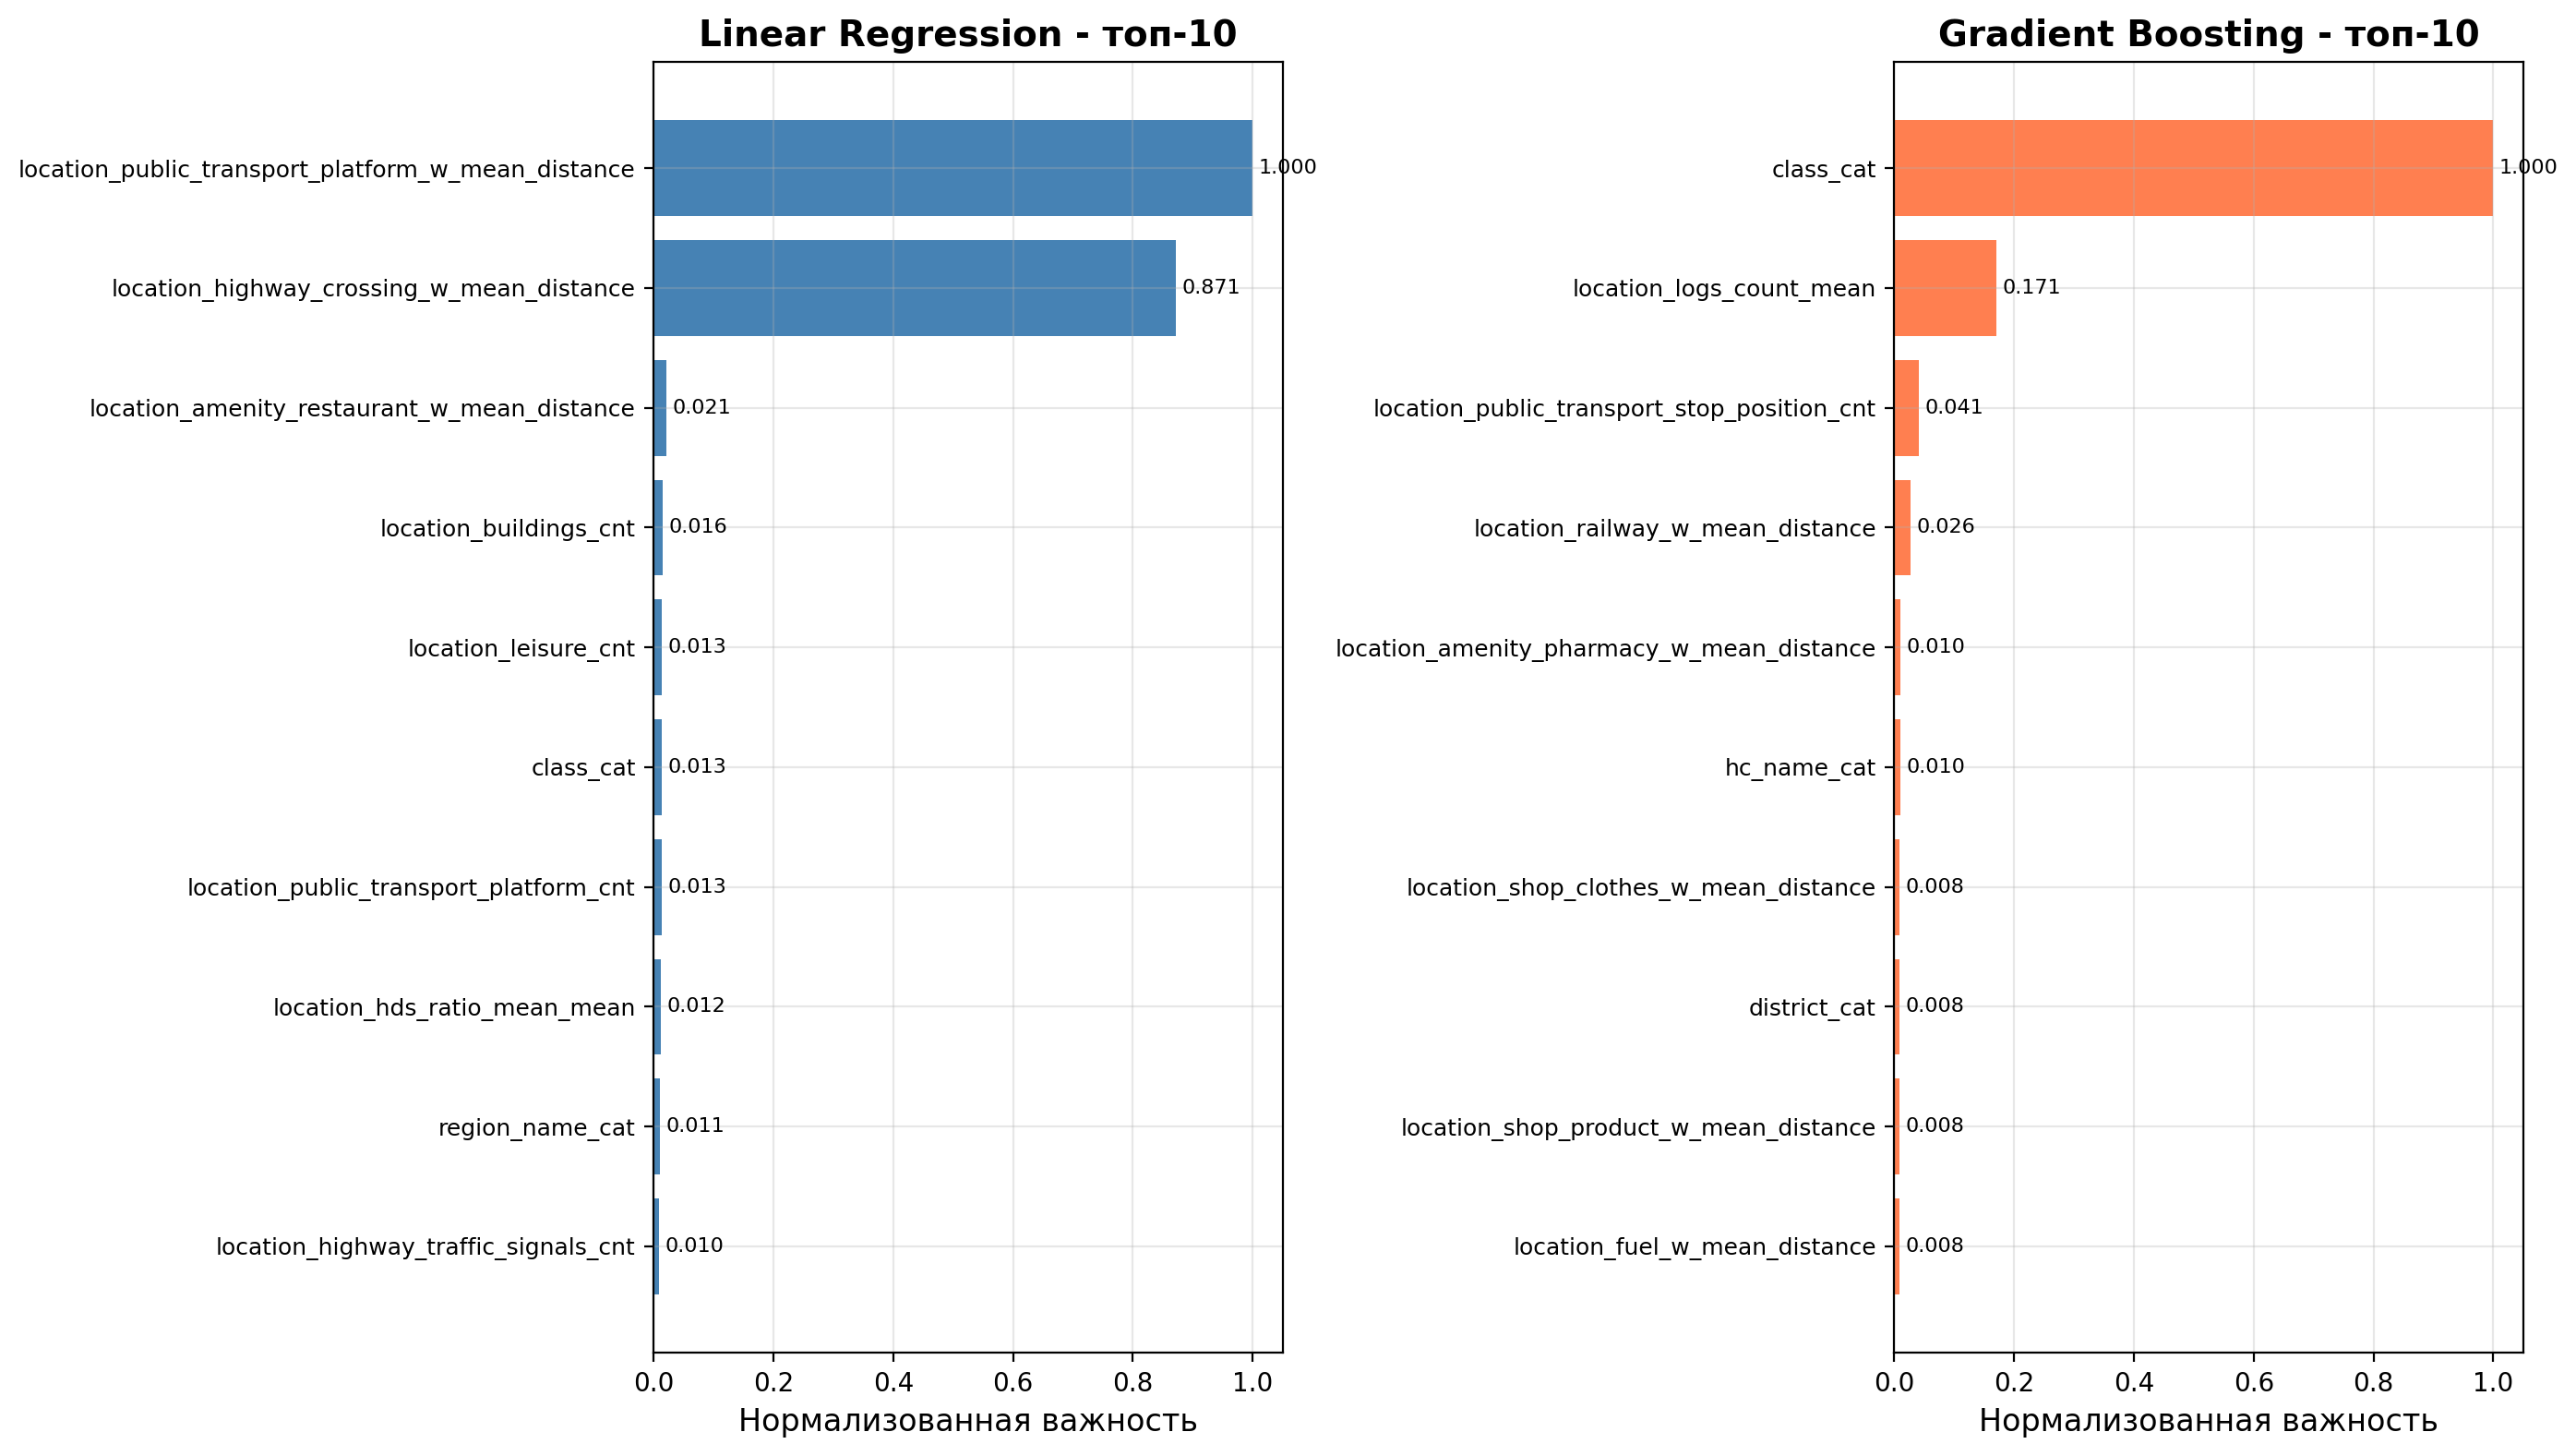

In [38]:
print("Сравнение моделей (n_repeats=30)")

# важности при n=30
lr_imp = lr_perm_results[30]['importances']
gb_imp = gb_perm_results[30]['importances']

comparison = pd.DataFrame({
    'Feature': feature_names,
    'Linear_Regression': lr_imp,
    'Gradient_Boosting': gb_imp
})

comparison['LR_norm'] = comparison['Linear_Regression'] / comparison['Linear_Regression'].max()
comparison['GB_norm'] = comparison['Gradient_Boosting'] / comparison['Gradient_Boosting'].max()
comparison['avg_norm'] = (comparison['LR_norm'] + comparison['GB_norm']) / 2

top10 = comparison.nlargest(10, 'avg_norm')

print("\nТоп-10 признаков по средней важности:")
print(top10[['Feature', 'LR_norm', 'GB_norm']].round(4).to_string(index=False))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8))

# Линейная регрессия
top_lr = comparison.nlargest(10, 'Linear_Regression')
y_pos = np.arange(len(top_lr))
ax1.barh(y_pos, top_lr['LR_norm'].values, color='steelblue')
ax1.set_yticks(y_pos)
ax1.set_yticklabels(top_lr['Feature'].values, fontsize=9)
ax1.set_xlabel('Нормализованная важность', fontsize=12)
ax1.set_title('Linear Regression - топ-10', fontsize=14, fontweight='bold')
ax1.invert_yaxis()
ax1.grid(True, alpha=0.3)

for i, v in enumerate(top_lr['LR_norm'].values):
    ax1.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=8)

# Градиентный бустинг
top_gb = comparison.nlargest(10, 'Gradient_Boosting')
ax2.barh(y_pos, top_gb['GB_norm'].values, color='coral')
ax2.set_yticks(y_pos)
ax2.set_yticklabels(top_gb['Feature'].values, fontsize=9)
ax2.set_xlabel('Нормализованная важность', fontsize=12)
ax2.set_title('Gradient Boosting - топ-10', fontsize=14, fontweight='bold')
ax2.invert_yaxis()
ax2.grid(True, alpha=0.3)

for i, v in enumerate(top_gb['GB_norm'].values):
    ax2.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

## Задание 5: Feature Importance (2 балла)
Пусть важность - это MAPE для тестовых данных. Проведите анализ только для бустинга

Идея перестановочной важности представляет собой частный случай важности при помощи внесения возмущений в признак. Примеры возмущений:
1) внесение случайного шума
2) зануление признака
3) сдвиг признака к его базовому значению и оценка траектории изменения прогнозов или качества модели 

Примем за базовое значение (${base}$)медиану признака и будем сдвигать исходный признак к медианному с некоторым коэффициентом $\beta$:
$x_j^\beta = (1- \beta)x_j + \beta {base}$

Реализуйте это возмущение. Как меняются важности при разных $\beta$?

Постройте графики важности и сравните важности с permutation importance. Используйте только числовые признаки. При этом медиану стоит считать на тренировочном наборе, а важность как разницу MAPE на тестовой выборке. Чем больше разница, тем важнее признак. 


Сравните результаты методов. Какие признаки наиболее важны? Есть ли различия между методами? В чём могут быть причины различий?

In [39]:
X_test_orig = X_test_original.values if 'X_test_original' in dir() else X_test_minmax
y_test_orig = y_test.values

y_pred_base = gb_original.predict(X_test_minmax)
baseline_mape = mean_absolute_percentage_error(y_test_orig, y_pred_base)
print(f"Baseline MAPE: {baseline_mape:.4f}")

num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
numeric_indices = [list(X_train_original.columns).index(col) for col in num_cols]

medians = {}
for col in num_cols:
    medians[col] = np.median(X_train_original[col].values)

Baseline MAPE: 0.0635


In [40]:
def shift_to_median(X, idx, beta, median_val):
    X_mod = X.copy()
    X_mod[:, idx] = (1 - beta) * X[:, idx] + beta * median_val
    return X_mod

def add_noise(X, idx, scale):
    X_mod = X.copy()
    noise = np.random.normal(0, scale * np.std(X[:, idx]), size=X.shape[0])
    X_mod[:, idx] = X[:, idx] + noise
    return X_mod

def zero_out(X, idx):
    X_mod = X.copy()
    X_mod[:, idx] = 0
    return X_mod

In [41]:
betas = [0.1, 0.3, 0.5, 0.7, 0.9, 1.0]
noise_scales = [0.1, 0.3, 0.5, 0.7, 1.0]

shift_results, noise_results, zero_results = {}, {}, {}

for i, col in enumerate(num_cols):
    idx = numeric_indices[i]
    shift_results[col] = []
    for beta in betas:
        X_mod = shift_to_median(X_test_orig, idx, beta, medians[col])
        X_mod_scaled = minmax_scaler.transform(X_mod)
        mape = mean_absolute_percentage_error(y_test_orig, gb_original.predict(X_mod_scaled))
        shift_results[col].append(mape - baseline_mape)
    
    noise_results[col] = []
    for scale in noise_scales:
        X_mod = add_noise(X_test_orig, idx, scale)
        X_mod_scaled = minmax_scaler.transform(X_mod)
        mape = mean_absolute_percentage_error(y_test_orig, gb_original.predict(X_mod_scaled))
        noise_results[col].append(mape - baseline_mape)
    
    X_mod = zero_out(X_test_orig, idx)
    X_mod_scaled = minmax_scaler.transform(X_mod)
    mape = mean_absolute_percentage_error(y_test_orig, gb_original.predict(X_mod_scaled))
    zero_results[col] = mape - baseline_mape

perm_imp = permutation_importance(
    gb_original, X_test_minmax, y_test_orig,
    n_repeats=30, random_state=42, n_jobs=-1,
    scoring='neg_mean_absolute_error'
)
perm_results = {num_cols[i]: -perm_imp.importances_mean[i] for i in range(len(num_cols))}

In [42]:
shift_imp = {col: vals[-1] for col, vals in shift_results.items()}
noise_imp = {col: vals[-1] for col, vals in noise_results.items()}

print("\nСдвиг к медиане:")
for i, (col, val) in enumerate(sorted(shift_imp.items(), key=lambda x: x[1], reverse=True)[:10], 1):
    print(f"  {i}. {col[:45]:45s} {val:.6f}")

print("\nДобавление шума:")
for i, (col, val) in enumerate(sorted(noise_imp.items(), key=lambda x: x[1], reverse=True)[:10], 1):
    print(f"  {i}. {col[:45]:45s} {val:.6f}")

print("\nЗануление:")
for i, (col, val) in enumerate(sorted(zero_results.items(), key=lambda x: x[1], reverse=True)[:10], 1):
    print(f"  {i}. {col[:45]:45s} {val:.6f}")

print("\nPermutation:")
for i, (col, val) in enumerate(sorted(perm_results.items(), key=lambda x: x[1], reverse=True)[:10], 1):
    print(f"  {i}. {col[:45]:45s} {val:.6f}")


Сдвиг к медиане:
  1. location_logs_count_mean                      0.021307
  2. location_shop_product_w_mean_distance         0.008266
  3. square                                        0.006188
  4. location_fuel_w_mean_distance                 0.005805
  5. location_amenity_pharmacy_w_mean_distance     0.005717
  6. location_mean_area_density                    0.003852
  7. location_tourism_w_mean_distance              0.003618
  8. location_public_transport_stop_position_cnt   0.003385
  9. location_railway_cnt                          0.003321
  10. location_public_transport_stop_position_w_mea 0.002793

Добавление шума:
  1. location_logs_count_mean                      0.026794
  2. location_shop_clothes_w_mean_distance         0.022638
  3. location_public_transport_stop_position_cnt   0.014341
  4. location_shop_product_w_mean_distance         0.014178
  5. location_fuel_w_mean_distance                 0.007832
  6. location_tourism_w_mean_distance              0.007484
  7

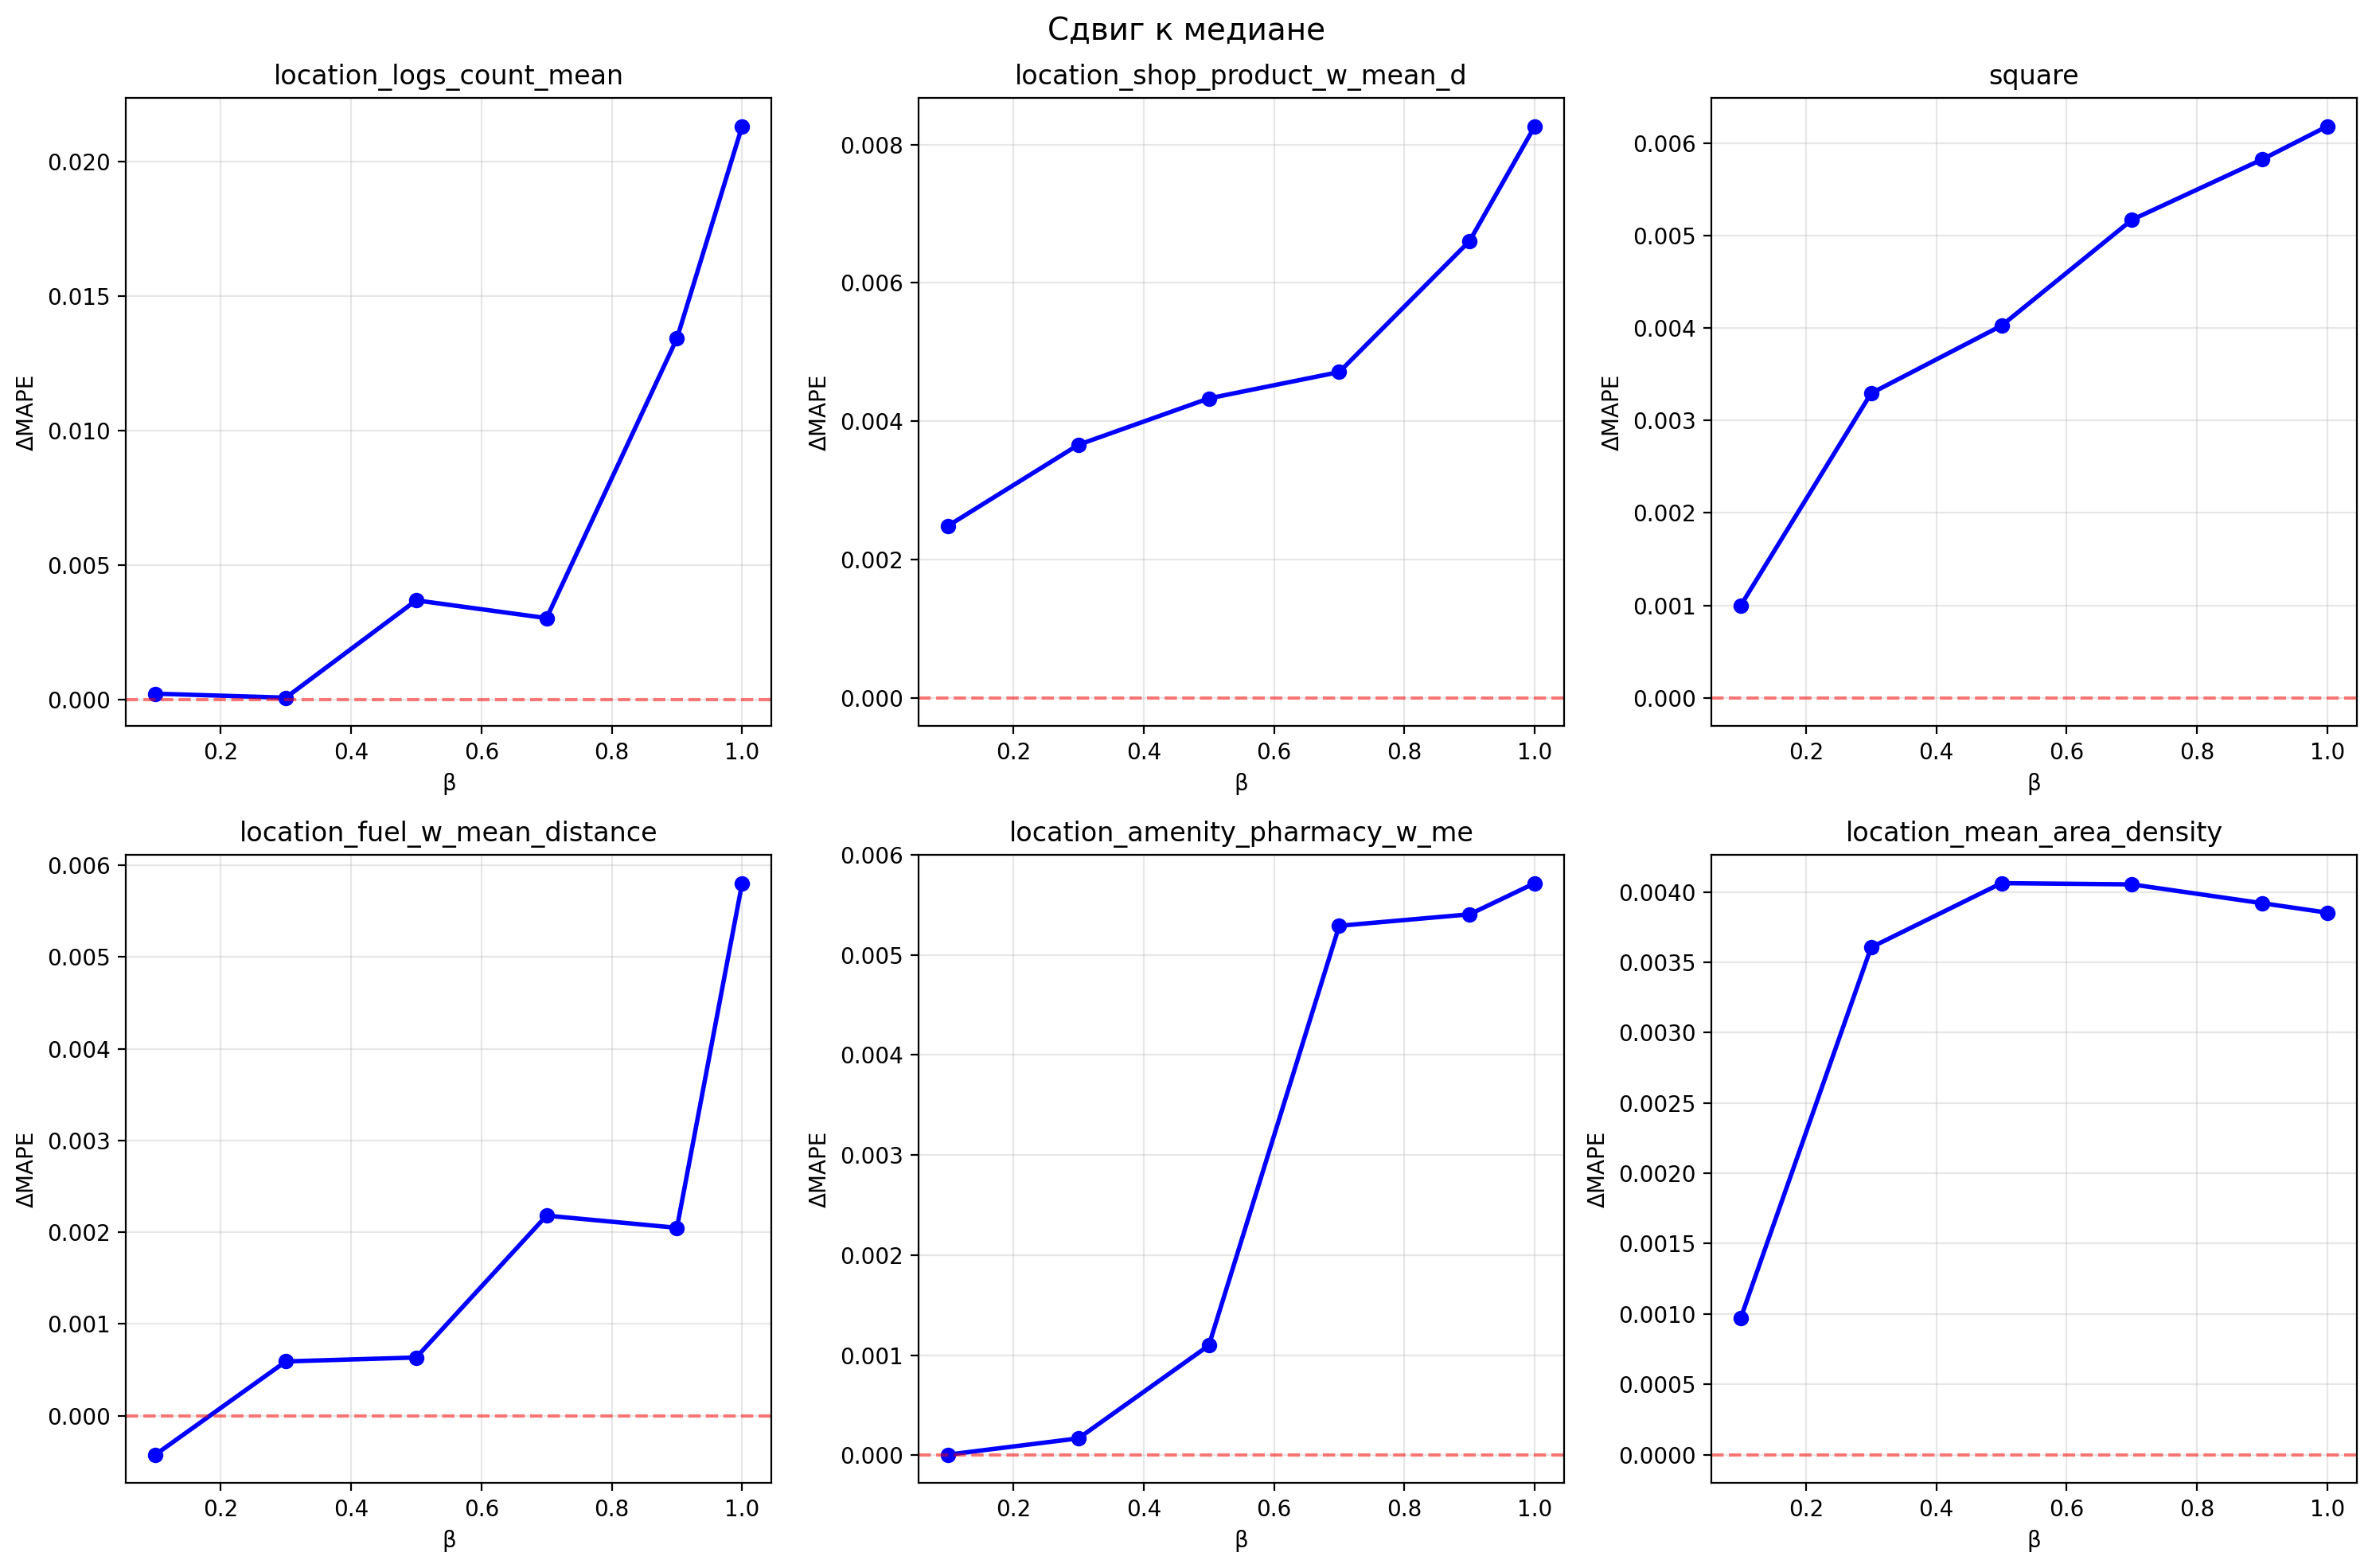

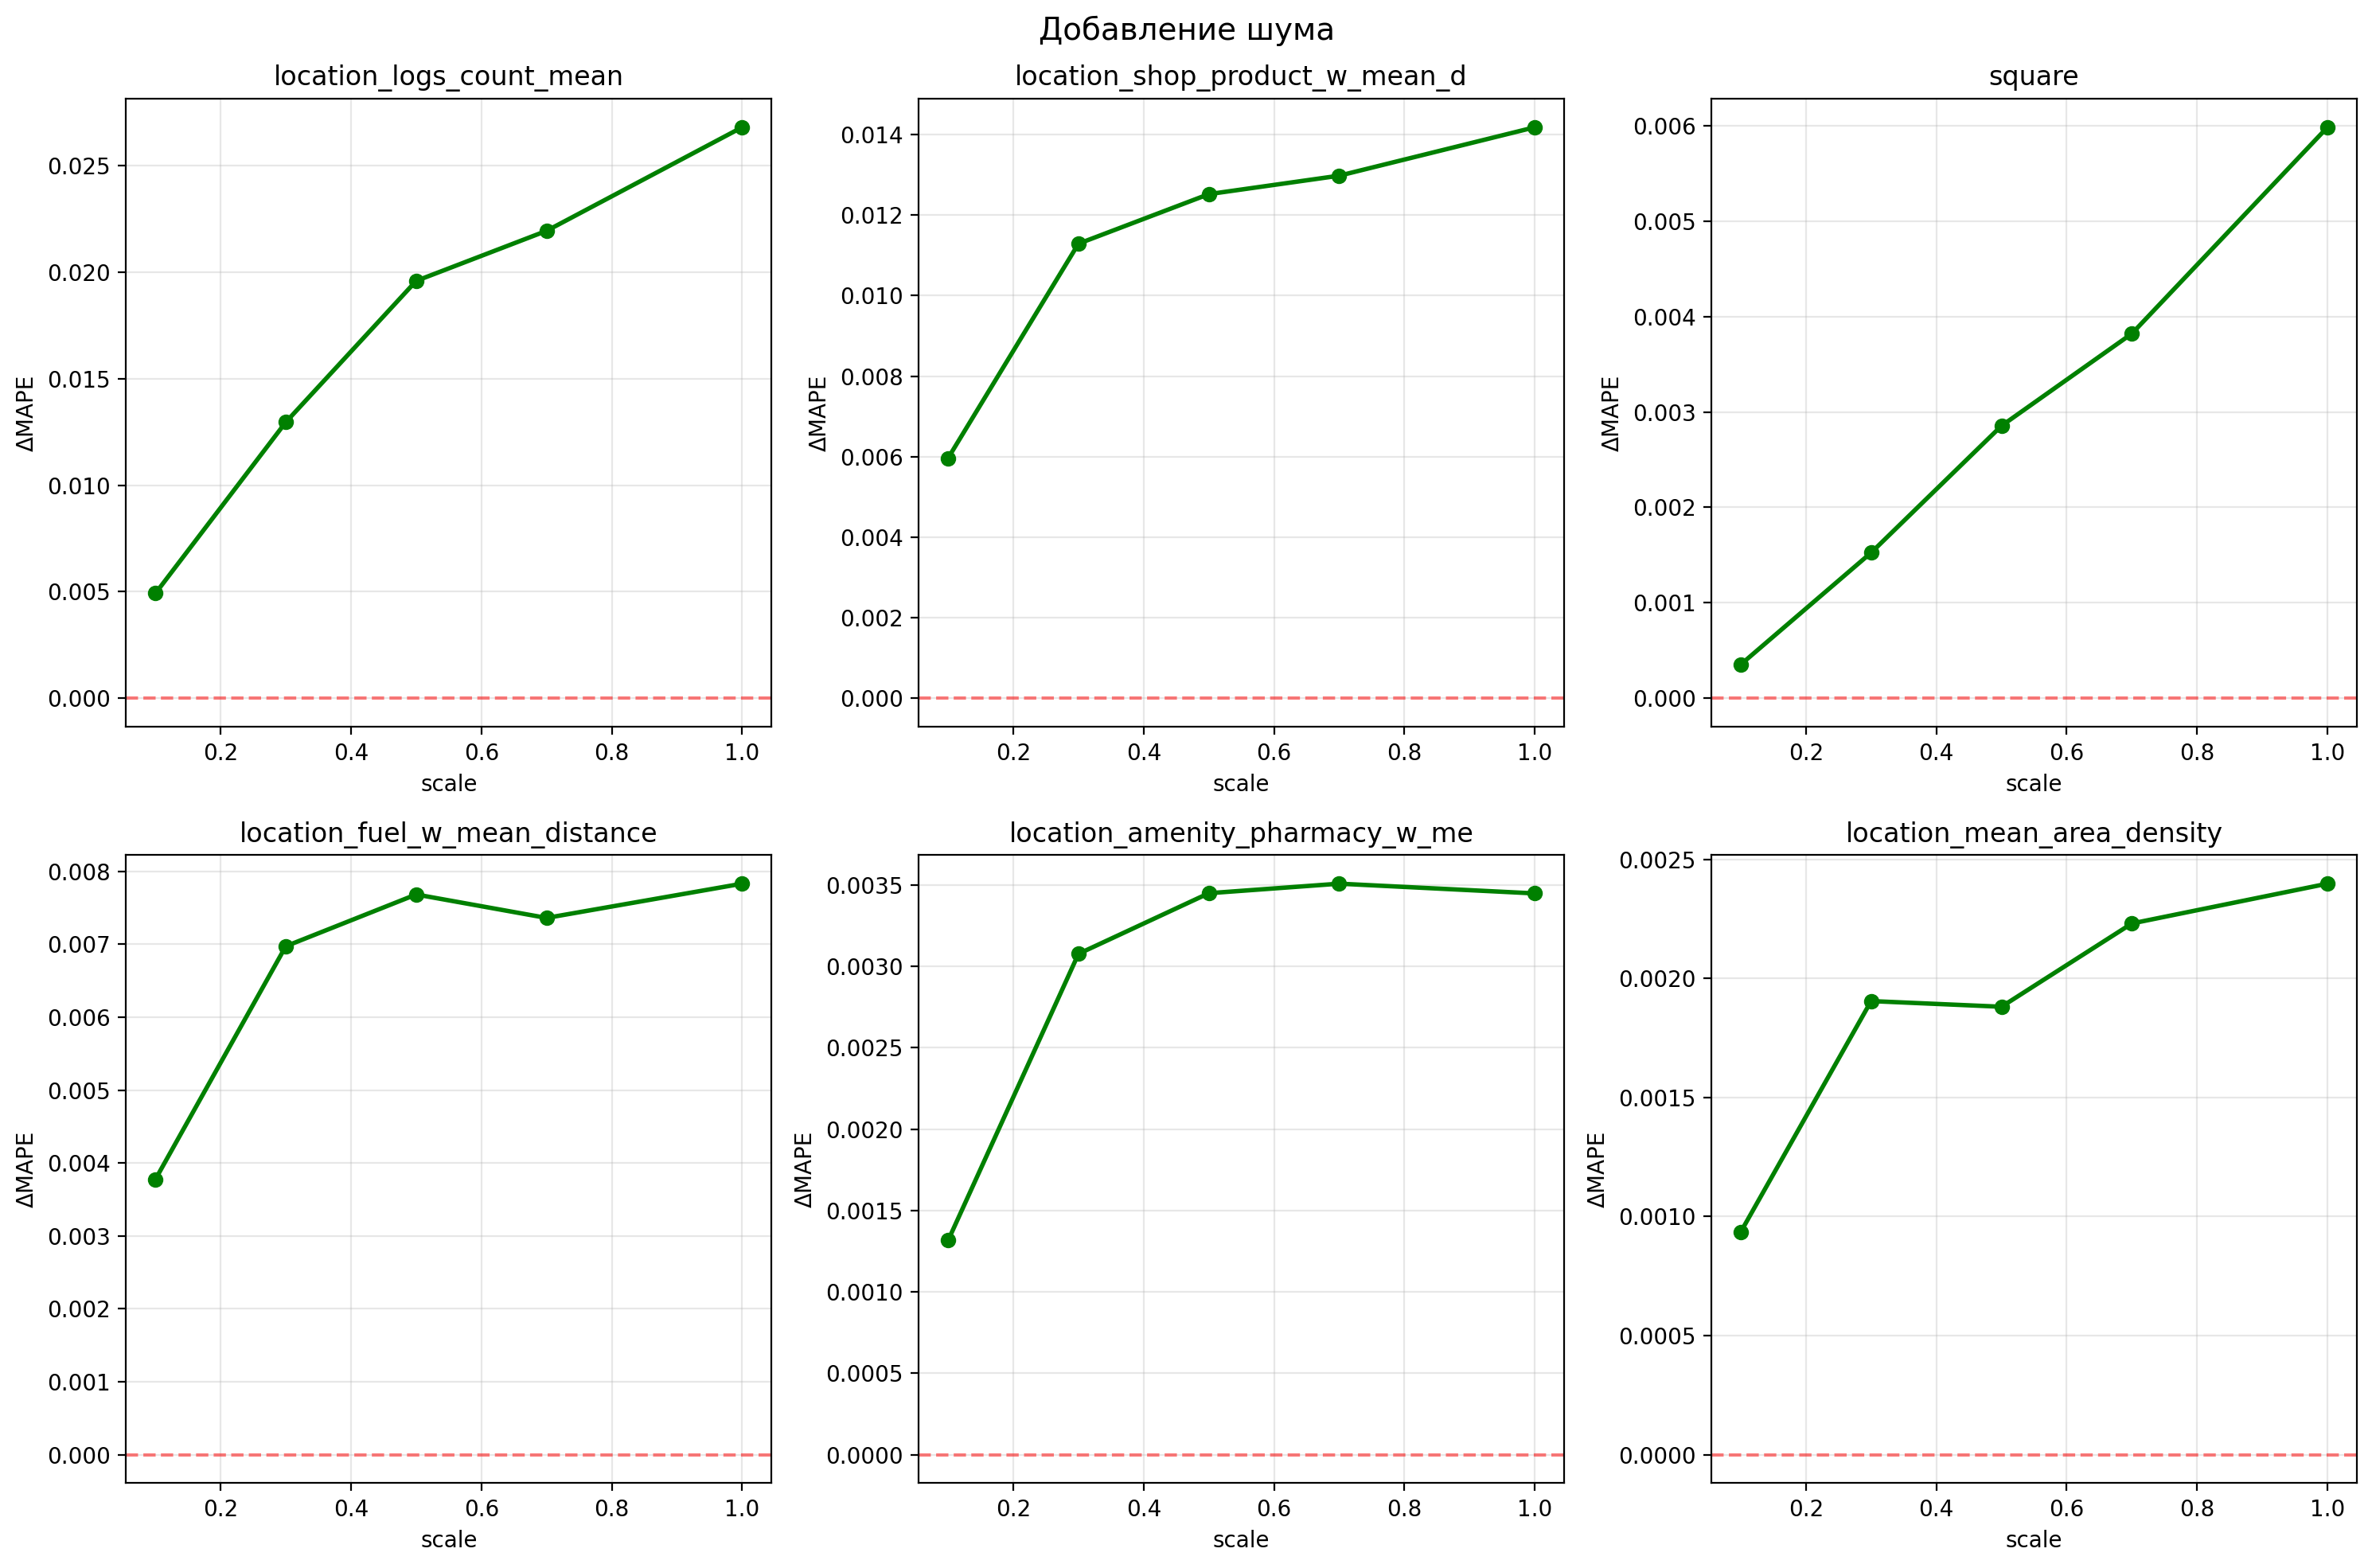

In [43]:
top6 = [col for col, _ in sorted(shift_imp.items(), key=lambda x: x[1], reverse=True)[:6]]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for idx, col in enumerate(top6):
    ax = axes.flatten()[idx]
    ax.plot(betas, shift_results[col], 'b-o', linewidth=2, markersize=6)
    ax.set_xlabel('β')
    ax.set_ylabel('ΔMAPE')
    ax.set_title(col[:30])
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    ax.grid(True, alpha=0.3)
plt.suptitle('Сдвиг к медиане', fontsize=14)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for idx, col in enumerate(top6):
    ax = axes.flatten()[idx]
    ax.plot(noise_scales, noise_results[col], 'g-o', linewidth=2, markersize=6)
    ax.set_xlabel('scale')
    ax.set_ylabel('ΔMAPE')
    ax.set_title(col[:30])
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    ax.grid(True, alpha=0.3)
plt.suptitle('Добавление шума', fontsize=14)
plt.tight_layout()
plt.show()

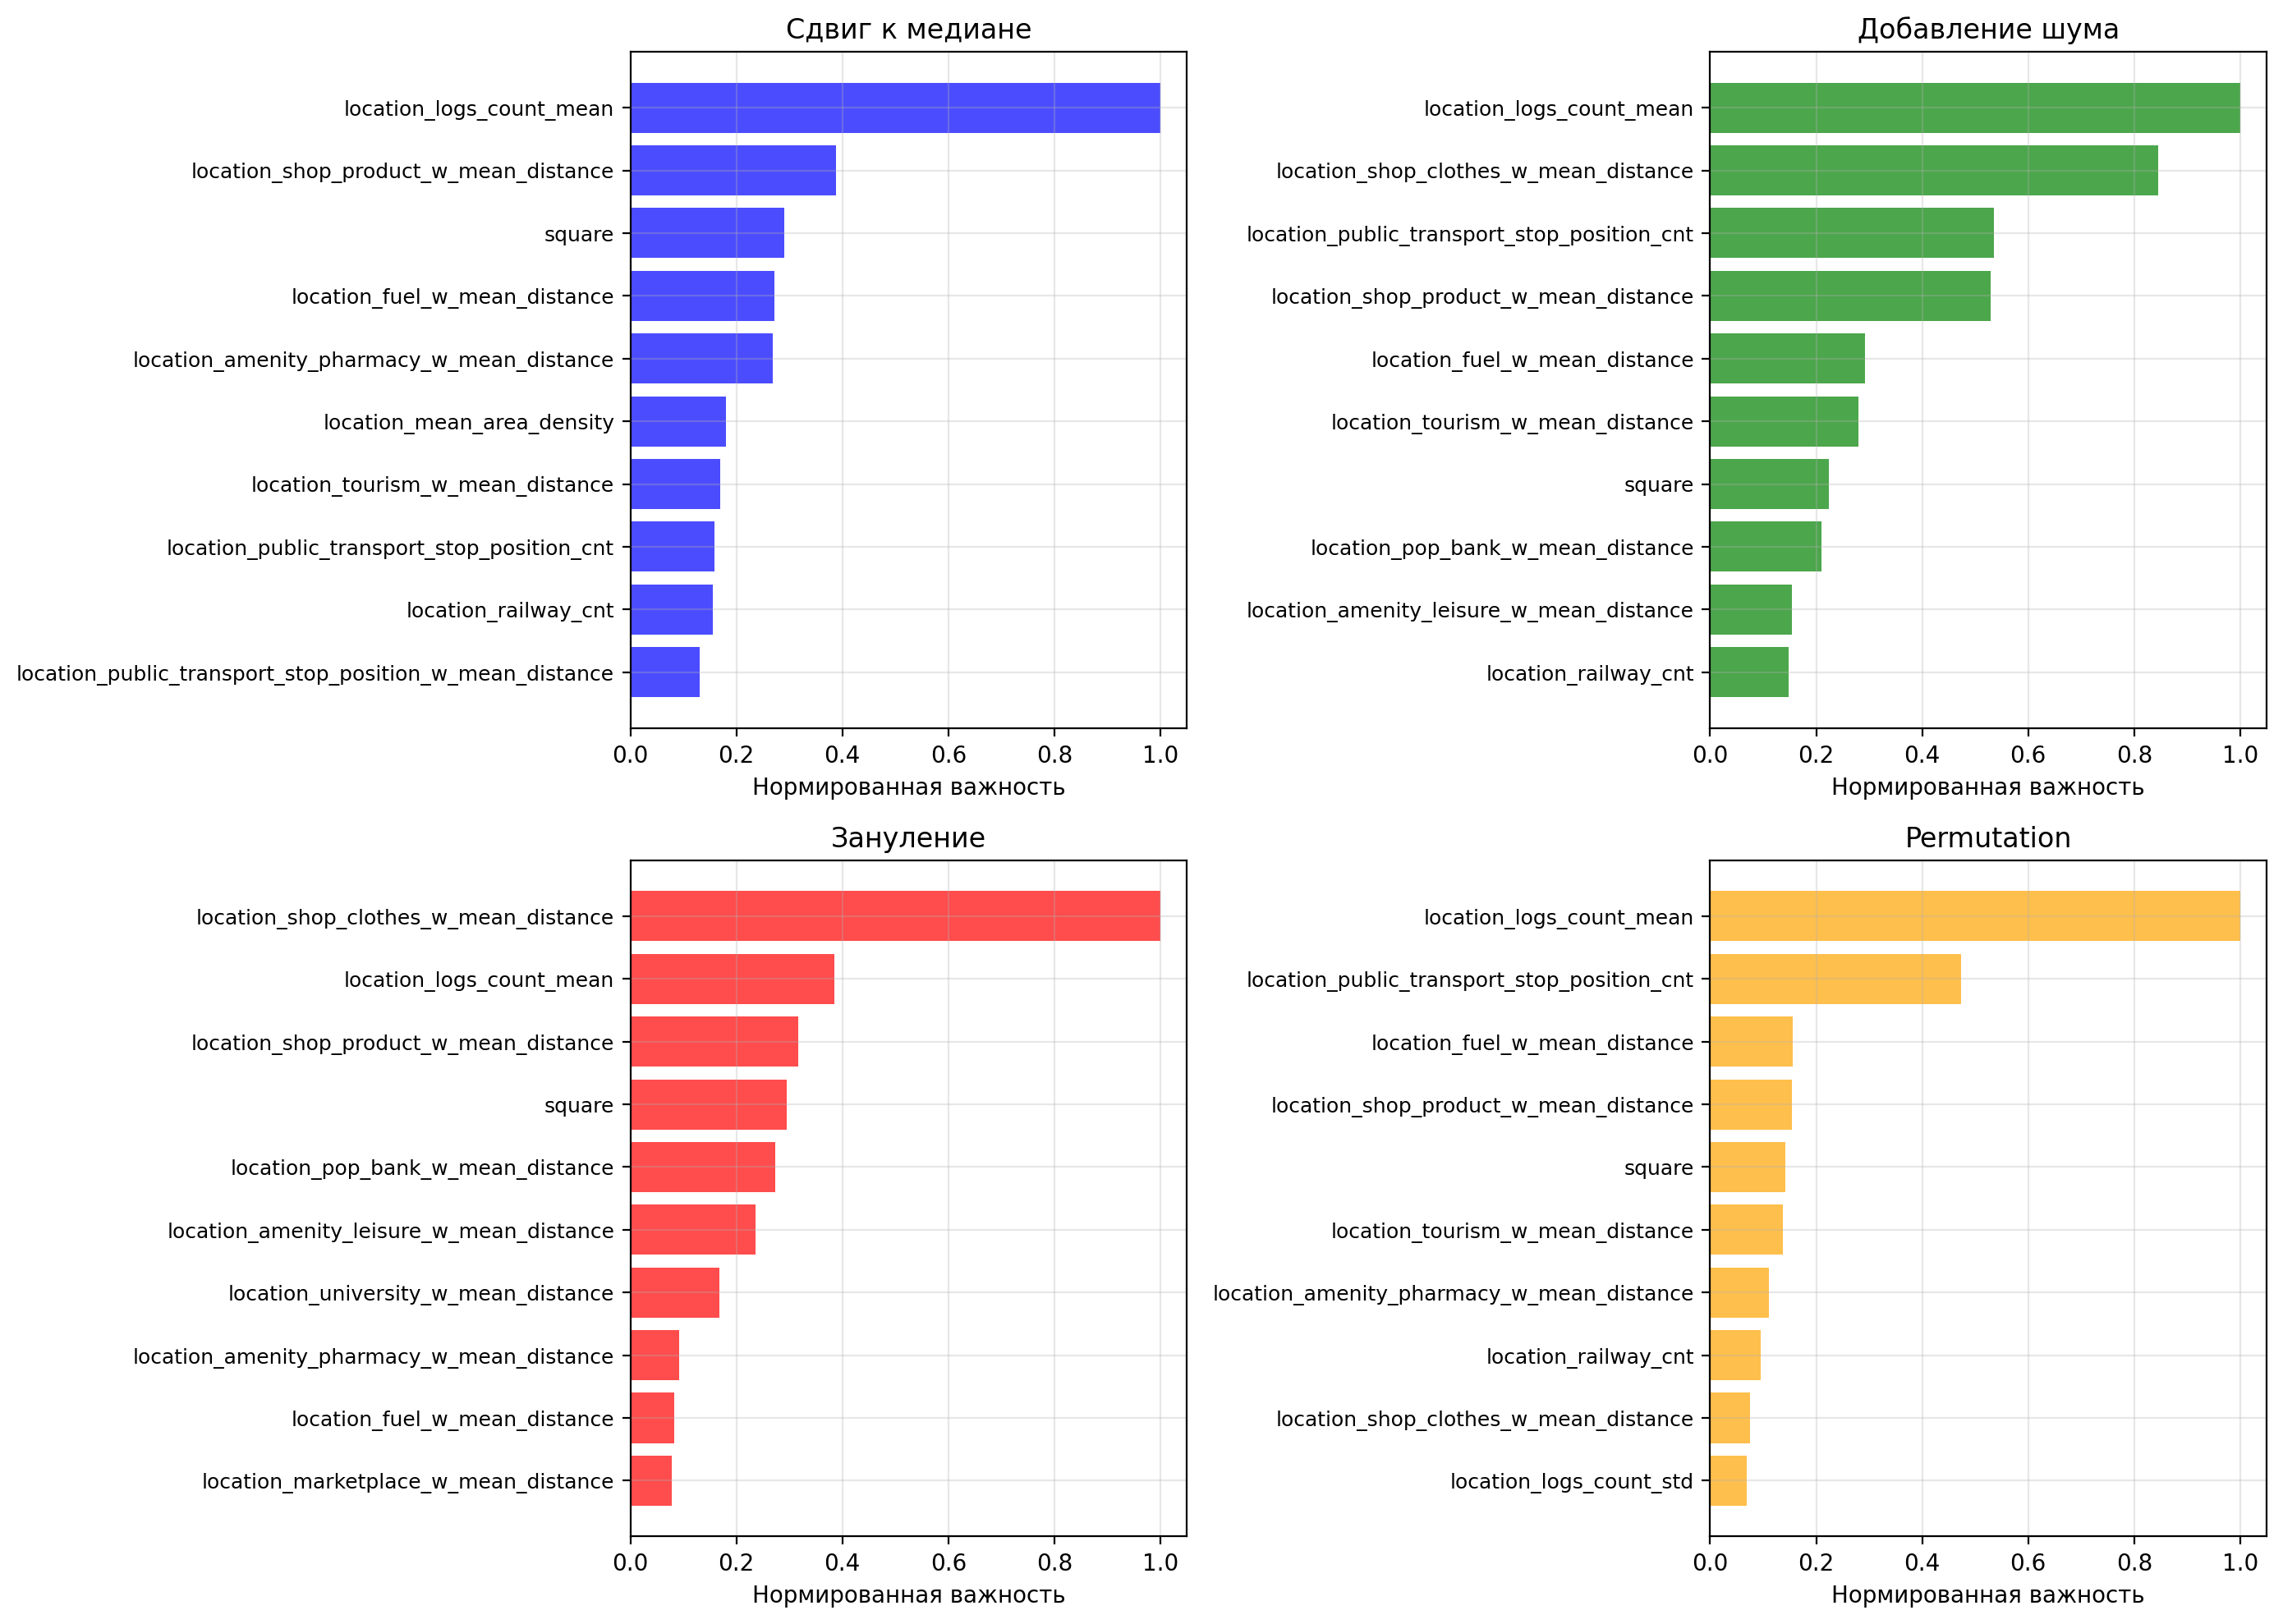

In [44]:
comp = pd.DataFrame({
    'feature': num_cols,
    'shift': [shift_imp[c] for c in num_cols],
    'noise': [noise_imp[c] for c in num_cols],
    'zero': [zero_results[c] for c in num_cols],
    'perm': [perm_results[c] for c in num_cols]
})

for col in ['shift', 'noise', 'zero']:
    comp[f'{col}_norm'] = comp[col] / comp[col].max()
comp['perm_norm'] = np.abs(comp['perm']) / np.abs(comp['perm']).max()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
methods = [('shift_norm', 'Сдвиг к медиане', 'blue'),
           ('noise_norm', 'Добавление шума', 'green'),
           ('zero_norm', 'Зануление', 'red'),
           ('perm_norm', 'Permutation', 'orange')]

for idx, (col, name, color) in enumerate(methods):
    top = comp.nlargest(10, col)[['feature', col]]
    y_pos = np.arange(len(top))
    axes.flatten()[idx].barh(y_pos, top[col].values, color=color, alpha=0.7)
    axes.flatten()[idx].set_yticks(y_pos)
    axes.flatten()[idx].set_yticklabels(top['feature'].values, fontsize=9)
    axes.flatten()[idx].set_xlabel('Нормированная важность')
    axes.flatten()[idx].set_title(name)
    axes.flatten()[idx].invert_yaxis()
    axes.flatten()[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

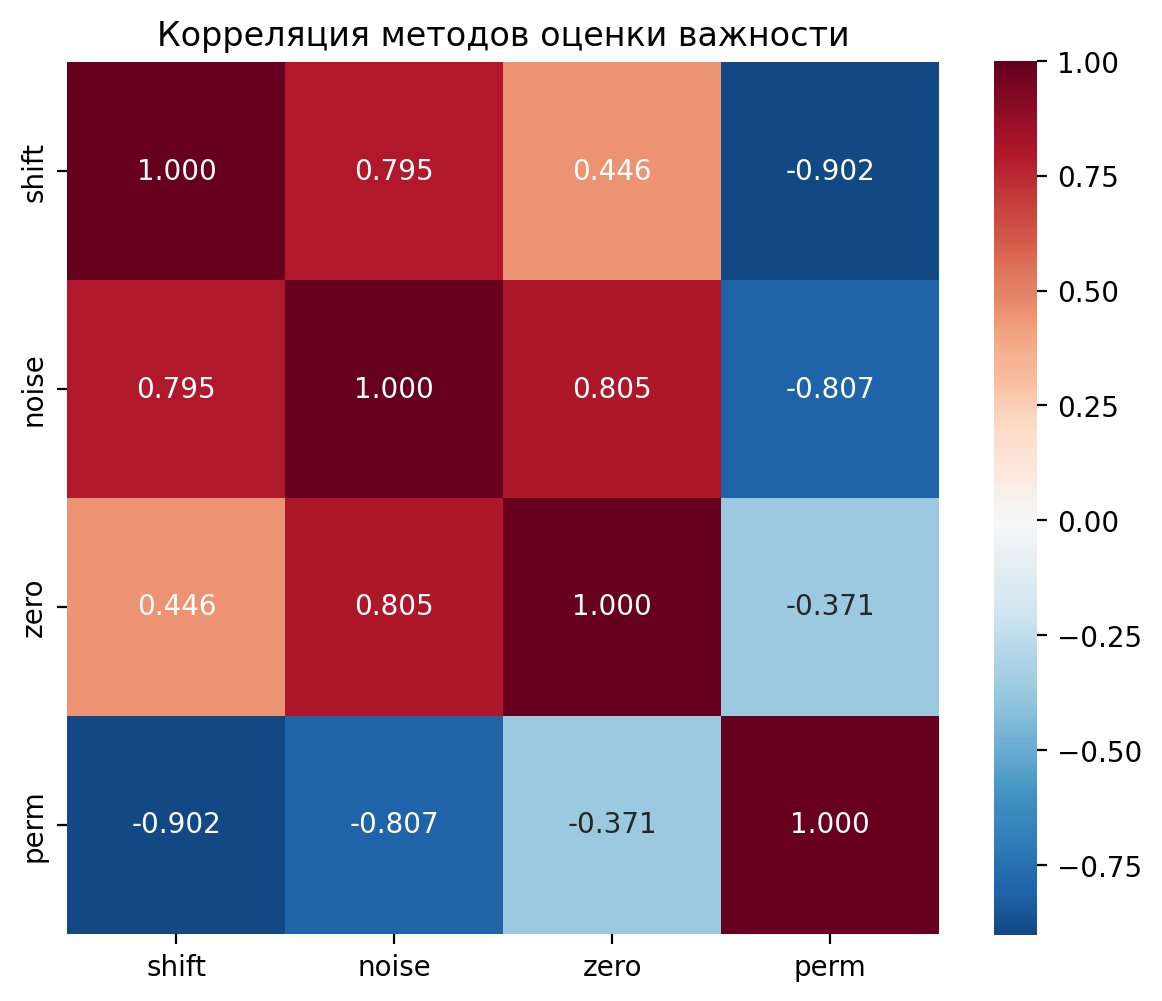

In [45]:
corr = comp[['shift', 'noise', 'zero', 'perm']].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdBu_r', center=0, square=True)
plt.title('Корреляция методов оценки важности')
plt.tight_layout()
plt.show()

top5_shift = set(comp.nlargest(5, 'shift')['feature'])
top5_noise = set(comp.nlargest(5, 'noise')['feature'])
top5_zero = set(comp.nlargest(5, 'zero')['feature'])
top5_perm = set(comp.nlargest(5, 'perm')['feature'])

#  Задание 6. 2 балла. LIME.
Постройте интерпретацию признаков для нескольких примеров с помощью LIME. Можете использовать 
Оцените устойчивость реализации. Как влияет на коэффициенты количество сгенерированных точек? А выбор признаков (lasso/добавление фичей по порядку). А выбор ядра?

(*) Вы получите на 2 балла больше, если используете свою реализацию из задания семинарского ноутбука. В таком случае не забудьте добавить тесты для своей реализации. 



In [46]:
print(f"X_train_minmax shape: {X_train_minmax.shape}")
print(f"X_test_minmax shape: {X_test_minmax.shape}")
print(f"feature_names: {len(feature_names)} признаков")


instance_idx = 5  # возьмем 5-й
print(f"\nЦелевая цена для экземпляра {instance_idx}: {y_test.iloc[instance_idx]:.2f}")
print(f"Предсказание LR: {lr_model.predict(X_test_minmax[instance_idx:instance_idx+1])[0]:.2f}")
print(f"Предсказание GB: {gb_model.predict(X_test_minmax[instance_idx:instance_idx+1])[0]:.2f}")

X_train_minmax shape: (23656, 79)
X_test_minmax shape: (5914, 79)
feature_names: 79 признаков

Целевая цена для экземпляра 5: 62825.45
Предсказание LR: 55813.92
Предсказание GB: 62921.01


In [47]:
def explain_with_lime(model, X_train, X_test, feature_names, instance_idx, num_features=10, num_samples=5000):
    explainer = lime.lime_tabular.LimeTabularExplainer(
        X_train,
        feature_names=feature_names,
        mode='regression',
        verbose=False,
        random_state=42
    )
    
    explanation = explainer.explain_instance(
        X_test[instance_idx],
        model.predict,
        num_features=num_features,
        num_samples=num_samples
    )
    
    return explanation

# Для линейной регрессии
exp_lr = explain_with_lime(lr_model, X_train_minmax, X_test_minmax, feature_names, instance_idx)

print("LIME feature importance (Linear Regression):\n")
for feat, weight in exp_lr.as_list():
    print(f"  {feat}: {weight:.2f}")

# Для градиентного бустинга
exp_gb = explain_with_lime(gb_model, X_train_minmax, X_test_minmax, feature_names, instance_idx)

print("\nLIME feature importance (Gradient Boosting):\n")
for feat, weight in exp_gb.as_list():
    print(f"  {feat}: {weight:.2f}")

LIME feature importance (Linear Regression):

  0.03 < location_highway_crossing_w_mean_distance <= 0.04: 16368.54
  location_motel_cnt <= 0.00: -15204.20
  0.06 < location_public_transport_platform_w_mean_distance <= 0.06: -14419.23
  class_cat <= 0.50: 11368.55
  region_name_cat <= 0.00: 10517.04
  location_buildings_cnt > 0.30: 9815.30
  location_highway_traffic_signals_cnt > 0.30: 7542.15
  location_public_transport_platform_cnt > 0.60: -6437.24
  hc_name_cat > 0.67: 6206.51
  location_residential_cnt > 0.32: -5193.35

LIME feature importance (Gradient Boosting):

  class_cat <= 0.50: 11294.98
  0.47 < location_logs_count_mean <= 0.53: 1296.35
  location_max_levels_max > 0.34: 842.64
  month <= 0.18: -666.94
  0.00 < location_suburb_cnt <= 0.14: 645.12
  location_mean_area_density > 0.60: 632.98
  square > 0.13: -615.35
  0.00 < location_pop_cafe_cnt <= 0.14: 593.87
  0.06 < location_tourism_w_mean_distance <= 0.08: 570.63
  location_motel_cnt <= 0.00: 485.74


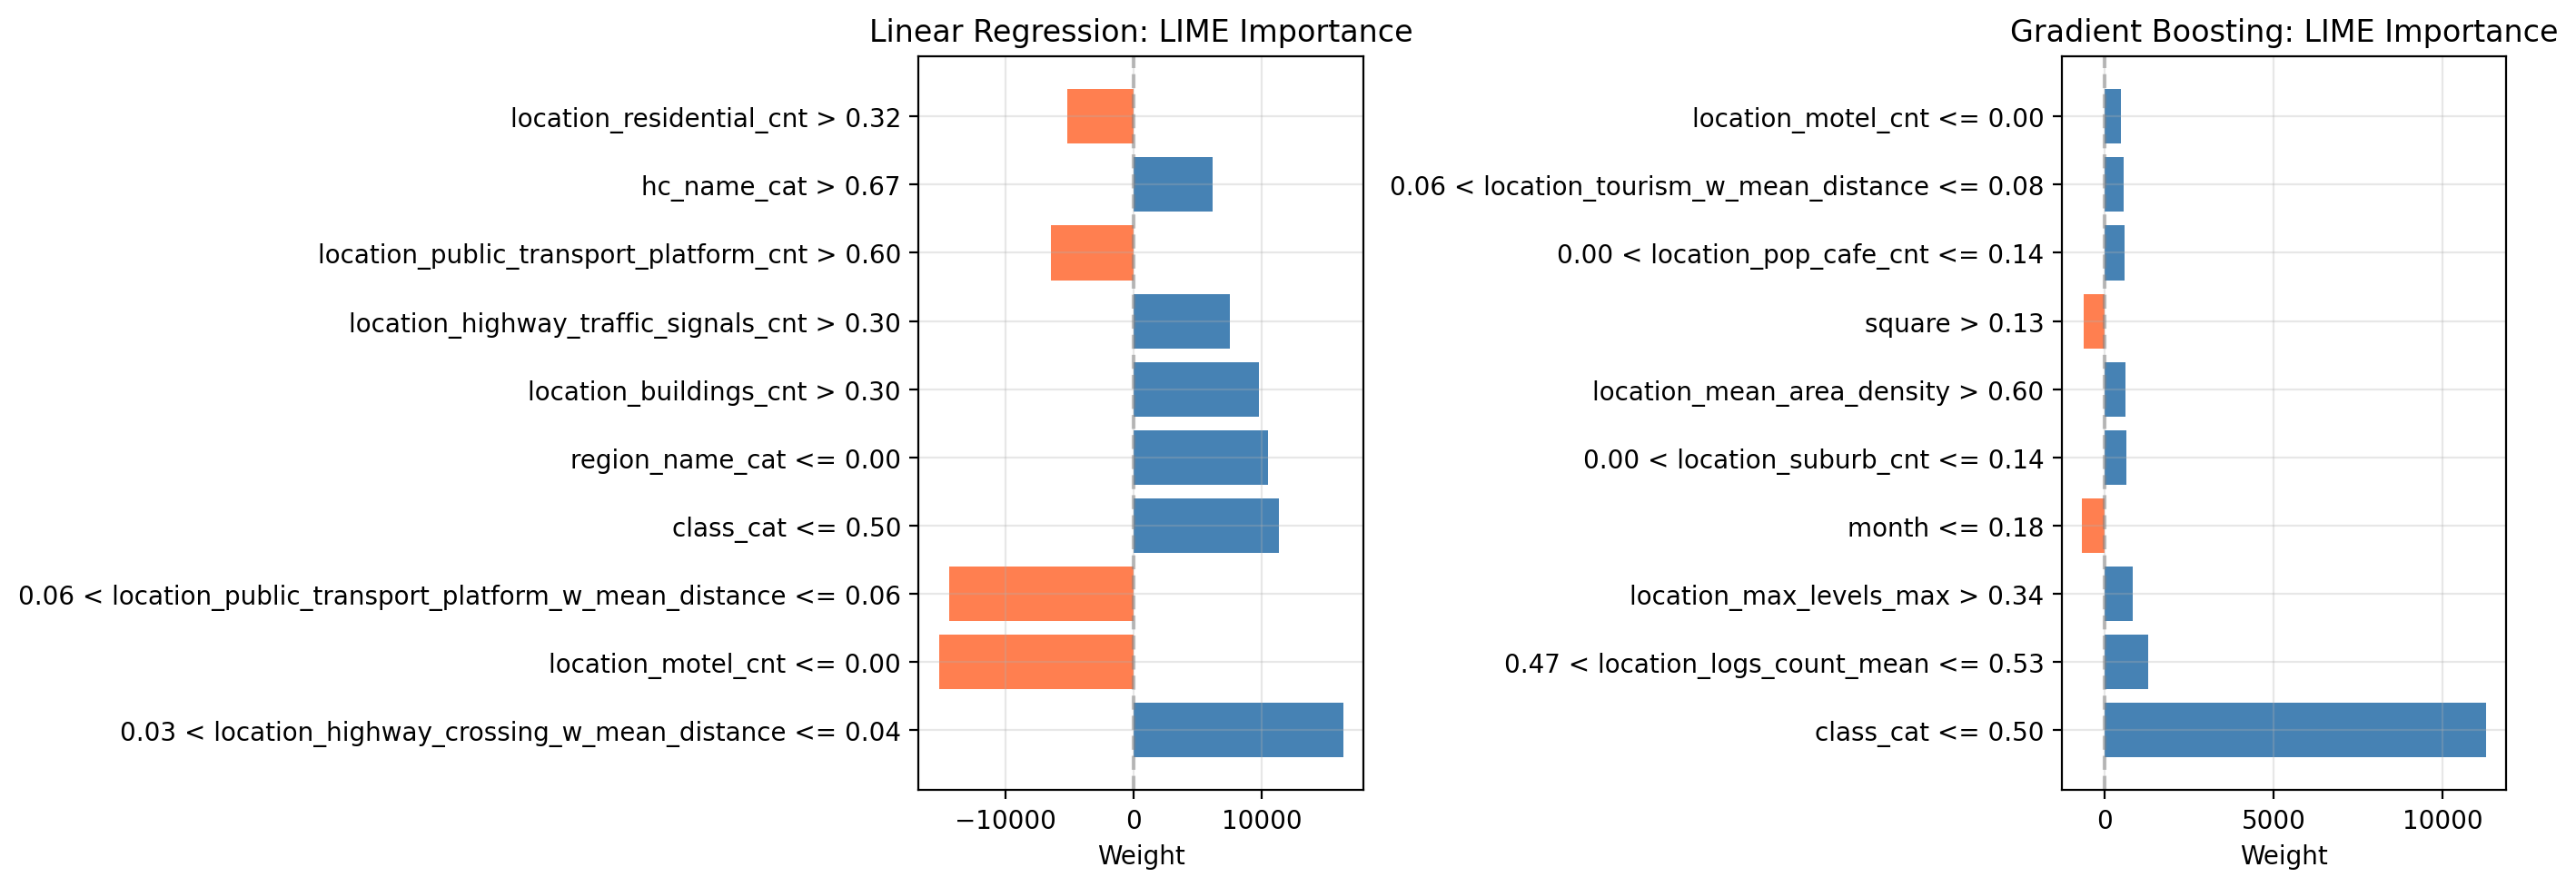

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Линейная регрессия
lr_features = [f[0] for f in exp_lr.as_list()]
lr_weights = [f[1] for f in exp_lr.as_list()]
colors = ['steelblue' if w > 0 else 'coral' for w in lr_weights]
axes[0].barh(lr_features, lr_weights, color=colors)
axes[0].axvline(x=0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_title('Linear Regression: LIME Importance')
axes[0].set_xlabel('Weight')
axes[0].grid(True, alpha=0.3)

# Градиентный бустинг
gb_features = [f[0] for f in exp_gb.as_list()]
gb_weights = [f[1] for f in exp_gb.as_list()]
colors = ['steelblue' if w > 0 else 'coral' for w in gb_weights]
axes[1].barh(gb_features, gb_weights, color=colors)
axes[1].axvline(x=0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_title('Gradient Boosting: LIME Importance')
axes[1].set_xlabel('Weight')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Stability analysis for Linear Regression

n_samples = 1000:
    0.03 < location_highway_crossing_w_mean_distance <= 0.04: 14307.19
    class_cat <= 0.50: 13430.29
    0.06 < location_public_transport_platform_w_mean_distance <= 0.06: -12044.97
    region_name_cat <= 0.00: 10765.28
    location_buildings_cnt > 0.30: 10264.69

n_samples = 2000:
    0.03 < location_highway_crossing_w_mean_distance <= 0.04: 16568.12
    0.06 < location_public_transport_platform_w_mean_distance <= 0.06: -15641.38
    location_highway_traffic_signals_cnt > 0.30: 12102.36
    class_cat <= 0.50: 12002.60
    location_buildings_cnt > 0.30: 11392.51
    Среднее изменение: 5213.42

n_samples = 5000:
    0.03 < location_highway_crossing_w_mean_distance <= 0.04: 16487.94
    0.06 < location_public_transport_platform_w_mean_distance <= 0.06: -14528.47
    class_cat <= 0.50: 11246.35
    region_name_cat <= 0.00: 10614.77
    location_buildings_cnt > 0.30: 10145.52
    Среднее изменение: 4318.91

n_samples = 10000:
  

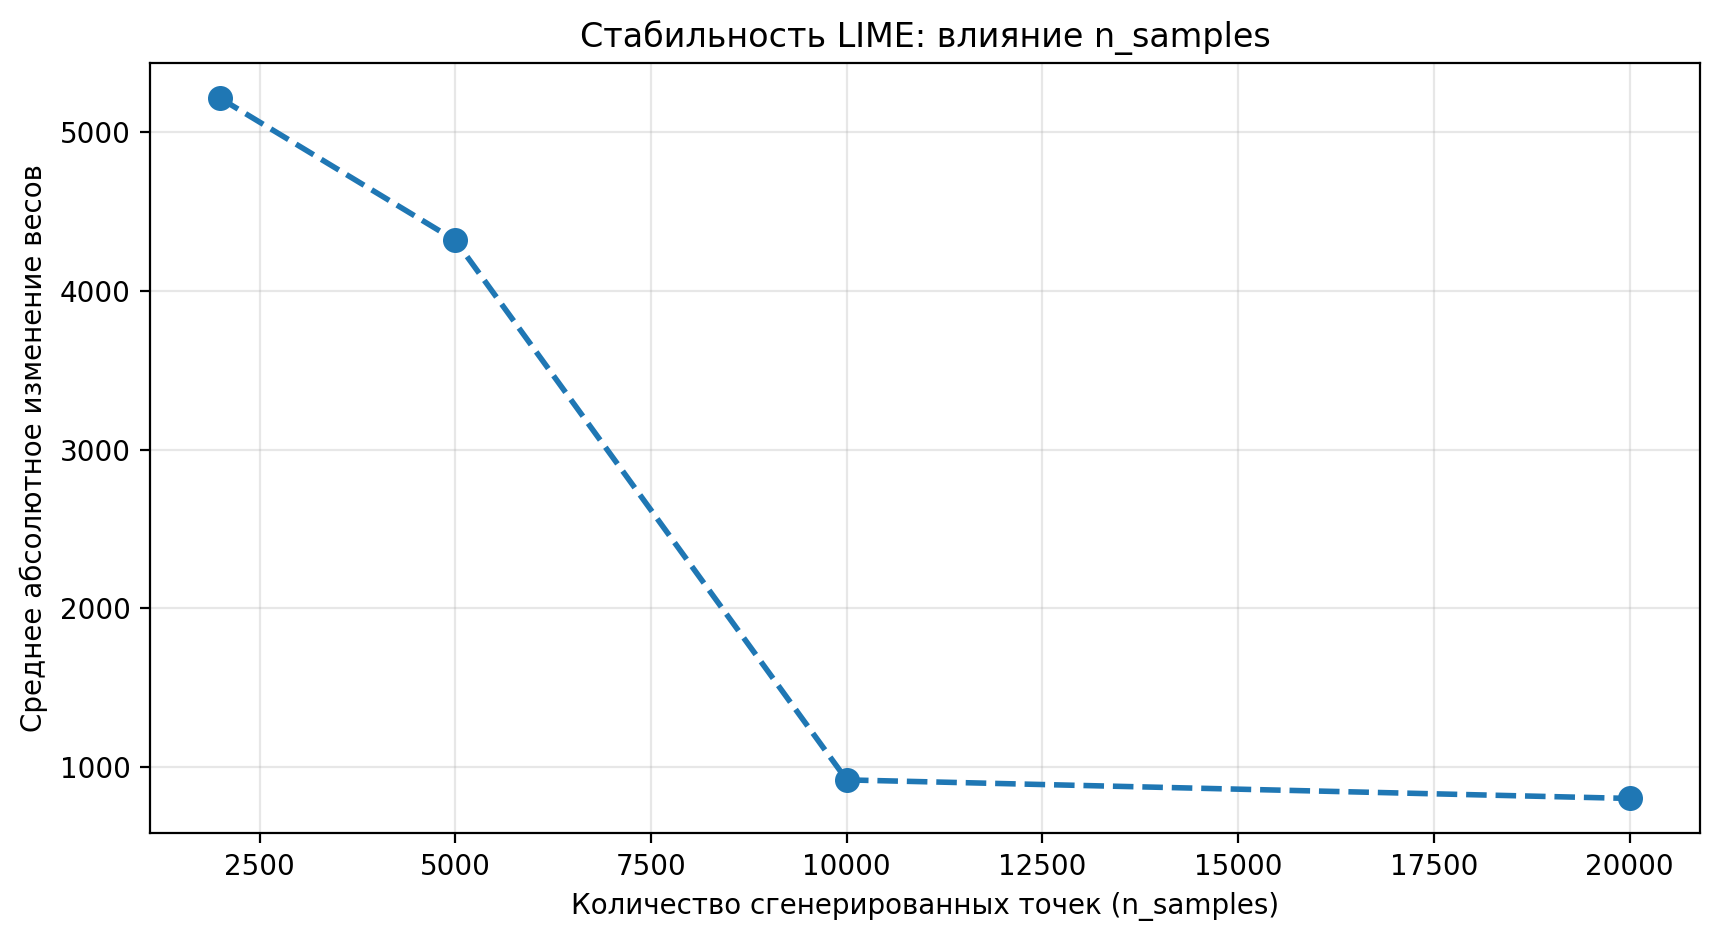


Stability analysis for Gradient Boosting

n_samples = 1000:
    class_cat <= 0.50: 12528.35
    0.08 < location_fuel_w_mean_distance <= 0.09: 1897.03
    0.07 < location_industrial_cnt <= 0.13: 1836.16
    location_hds_ratio_mean_mean > 0.91: 1805.11
    0.06 < location_tourism_w_mean_distance <= 0.08: 1570.29

n_samples = 2000:
    class_cat <= 0.50: 11742.66
    0.47 < location_logs_count_mean <= 0.53: 1305.20
    0.16 < location_logs_count_std <= 0.18: 1037.89
    0.00 < interior_cat <= 0.75: 899.74
    location_water_w_mean_distance <= 0.06: 853.41
    Среднее изменение: 1332.28

n_samples = 5000:
    class_cat <= 0.50: 11289.91
    0.47 < location_logs_count_mean <= 0.53: 1284.50
    location_max_levels_max > 0.34: 823.40
    month <= 0.18: -661.48
    0.00 < location_suburb_cnt <= 0.14: 639.13
    Среднее изменение: 673.56

n_samples = 10000:
    class_cat <= 0.50: 12059.90
    0.08 < location_fuel_w_mean_distance <= 0.09: 847.45
    0.47 < location_logs_count_mean <= 0.53: 810.

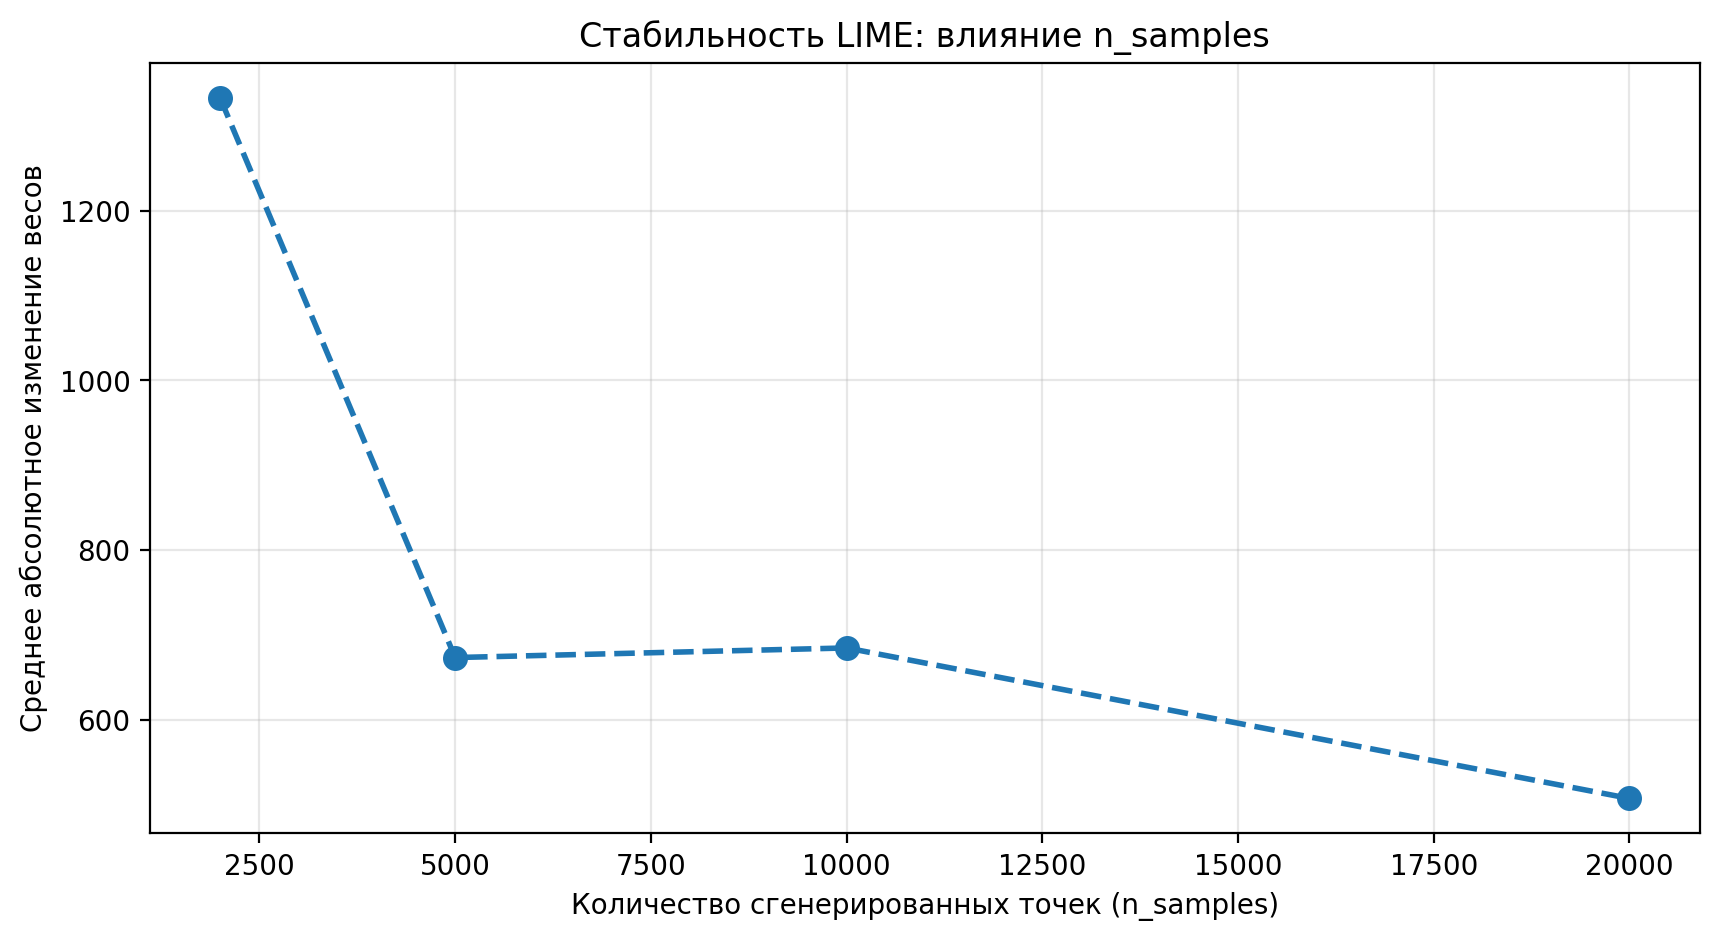

In [49]:
# Анализ устойчивости к количеству сгенерированных точек
def stability_analysis(model, X_train, X_test, feature_names, instance_idx, n_samples_list=[1000, 2000, 5000, 10000, 20000]):
    results = {}
    prev_weights = None
    changes = []
    
    for n_samples in n_samples_list:
        exp = explain_with_lime(model, X_train, X_test, feature_names, instance_idx, num_features=5, num_samples=n_samples)
        weights = {feat: weight for feat, weight in exp.as_list()}
        results[n_samples] = weights
        
        print(f"n_samples = {n_samples}:")
        for feat, weight in list(weights.items())[:5]:
            print(f"    {feat}: {weight:.2f}")
        
        if prev_weights is not None:
            all_feats = set(prev_weights.keys()) | set(weights.keys())
            diff = sum(abs(weights.get(f, 0) - prev_weights.get(f, 0)) for f in all_feats) / len(all_feats)
            changes.append(diff)
            print(f"    Среднее изменение: {diff:.2f}")
        
        prev_weights = weights
        print()
    
    if changes:
        plt.figure(figsize=(10, 5))
        plt.plot(n_samples_list[1:], changes, marker='o', linestyle='--', linewidth=2, markersize=8)
        plt.xlabel('Количество сгенерированных точек (n_samples)')
        plt.ylabel('Среднее абсолютное изменение весов')
        plt.title('Стабильность LIME: влияние n_samples')
        plt.grid(True, alpha=0.3)
        plt.show()
    
    return results

print("Stability analysis for Linear Regression\n")
stability_lr = stability_analysis(lr_model, X_train_minmax, X_test_minmax, feature_names, instance_idx)

print("\nStability analysis for Gradient Boosting\n")
stability_gb = stability_analysis(gb_model, X_train_minmax, X_test_minmax, feature_names, instance_idx)

Linear Regression - Regressor Comparison

Сравнение методов выбора признаков:
Feature                             |        Lasso |        Ridge |       Linear
---------------------------------------------------------------------------
0.03 < location_highway_crossing_w_mean_distance <= 0.04 |     16520.45 |     15764.75 |     16107.92
0.06 < location_public_transport_platform_w_mean_distance <= 0.06 |    -14473.83 |    -13671.32 |    -13853.50
class_cat <= 0.50                   |     11213.71 |     12508.72 |     10776.42
location_buildings_cnt > 0.30       |      9871.86 |     11058.42 |     11900.76
location_highway_traffic_signals_cnt > 0.30 |      7587.99 |      8360.94 |     10991.04
location_market_cnt <= 0.00         |         0.00 |         0.00 |     -6386.36
location_motel_cnt <= 0.00          |    -16334.65 |    -20474.36 |    -38147.77
location_public_transport_platform_cnt > 0.60 |     -6298.82 |     -7416.22 |         0.00
region_name_cat <= 0.00             |     10442.

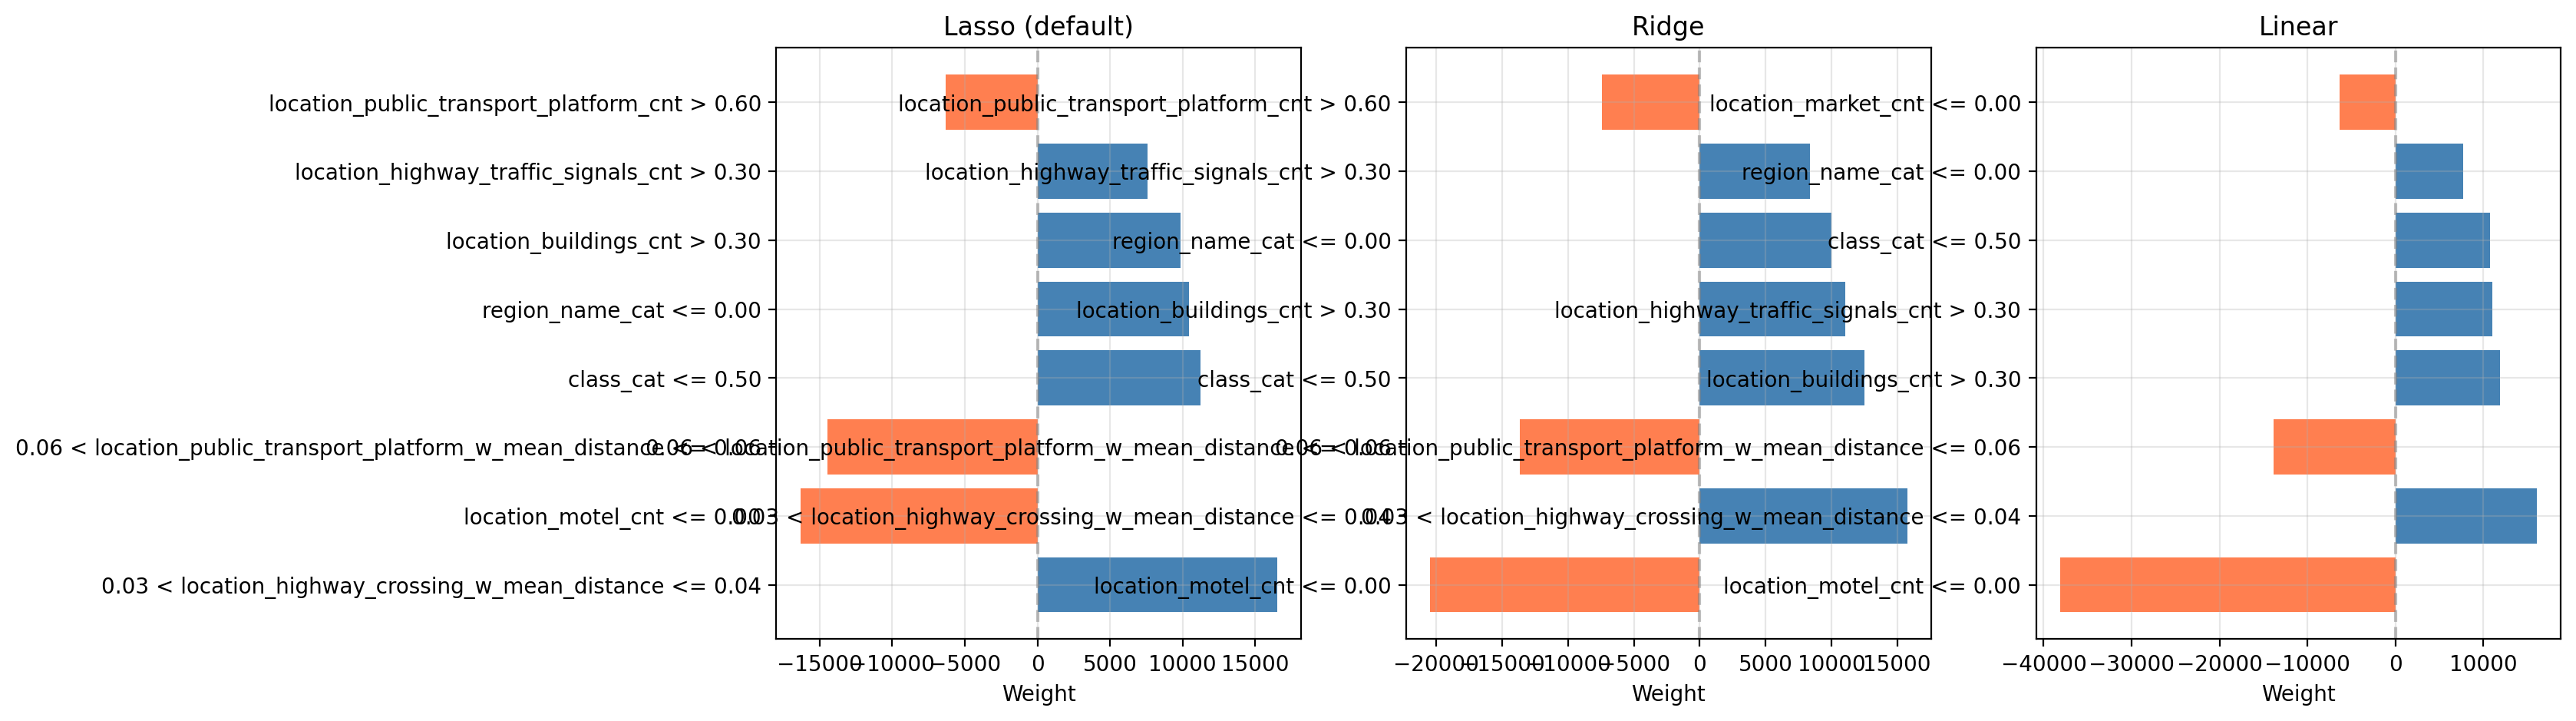

Gradient Boosting - Regressor Comparison

Сравнение методов выбора признаков:
Feature                             |        Lasso |        Ridge |       Linear
---------------------------------------------------------------------------
0.00 < interior_cat <= 0.75         |         0.00 |      1101.78 |       828.75
0.00 < location_suburb_cnt <= 0.14  |       645.20 |         0.00 |         0.00
0.06 < location_railway_w_mean_distance <= 0.08 |         0.00 |       741.01 |         0.00
0.06 < location_tourism_w_mean_distance <= 0.08 |         0.00 |         0.00 |       838.99
0.07 < location_industrial_cnt <= 0.13 |         0.00 |         0.00 |       825.98
0.47 < location_logs_count_mean <= 0.53 |      1278.66 |      1059.62 |       768.30
class_cat <= 0.50                   |     11295.02 |     11980.24 |     11877.96
floor > 0.10                        |         0.00 |         0.00 |       663.45
location_car_rental_cnt <= 0.00     |         0.00 |      -875.91 |      -660.92
locat

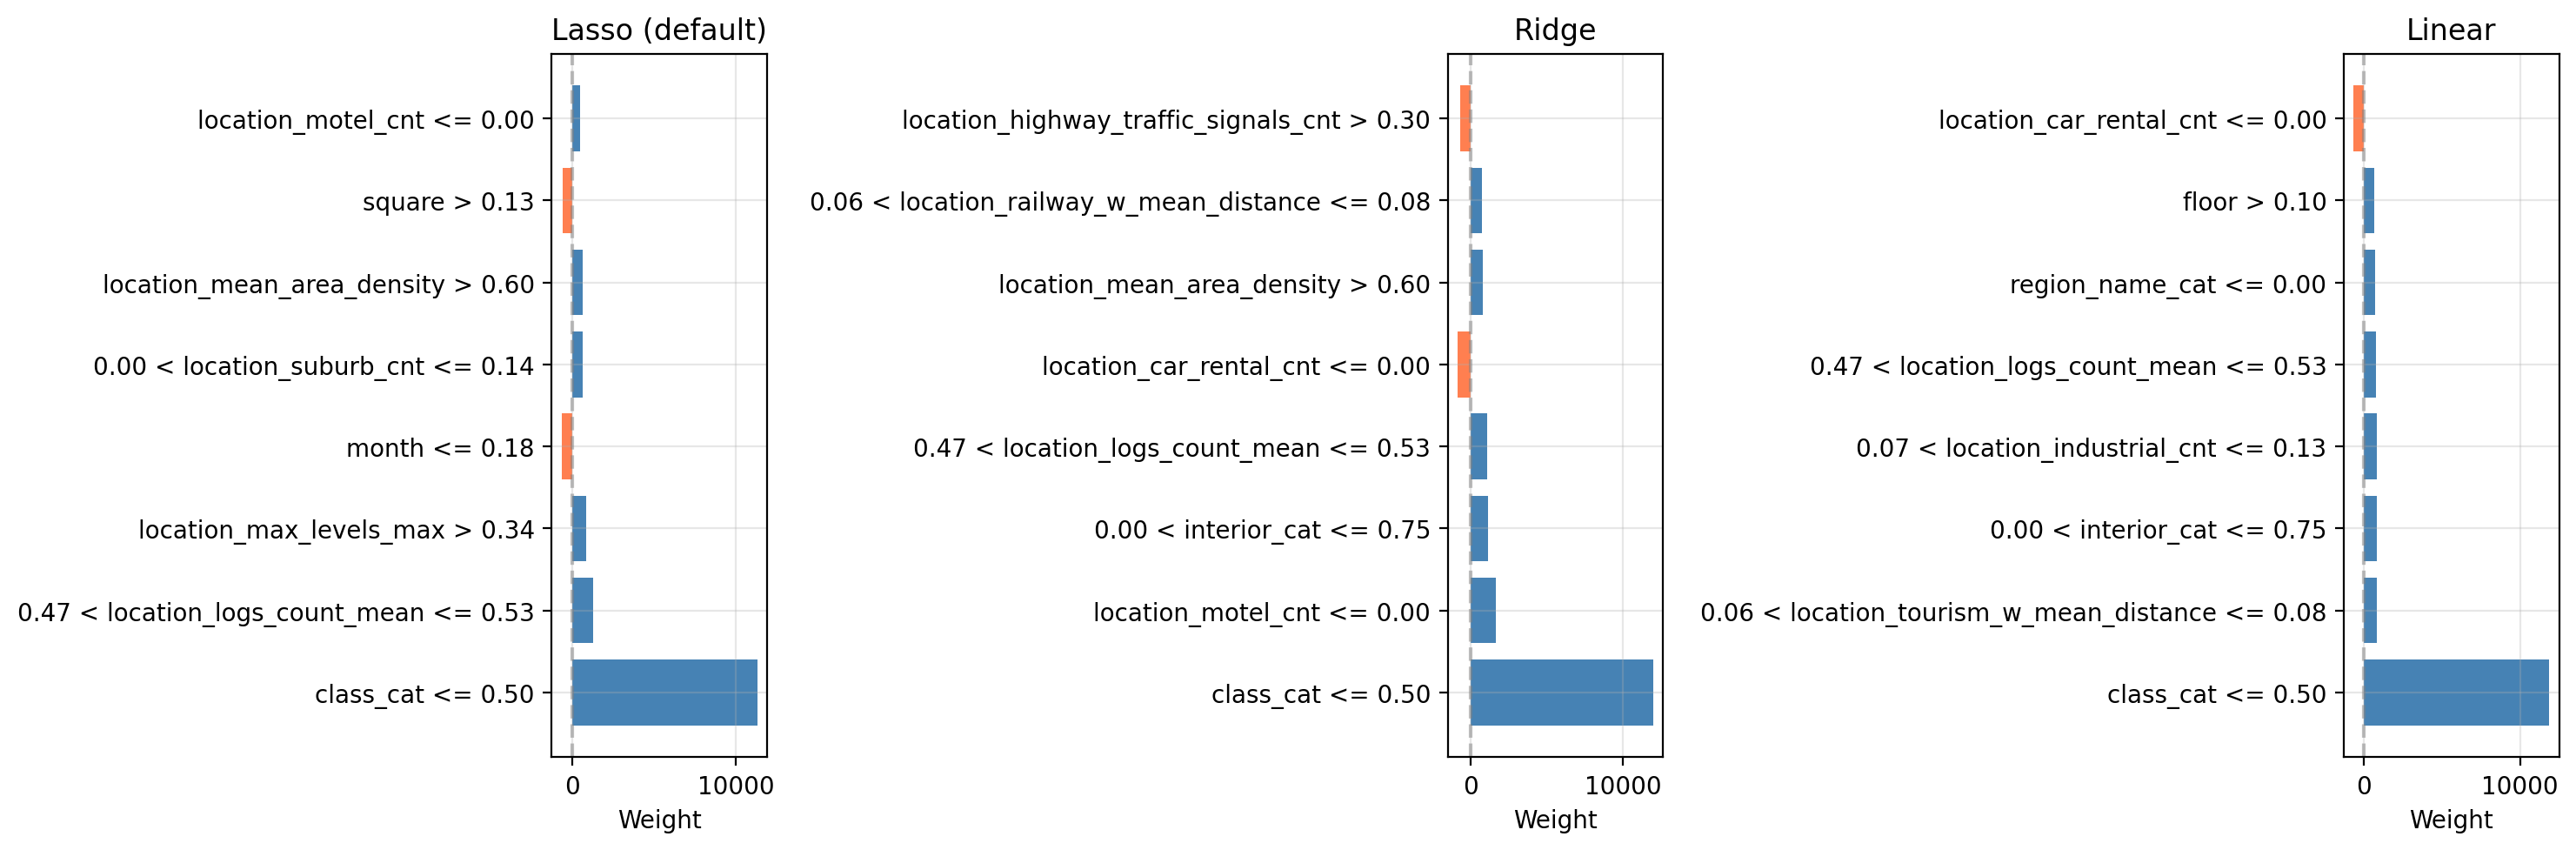

In [50]:
# Анализ влияния выбора регрессора (Lasso vs Ridge vs Linear)
def regressor_analysis(model, X_train, X_test, feature_names, instance_idx):
    from sklearn.linear_model import Lasso, Ridge, LinearRegression
    
    explainer = lime.lime_tabular.LimeTabularExplainer(
        X_train, feature_names=feature_names, mode='regression', verbose=False, random_state=42
    )
    
    regressors = {
        'Lasso (default)': None,
        'Ridge': Ridge(alpha=1.0),
        'Linear': LinearRegression()
    }
    
    results = {}
    
    print("\nСравнение методов выбора признаков:")
    print(f"{'Feature':<35} | {'Lasso':>12} | {'Ridge':>12} | {'Linear':>12}")
    print("-" * 75)
    
    for name, reg in regressors.items():
        exp = explainer.explain_instance(
            X_test[instance_idx], model.predict, 
            num_features=8, num_samples=5000,
            model_regressor=reg
        )
        results[name] = {feat: weight for feat, weight in exp.as_list()}
    
    all_features = set()
    for weights in results.values():
        all_features.update(weights.keys())
    
    for feat in sorted(all_features):
        lasso_w = results['Lasso (default)'].get(feat, 0)
        ridge_w = results['Ridge'].get(feat, 0)
        linear_w = results['Linear'].get(feat, 0)
        if abs(lasso_w) > 0.01 or abs(ridge_w) > 0.01 or abs(linear_w) > 0.01:
            print(f"{feat:<35} | {lasso_w:12.2f} | {ridge_w:12.2f} | {linear_w:12.2f}")
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for i, (name, weights) in enumerate(results.items()):
        if weights:
            features = list(weights.keys())[:8]
            values = [weights[f] for f in features]
            colors = ['steelblue' if v > 0 else 'coral' for v in values]
            axes[i].barh(features, values, color=colors)
            axes[i].axvline(x=0, color='gray', linestyle='--', alpha=0.5)
            axes[i].set_title(name)
            axes[i].set_xlabel('Weight')
            axes[i].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return results

print("Linear Regression - Regressor Comparison")
regressor_lr = regressor_analysis(lr_model, X_train_minmax, X_test_minmax, feature_names, instance_idx)

print("Gradient Boosting - Regressor Comparison")
regressor_gb = regressor_analysis(gb_model, X_train_minmax, X_test_minmax, feature_names, instance_idx)

Linear Regression - Kernel Analysis

Exponential kernel:
    0.03 < location_highway_crossing_w_mean_distance <= 0.04: 9134.53
    class_cat <= 0.50: 6879.21
    location_buildings_cnt > 0.30: 6570.70
    location_highway_traffic_signals_cnt > 0.30: 5626.45
    hc_name_cat > 0.67: 4948.22

Uniform kernel:
    location_motel_cnt <= 0.00: -17370.80
    0.03 < location_highway_crossing_w_mean_distance <= 0.04: 16537.71
    0.06 < location_public_transport_platform_w_mean_distance <= 0.06: -14516.18
    class_cat <= 0.50: 11209.80
    region_name_cat <= 0.00: 10504.04


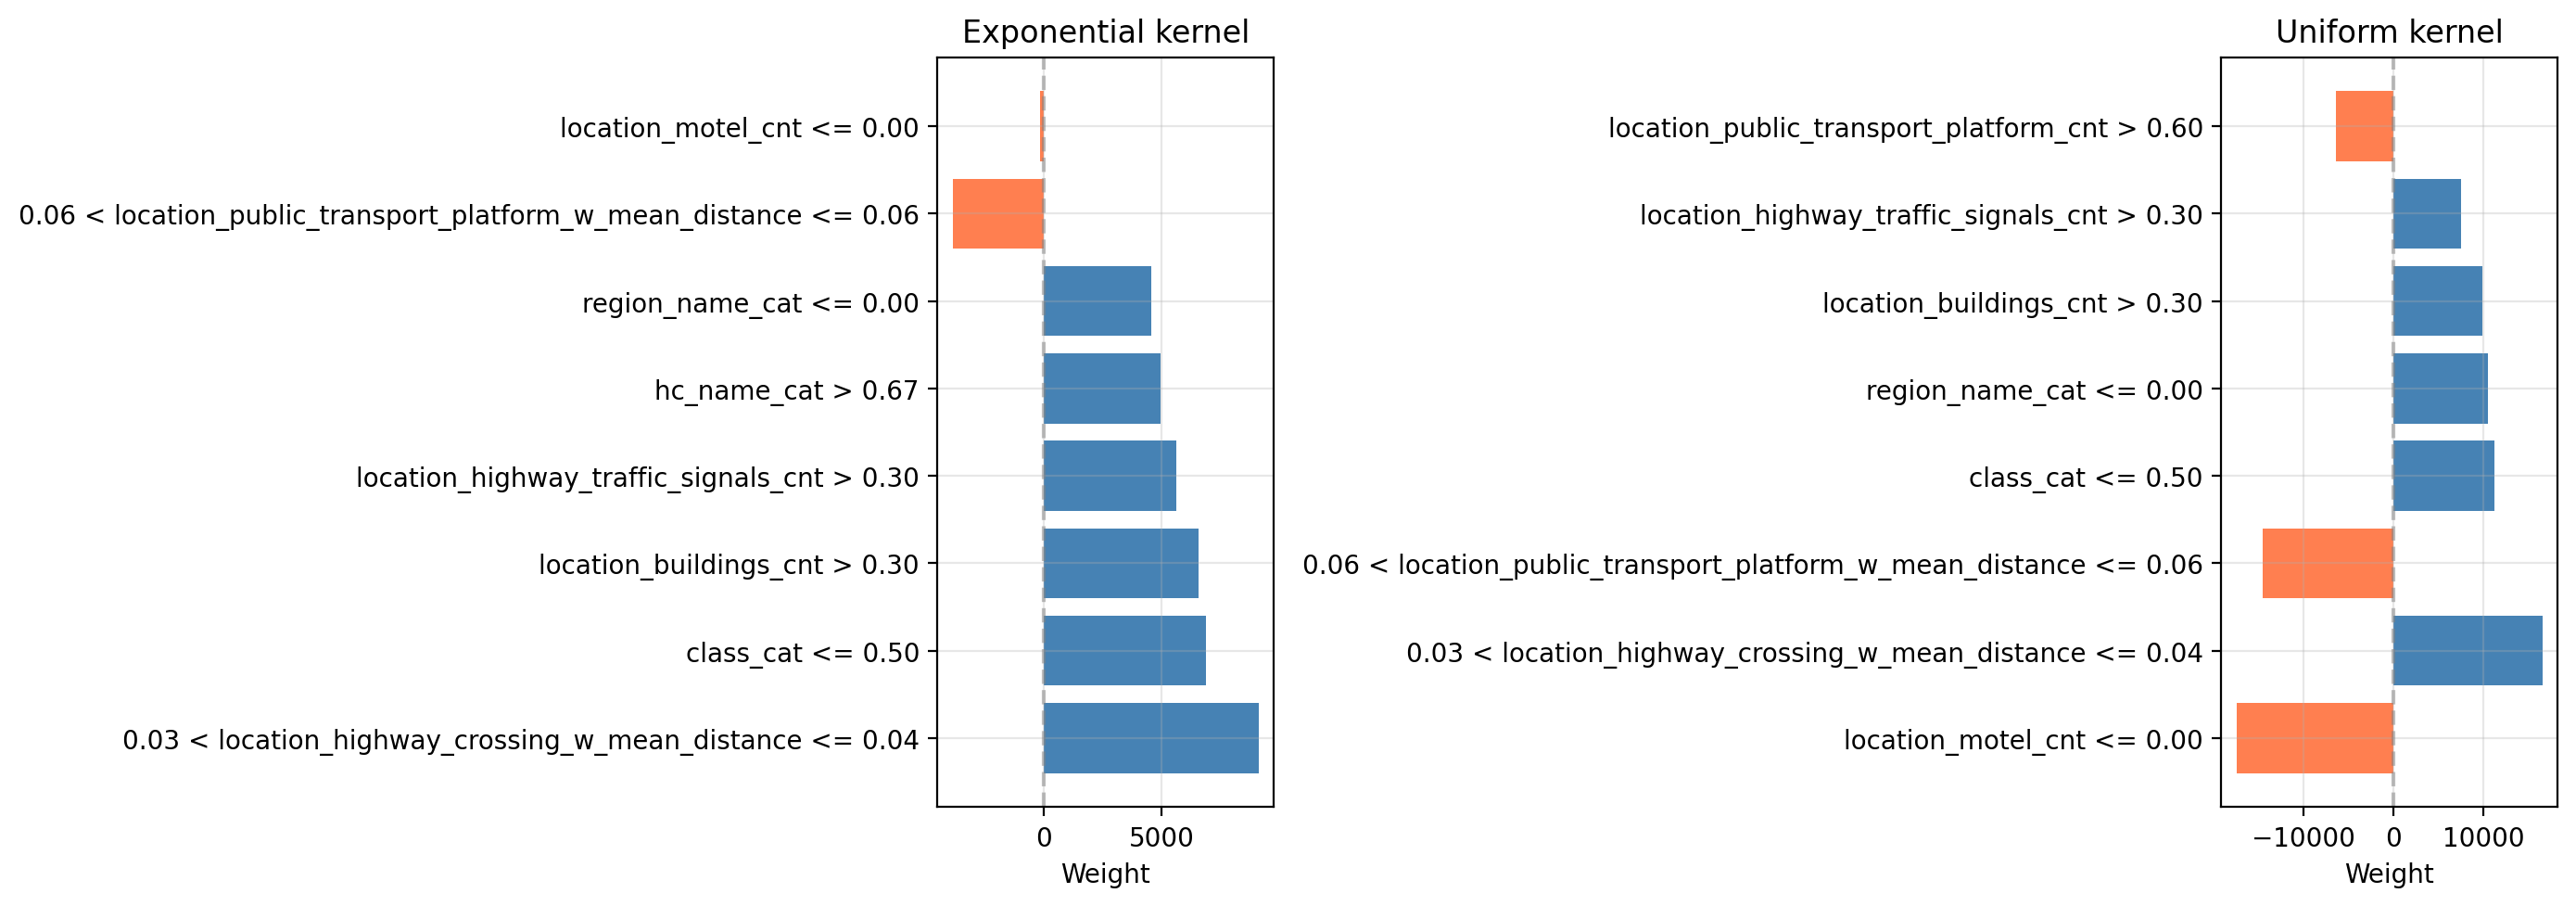


Корреляция между экспоненциальным и равномерным ядром: 0.9275
Gradient Boosting - Kernel Analysis

Exponential kernel:
    class_cat <= 0.50: 8109.58
    0.07 < location_industrial_cnt <= 0.13: 4571.89
    0.47 < location_logs_count_mean <= 0.53: 4179.05
    location_max_levels_max > 0.34: 3999.56
    location_hds_ratio_mean_mean > 0.91: 3775.49

Uniform kernel:
    class_cat <= 0.50: 11280.40
    0.47 < location_logs_count_mean <= 0.53: 1273.84
    location_max_levels_max > 0.34: 806.32
    month <= 0.18: -680.16
    0.00 < location_suburb_cnt <= 0.14: 639.64


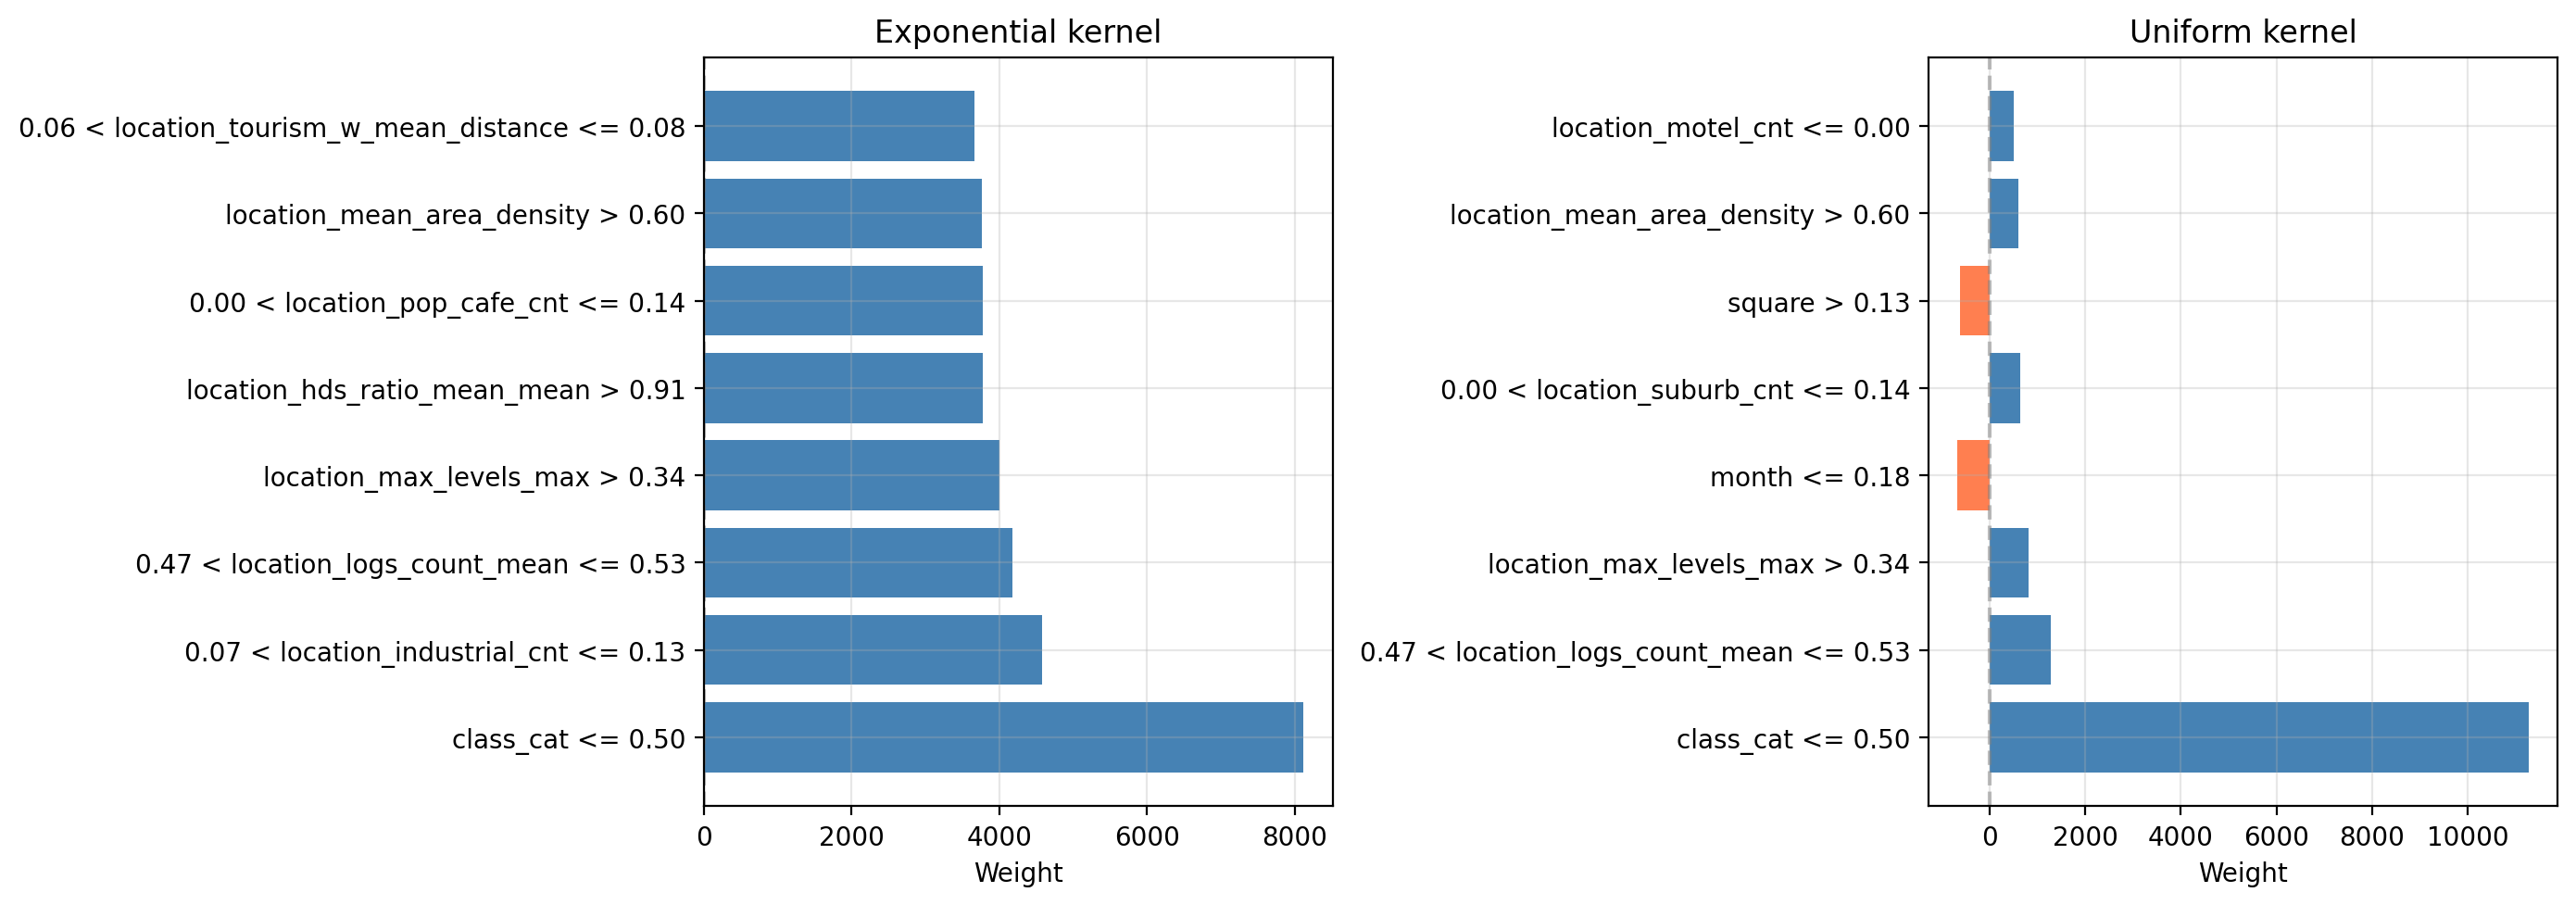


Корреляция между экспоненциальным и равномерным ядром: 0.6834


In [51]:
# Анализ влияния ядра
def kernel_analysis_working(model, X_train, X_test, feature_names, instance_idx):
    import numpy as np
    
    def kernel_exponential(d, **kwargs):
        """Экспоненциальное ядро (по умолчанию в LIME)"""
        return np.exp(-d)
    
    def kernel_uniform(d, **kwargs):
        """Равномерное ядро"""
        return np.ones_like(d)
    
    kernels = {
        'Exponential': kernel_exponential,
        'Uniform': kernel_uniform
    }
    
    results = {}
    
    for kernel_name, kernel_fn in kernels.items():
        explainer = lime.lime_tabular.LimeTabularExplainer(
            X_train,
            feature_names=feature_names,
            mode='regression',
            kernel_width=0.75,
            kernel=kernel_fn,
            verbose=False,
            random_state=42
        )
        
        exp = explainer.explain_instance(
            X_test[instance_idx],
            model.predict,
            num_features=8,
            num_samples=5000
        )
        results[kernel_name] = {feat: weight for feat, weight in exp.as_list()}
        
        print(f"\n{kernel_name} kernel:")
        for feat, weight in exp.as_list()[:5]:
            print(f"    {feat}: {weight:.2f}")
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    for i, (name, weights) in enumerate(results.items()):
        features = list(weights.keys())[:8]
        values = [weights[f] for f in features]
        colors = ['steelblue' if v > 0 else 'coral' for v in values]
        axes[i].barh(features, values, color=colors)
        axes[i].axvline(x=0, color='gray', linestyle='--', alpha=0.5)
        axes[i].set_title(f'{name} kernel')
        axes[i].set_xlabel('Weight')
        axes[i].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Корреляция между ядрами
    w1 = results['Exponential']
    w2 = results['Uniform']
    all_feats = set(w1.keys()) | set(w2.keys())
    v1 = [w1.get(f, 0) for f in all_feats]
    v2 = [w2.get(f, 0) for f in all_feats]
    corr = np.corrcoef(v1, v2)[0, 1]
    print(f"\nКорреляция между экспоненциальным и равномерным ядром: {corr:.4f}")
    
    return results

print("Linear Regression - Kernel Analysis")
kernel_lr_working = kernel_analysis_working(lr_model, X_train_minmax, X_test_minmax, feature_names, instance_idx)

print("Gradient Boosting - Kernel Analysis")
kernel_gb_working = kernel_analysis_working(gb_model, X_train_minmax, X_test_minmax, feature_names, instance_idx)

## Задание 7. 1 балл. SHAP
Постройте локальный график с SHAP для объекта с индексом, равным вашему номеру в таблице курса на обеих моделях и сделайте выводы. 
## Задание 7.1 (*). 1 балл.  Shap и категориальные переменные.
Shap разлагает предсказание модели вблизи точки x на базовый уровень и сумму вкладов признаков: $ f(x) = base + \sum_i{\phi_i(x)}$. В случае one-hot вклад признака - это сумма вкладов dummy столбцов. Сравните вклады категориальных признаков до и после кодировки - так ли это? 


  0%|          | 0/1 [00:00<?, ?it/s]

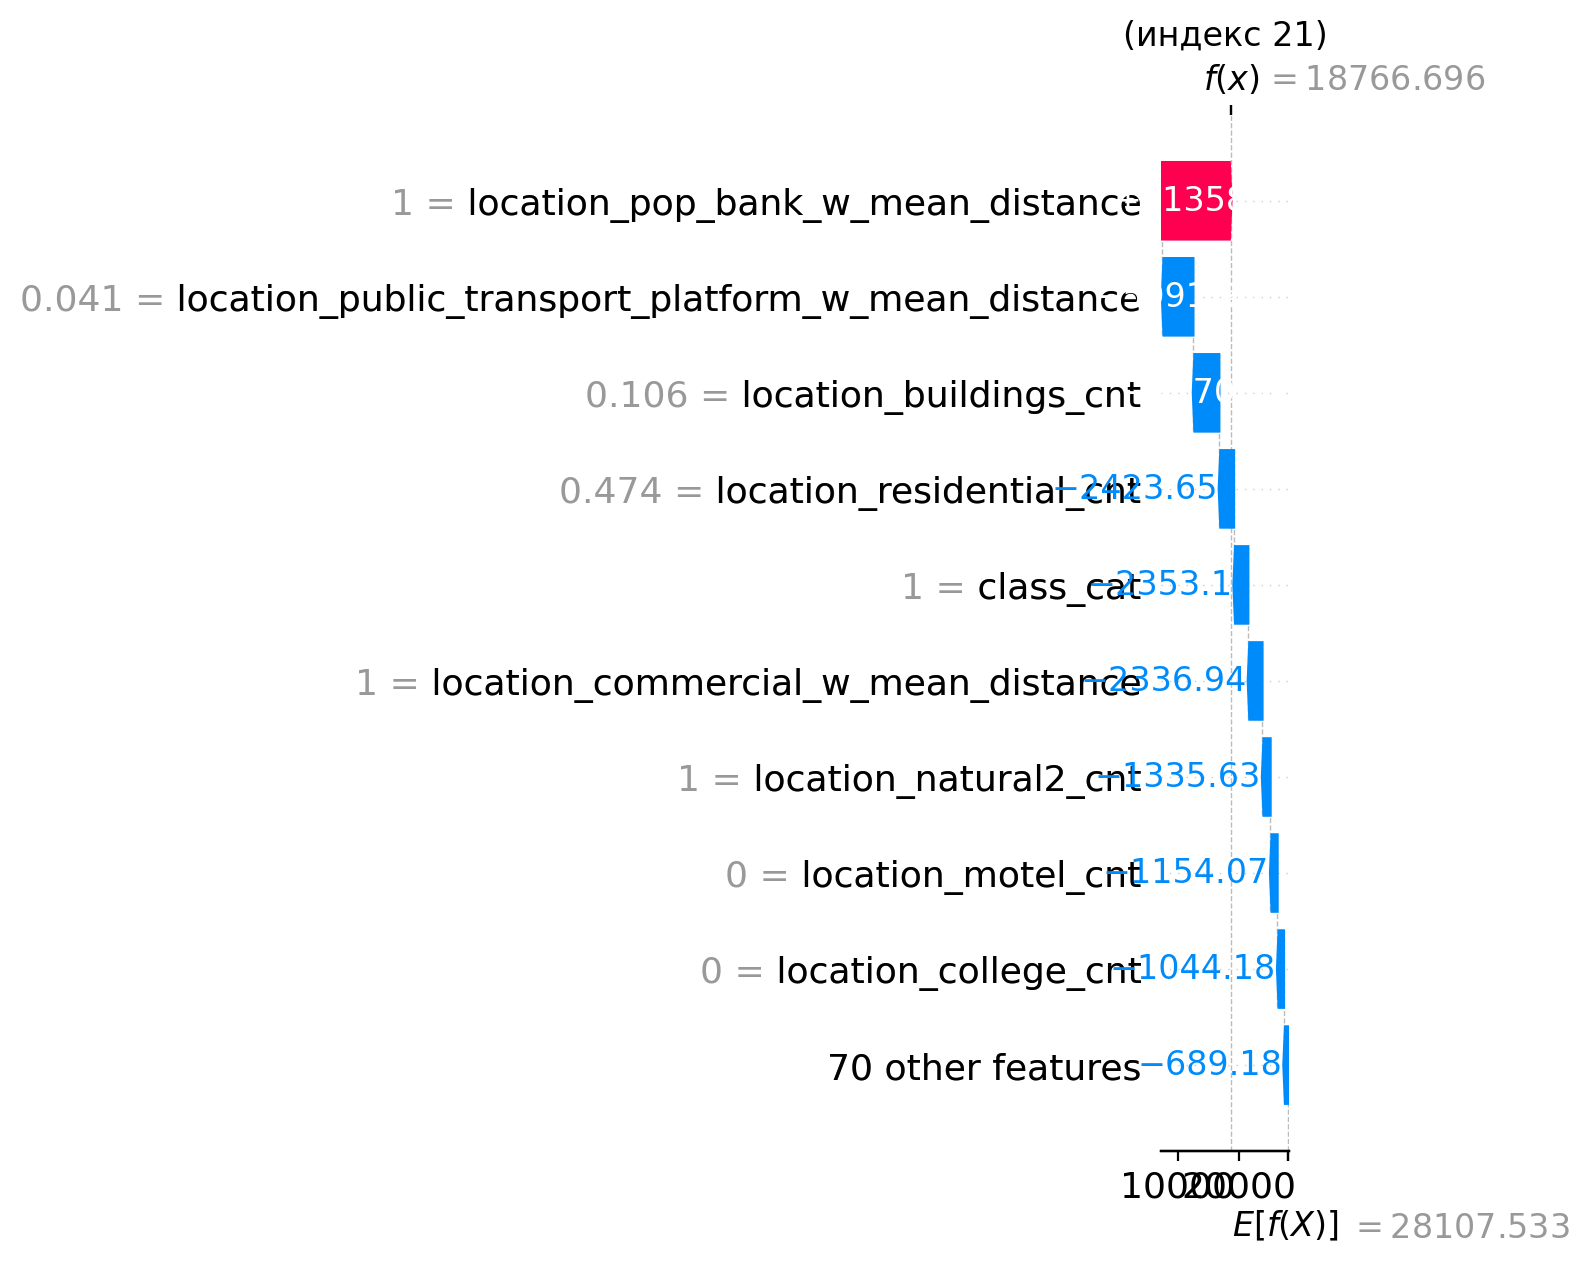

Предсказание LR: 18766.70
Базовое значение: 28107.53
Сумма SHAP: -9340.84


In [52]:
import shap
idx = 21
instance = X_test_minmax[idx:idx+1]

# SHAP для линейной регрессии
explainer_lr = shap.KernelExplainer(lr_model.predict, X_train_minmax[:100])
shap_values_lr = explainer_lr.shap_values(instance, nsamples=1000)

# Водопад-диаграмма
plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap.Explanation(
    values=shap_values_lr[0],
    base_values=explainer_lr.expected_value,
    data=instance[0],
    feature_names=feature_names
), max_display=10, show=False)
plt.title(f'(индекс {idx})')
plt.tight_layout()
plt.show()

print(f"Предсказание LR: {lr_model.predict(instance)[0]:.2f}")
print(f"Базовое значение: {explainer_lr.expected_value:.2f}")
print(f"Сумма SHAP: {shap_values_lr[0].sum():.2f}")

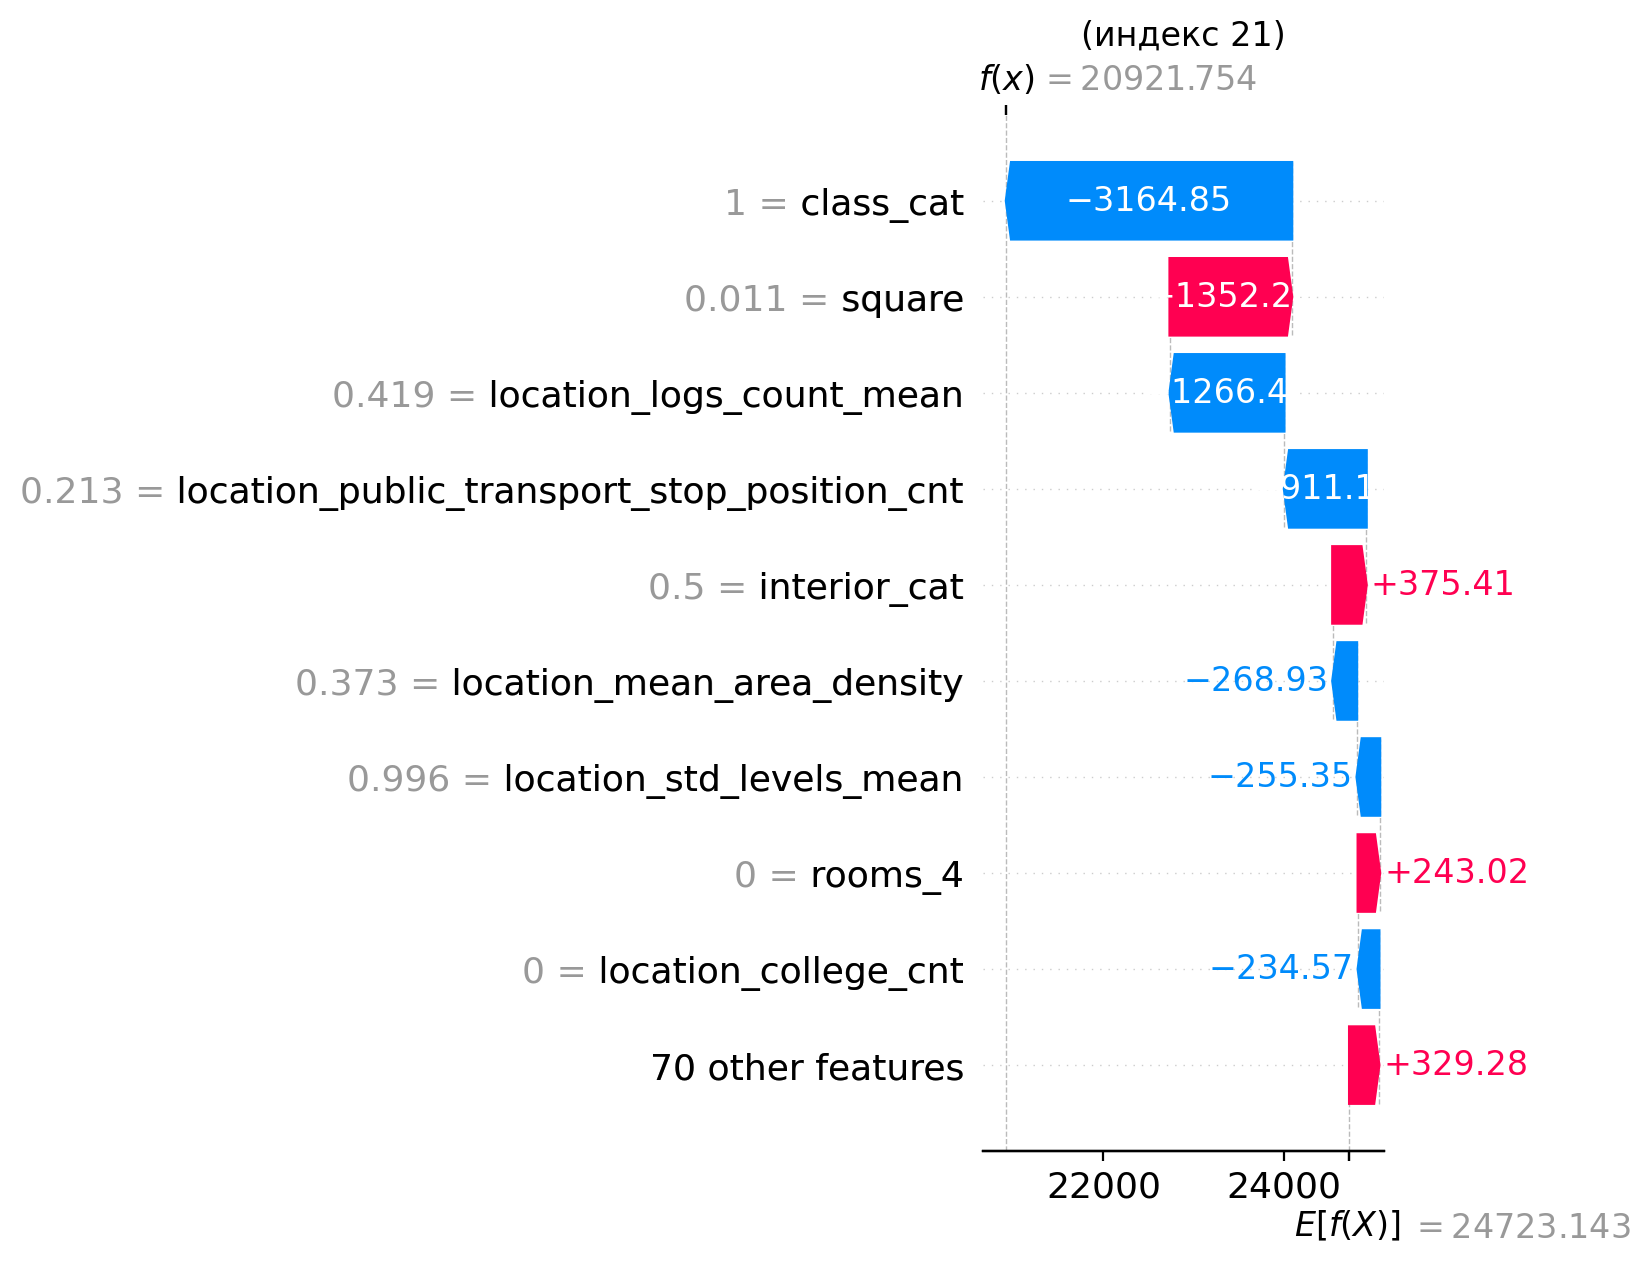

Предсказание GB: 20921.75
Базовое значение: 24723.14
Сумма SHAP: -3801.39


In [53]:
# SHAP для градиентного бустинга
explainer_gb = shap.TreeExplainer(gb_model)
shap_values_gb = explainer_gb.shap_values(instance)

base_gb = explainer_gb.expected_value
if hasattr(base_gb, '__len__'):
    base_gb = base_gb[0]

plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap.Explanation(
    values=shap_values_gb[0],
    base_values=base_gb,
    data=instance[0],
    feature_names=feature_names
), max_display=10, show=False)
plt.title(f'(индекс {idx})')
plt.tight_layout()
plt.show()

print(f"Предсказание GB: {gb_model.predict(instance)[0]:.2f}")
print(f"Базовое значение: {base_gb:.2f}")
print(f"Сумма SHAP: {shap_values_gb[0].sum():.2f}")

In [54]:
print("Сравнение вкладов категориальных признаков")

# категориальные признаки
cat_features = ['class_cat', 'region_name_cat', 'stage_cat', 'interior_cat', 'rooms_4']
cat_indices = [feature_names.index(f) for f in cat_features if f in feature_names]


print("\nЛинейная регрессия - вклады категориальных признаков:")
for feat in cat_features:
    if feat in feature_names:
        idx_feat = feature_names.index(feat)
        shap_val = shap_values_lr[0][idx_feat]
        print(f"  {feat}: {shap_val:.2f}")

print("SHAP вклады для dummy-столбцов (на примере class_cat)")

class_cat_values = np.unique(X_train_processed[:, feature_names.index('class_cat')])
print(f"Уникальные значения class_cat: {class_cat_values}")

class_val = X_test_processed[idx, feature_names.index('class_cat')]
print(f"Значение class_cat для экземпляра {idx}: {class_val}")

print(f"Общий SHAP вклад class_cat: {shap_values_lr[0][feature_names.index('class_cat')]:.2f}")

Сравнение вкладов категориальных признаков

Линейная регрессия - вклады категориальных признаков:
  class_cat: -2353.10
  region_name_cat: 0.00
  stage_cat: 0.00
  interior_cat: 0.00
  rooms_4: 0.00
SHAP вклады для dummy-столбцов (на примере class_cat)
Уникальные значения class_cat: [0. 1. 2.]
Значение class_cat для экземпляра 21: 2.0
Общий SHAP вклад class_cat: -2353.10


In [55]:
print("Проверка f(x) = base + sum(phi_i) для категориальных")

# Для линейной регрессии
lr_pred = lr_model.predict(instance)[0]
lr_base = explainer_lr.expected_value
lr_sum_all = lr_base + shap_values_lr[0].sum()

print(f"\nЛинейная:")
print(f"  base: {lr_base:.2f}")
print(f"  sum(phi_i): {shap_values_lr[0].sum():.2f}")
print(f"  base + sum = {lr_sum_all:.2f}")
print(f"  model.predict = {lr_pred:.2f}")
print(f"  Разница: {lr_pred - lr_sum_all:.6f}")

# Для градиентного бустинга
gb_pred = gb_model.predict(instance)[0]
gb_sum_all = base_gb + shap_values_gb[0].sum()

print(f"\nГрадиентный бустинг:")
print(f"  base: {base_gb:.2f}")
print(f"  sum(phi_i): {shap_values_gb[0].sum():.2f}")
print(f"  base + sum = {gb_sum_all:.2f}")
print(f"  model.predict = {gb_pred:.2f}")
print(f"  Разница: {gb_pred - gb_sum_all:.6f}")

Проверка f(x) = base + sum(phi_i) для категориальных

Линейная:
  base: 28107.53
  sum(phi_i): -9340.84
  base + sum = 18766.70
  model.predict = 18766.70
  Разница: 0.000000

Градиентный бустинг:
  base: 24723.14
  sum(phi_i): -3801.39
  base + sum = 20921.75
  model.predict = 20921.75
  Разница: -0.000000
